In [1]:
import pandas as pd
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings

# 设置GPU加速（如果有）
#physical_devices = tf.config.list_physical_devices('GPU')
#if len(physical_devices) > 0:
#    tf.config.experimental.set_memory_growth(physical_devices[0], True)
 #   print("使用GPU加速")
# 读取数据
os.chdir("E:/烟花污染/我用的")
df = pd.read_csv("全部年份_标准地级市.csv", encoding="utf-8")

#dta["time_datetime"] = pd.to_datetime(dta["time_datetime"]) #time_datetime


C:\Users\feixi\AppData\Local\Temp\ipykernel_19340\2165898989.py:18: DtypeWarning: Columns (28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("全部年份_标准地级市.csv", encoding="utf-8")


In [9]:
import geopandas as gpd

# 读取你的SHP
shp_path = r"E:/烟花污染/我用的/shp格式/中国_市.shp"
city_shp = gpd.read_file(shp_path, encoding='utf-8')

# 显示所有列名（你只需要看这个！）
print("你的SHP文件所有列名：")
print(list(city_shp.columns))

# 预览前5行
print("\n前5行数据：")
print(city_shp.head())

你的SHP文件所有列名：
['name', 'gb', 'geometry']

前5行数据：
  name         gb                                           geometry
0  梅州市  156441400  POLYGON ((115.88406 24.92896, 115.89031 24.927...
1  鄂州市  156420700  POLYGON ((114.83199 30.5678, 114.82968 30.4732...
2  吕梁市  156141100  POLYGON ((111.20539 38.72164, 111.20739 38.712...
3  舟山市  156330900  MULTIPOLYGON (((122.25205 29.69094, 122.23384 ...
4  朝阳市  156211300  POLYGON ((119.6002 42.27468, 119.60812 42.2503...


In [3]:
import pandas as pd
import os

base_path = "E:/烟花污染/FINAL"

# 文件列表
file_list = [
    'city_hour_panel_2019_2020.csv',
    'city_hour_panel_2020_2021.csv',
    'city_hour_panel_2021_2022.csv',
    'city_hour_panel_2022_2023.csv',
    'city_hour_panel_2023_2024.csv',
    'city_hour_panel_2024_2025.csv'
]

# 读取所有文件并合并
df_list = []
for file in file_list:
    file_path = os.path.join(base_path, file)
    df_temp = pd.read_csv(file_path)
    df_list.append(df_temp)
    print(f"已读取 {file}, 行数: {len(df_temp)}")

# 按行合并（默认按列名对齐）
df_combined = pd.concat(df_list, ignore_index=True)

print(f"\n合并完成！总行数: {len(df_combined)}")
print(f"列名: {list(df_combined.columns)}")

# 可选：保存合并后的文件
#output_path = os.path.join(base_path, "city_hour_panel_combined.csv")
#df_combined.to_csv(output_path, index=False)
#print(f"已保存至: {output_path}")

已读取 city_hour_panel_2019_2020.csv, 行数: 1285856
已读取 city_hour_panel_2020_2021.csv, 行数: 1202699
已读取 city_hour_panel_2021_2022.csv, 行数: 1210926
已读取 city_hour_panel_2022_2023.csv, 行数: 1197108
已读取 city_hour_panel_2023_2024.csv, 行数: 1216422
已读取 city_hour_panel_2024_2025.csv, 行数: 1204641

合并完成！总行数: 7317652
列名: ['NAME', 'time', 'PM2.5', 'temp_c', 'dewpoint_c', 'rh', 'wind_speed', 'wind_direction', 'surface_pressure', 'tp']


In [5]:
combined_df = df_combined

In [ ]:
# ========== 统计NAME列的城市数量 ==========
# 1. 基础统计：不重复城市总数
if 'combined_df' in locals():  # 检查合并后的数据集是否存在
    # 先清理可能的空值和空格
    combined_df['NAME'] = combined_df['NAME'].astype(str).str.strip()  # 转为字符串并去除首尾空格
    unique_cities = combined_df['NAME'].dropna().unique()  # 去除空值后获取唯一值
    city_count = len(unique_cities)
    
    print(f"{'='*60}")
    print(f"📊 NAME列城市统计结果")
    print(f"{'='*60}")
    print(f"总不重复城市数量: {city_count} 个")
    
    # 2. 按年份分段统计各年份的城市数量
    print("\n📈 各年份区间的城市数量:")
    for year_range in sorted(combined_df['year_range'].unique()):
        year_cities = combined_df[combined_df['year_range'] == year_range]['NAME'].dropna().unique()
        print(f"  {year_range}: {len(year_cities)} 个城市")
    
    # 3. 列出所有不重复的城市名称（可选，如需查看具体城市）
    print("\n📍 所有不重复城市列表:")
    # 按字母/拼音排序显示
    for idx, city in enumerate(sorted(unique_cities), 1):
        print(f"  {idx:2d}. {city}")
        
    # 4. 检查是否有异常值（如"nan"、空字符串等）
    abnormal_values = [val for val in unique_cities if val in ['nan', '', 'None']]
    if abnormal_values:
        print(f"\n⚠️  发现异常值: {abnormal_values}，已在统计中排除")
else:
    print("❌ 未找到合并后的数据集（combined_df），请先运行读取数据的代码")

In [11]:
import pandas as pd
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# ====================== 1. 读取375个市的SHP ======================
shp_path = r"E:/烟花污染/我用的/shp格式/中国_市.shp"
city_shp = gpd.read_file(shp_path, encoding='utf-8')

# 查看SHP文件中的列名，找到城市名称字段
print("SHP文件中的列名:")
print(city_shp.columns.tolist())
print("\nSHP文件前5行:")
print(city_shp.head())
print("="*60)

# 尝试找到城市名称字段（可能的列名）
possible_city_cols = ['name', 'NAME', 'city', 'City', '市名', '城市名称', 'NAME_1', 'NAME_2']
city_name_col = None

for col in possible_city_cols:
    if col in city_shp.columns:
        city_name_col = col
        break

if city_name_col is None:
    print(f"❌ 错误：在SHP文件中找不到城市名称列！")
    print(f"尝试查找的列名: {possible_city_cols}")
    print(f"SHP文件中的列名: {city_shp.columns.tolist()}")
    raise ValueError("找不到城市名称列")

print(f"✅ 找到SHP中的城市名称列: {city_name_col}")

# ====================== 2. 读取你的数据（已包含城市名称）======================
df = combined_df.copy()

# 查看你的数据中的城市名称列
print(f"\n你的数据中的城市名称列: 'NAME'")
print(f"你的数据中唯一城市数量: {df['NAME'].nunique()}")
print(f"前10个城市名:")
print(df['NAME'].value_counts().head(10))
print("="*60)

# ====================== 3. 基于城市名称匹配 ======================
print("\n正在进行城市名称匹配...")

# 获取SHP中的标准城市名称列表
standard_cities = city_shp[city_name_col].unique()
print(f"SHP中的标准城市数量: {len(standard_cities)}")

# 检查匹配情况
df_cities = df['NAME'].unique()
matched_cities = set()
unmatched_cities = set()

for city in df_cities:
    if city in standard_cities:
        matched_cities.add(city)
    else:
        unmatched_cities.add(city)

print(f"\n匹配结果:")
print(f"✅ 匹配成功的城市: {len(matched_cities)} 个")
print(f"❌ 未匹配的城市: {len(unmatched_cities)} 个")

if len(unmatched_cities) > 0:
    print(f"\n未匹配的城市名（前20个）:")
    for city in list(unmatched_cities)[:20]:
        print(f"  - {city}")

# ====================== 4. 处理未匹配的城市 ======================
# 创建城市名称映射表（如果需要手动映射）
print("\n" + "="*60)
print("处理城市名称匹配...")

# 方法1: 直接使用原始城市名（如果你的城市名与SHP中的一致）
# 如果你的城市名已经与SHP中的一致，可以直接使用
if len(matched_cities) > 0:
    print(f"✅ {len(matched_cities)} 个城市可以直接匹配")
    
    # 过滤数据：只保留能匹配上的城市
    df_filtered = df[df['NAME'].isin(standard_cities)].copy()
    print(f"过滤后数据量: {len(df_filtered):,} 行")
    
    # 可选：如果你想保留所有数据，但未匹配的设为空
    # df_filtered = df.copy()
    # df_filtered['matched_city'] = df_filtered['NAME'].apply(lambda x: x if x in standard_cities else None)
else:
    print("⚠️ 没有城市能直接匹配，需要手动创建映射关系")
    df_filtered = df.copy()

# ====================== 5. 输出结果 ======================
if len(df_filtered) > 0:
    total_cities = df_filtered['NAME'].nunique()
    print("\n" + "="*60)
    print(f"✅ 全部完成！")
    print(f"✅ 成功匹配到：{total_cities} / {len(standard_cities)} 个市")
    print(f"✅ 总数据量：{len(df_filtered):,} 行")
    print("="*60)
    
    # 保存最终文件
    output_path = "E:/烟花污染/我用的/全部年份_375市_城市名匹配完成.csv"
    df_filtered.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✅ 文件已保存：{output_path}")
    
    # 如果需要，也可以创建空间数据
    # 将城市名称与SHP几何信息关联
    city_geo = city_shp[[city_name_col, 'geometry']].copy()
    city_geo = city_geo.rename(columns={city_name_col: 'NAME'})
    
    # 如果你的数据中包含时间信息，可以按城市聚合
    print("\n生成城市级汇总统计...")
    city_summary = df_filtered.groupby('NAME').agg({
        'PM2.5': ['mean', 'std', 'count'],
        'temp_c': 'mean',
        'rh': 'mean',
        'wind_speed': 'mean'
    }).round(2)
    
    city_summary.columns = ['PM2.5_mean', 'PM2.5_std', 'PM2.5_count', 
                            'temp_mean', 'rh_mean', 'wind_speed_mean']
    city_summary = city_summary.reset_index()
    
    # 合并空间信息
    city_summary_geo = city_geo.merge(city_summary, on='NAME', how='inner')
    print(f"城市级汇总数据量: {len(city_summary_geo)} 个城市")
    
    
    
    # 同时保存汇总CSV
    #city_summary.to_csv("E:/烟花污染/我用的/城市PM2.5汇总.csv", index=False, encoding='utf-8-sig')
    #print(f"✅ 城市汇总CSV已保存")
    
else:
    print("❌ 没有匹配到任何数据！")

# ====================== 6. 可选：创建城市名称映射字典 ======================
# 如果城市名称不完全匹配，可以在这里手动创建映射关系
print("\n" + "="*60)
print("如果需要手动映射城市名称，可以参考以下格式:")
print("""
# 创建映射字典
city_mapping = {
    '原始城市名1': '标准城市名1',
    '原始城市名2': '标准城市名2',
    # 添加更多映射...
}

# 应用映射
df['NAME_standard'] = df['NAME'].map(city_mapping).fillna(df['NAME'])
""")

# 显示SHP中的标准城市名示例
print(f"\nSHP中的标准城市名示例（前20个）:")
for city in standard_cities[:20]:
    print(f"  - {city}")

SHP文件中的列名:
['name', 'gb', 'geometry']

SHP文件前5行:
  name         gb                                           geometry
0  梅州市  156441400  POLYGON ((115.88406 24.92896, 115.89031 24.927...
1  鄂州市  156420700  POLYGON ((114.83199 30.5678, 114.82968 30.4732...
2  吕梁市  156141100  POLYGON ((111.20539 38.72164, 111.20739 38.712...
3  舟山市  156330900  MULTIPOLYGON (((122.25205 29.69094, 122.23384 ...
4  朝阳市  156211300  POLYGON ((119.6002 42.27468, 119.60812 42.2503...
✅ 找到SHP中的城市名称列: name

你的数据中的城市名称列: 'NAME'
你的数据中唯一城市数量: 367
前10个城市名:
NAME
金华市    21830
威海市    21830
苏州市    21830
青岛市    21829
济南市    21829
南京市    21829
银川市    21828
汕头市    21828
咸阳市    21828
绍兴市    21828
Name: count, dtype: int64

正在进行城市名称匹配...
SHP中的标准城市数量: 375

匹配结果:
✅ 匹配成功的城市: 338 个
❌ 未匹配的城市: 29 个

未匹配的城市名（前20个）:
  - 市辖区(石嘴山市)
  - 揭阳县
  - 阿坝州
  - 甘孜州
  - 黄南州
  - 遂宁县
  - 喀什市
  - 凉山州
  - 海西州
  - 和田市
  - 市辖区(南通市)
  - 临沧县
  - 固原县
  - 阿勒泰市
  - 玉树州
  - 恩施州
  - 巴中县
  - 丽江纳西族自治县
  - 南充县
  - 塔城市

处理城市名称匹配...
✅ 338 个城市可以直接匹配
过滤后数据量: 7,257,1

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# -------------------------- 异常值处理函数 --------------------------
def detect_and_remove_outliers(df, target_col='PM2.5', feature_columns=None,
                              target_threshold=3, feature_threshold=3):
    """
    检测并移除异常值
    """
    df_clean = df.copy()
    original_count = len(df_clean)

    print("开始异常值处理...")

    # 1. 处理目标变量PM2.5的异常值
    if target_col in df_clean.columns:
        # 使用IQR方法检测PM2.5异常值
        Q1 = df_clean[target_col].quantile(0.25)
        Q3 = df_clean[target_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - target_threshold * IQR
        upper_bound = Q3 + target_threshold * IQR

        # 记录异常值信息
        pm25_outliers = df_clean[(df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)]
        print(f"PM2.5异常值: {len(pm25_outliers)} 条 ({len(pm25_outliers)/len(df_clean)*100:.2f}%)")
        print(f"PM2.5范围: [{df_clean[target_col].min():.2f}, {df_clean[target_col].max():.2f}]")
        print(f"PM2.5异常值界限: [{lower_bound:.2f}, {upper_bound:.2f}]")

        # 移除PM2.5异常值
        df_clean = df_clean[(df_clean[target_col] >= lower_bound) & (df_clean[target_col] <= upper_bound)]

    # 2. 处理特征变量的异常值
    if feature_columns:
        feature_outliers_count = 0
        for feature in feature_columns:
            if feature in df_clean.columns and df_clean[feature].dtype in ['float64', 'int64']:
                # 使用Z-score方法
                z_scores = np.abs((df_clean[feature] - df_clean[feature].mean()) / df_clean[feature].std())
                extreme_outliers = z_scores > feature_threshold
                feature_outliers_count += extreme_outliers.sum()

                # 对极端异常值进行缩尾处理而不是直接删除
                if extreme_outliers.sum() > 0:
                    lower_percentile = df_clean[feature].quantile(0.01)
                    upper_percentile = df_clean[feature].quantile(0.99)
                    df_clean[feature] = df_clean[feature].clip(lower=lower_percentile, upper=upper_percentile)

        print(f"特征异常值处理: {feature_outliers_count} 个极端值进行缩尾处理")

    # 3. 处理物理上不可能的数值
    # PM2.5不能为负
    if 'PM2.5' in df_clean.columns:
        negative_pm25 = (df_clean['PM2.5'] < 0).sum()
        if negative_pm25 > 0:
            print(f"修正 {negative_pm25} 个负PM2.5值为0")
            df_clean['PM2.5'] = df_clean['PM2.5'].clip(lower=0)

    # 相对湿度应该在0-100之间
    if 'rh' in df_clean.columns:
        invalid_rh = ((df_clean['rh'] < 0) | (df_clean['rh'] > 100)).sum()
        if invalid_rh > 0:
            print(f"修正 {invalid_rh} 个无效相对湿度值")
            df_clean['rh'] = df_clean['rh'].clip(lower=0, upper=100)

    removed_count = original_count - len(df_clean)
    print(f"异常值处理完成: 移除 {removed_count} 条记录, 保留 {len(df_clean)} 条记录")
    print(f"数据保留率: {len(df_clean)/original_count*100:.2f}%")

    return df_clean

# -------------------------- 简化版本的特征工程 --------------------------
# 🔧 修改：将 time_datetime 改为 time
if 'time' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['time']):
    df['time'] = pd.to_datetime(df['time'])

# 基本特征填充 - 使用推荐的方法
print("开始基础数据填充...")
numeric_features = ["wind_direction", "temp_c", "surface_pressure", "wind_speed", "rh", "tp", "PM2.5"]
df[numeric_features] = df.groupby("NAME")[numeric_features].transform(
    lambda group: group.ffill().bfill().fillna(group.mean())
)

# -------------------------- 特征工程 --------------------------
def enhance_features_simple(df):
    """简化版特征工程 - 无需标准化"""
    df = df.copy()

    # 🔧 修改：确保time字段是datetime类型（改为time）
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # 基础时间特征
    df['month'] = df['time'].dt.month
    df['day_of_week'] = df['time'].dt.dayofweek
    df['hour'] = df['time'].dt.hour
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # 气象条件组合特征
    df['surface_pressure_safe'] = df['surface_pressure'].clip(lower=900, upper=1100)
    df['temp_pressure_ratio'] = df['temp_c'] / df['surface_pressure_safe']
    df['wind_effect'] = df['wind_speed'] * (df['rh'].clip(1, 100) / 100)

    # 时间周期特征
    df['day_of_year'] = df['time'].dt.dayofyear
    df['sin_day'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['cos_day'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # 季节特征
    season_map = {12: 0, 1: 0, 2: 0,   # 冬季
                  3: 1, 4: 1, 5: 1,   # 春季
                  6: 2, 7: 2, 8: 2,   # 夏季
                  9: 3, 10: 3, 11: 3} # 秋季
    df['season'] = df['month'].map(season_map)

    # 气象条件分类
    try:
        df['wind_category'] = pd.qcut(df['wind_speed'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
    except:
        df['wind_category'] = 0

    try:
        df['temp_category'] = pd.qcut(df['temp_c'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
    except:
        df['temp_category'] = 0

    try:
        df['rh_category'] = pd.qcut(df['rh'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
    except:
        df['rh_category'] = 0

    # 滞后特征
    df['PM2.5_lag_24'] = df.groupby('NAME')['PM2.5'].shift(24)

    # 滚动统计特征
    df['PM2.5_rolling_mean_24'] = df.groupby('NAME')['PM2.5'].transform(
        lambda x: x.rolling(24, min_periods=1).mean()
    )
    df['PM2.5_rolling_std_24'] = df.groupby('NAME')['PM2.5'].transform(
        lambda x: x.rolling(24, min_periods=1).std()
    )

    # 填充滚动特征的缺失值
    rolling_features = ['PM2.5_rolling_mean_24', 'PM2.5_rolling_std_24']
    df[rolling_features] = df.groupby('NAME')[rolling_features].transform(
        lambda x: x.ffill().bfill().fillna(x.mean())
    )

    # 填充滞后特征的缺失值
    df['PM2.5_lag_24'] = df.groupby('NAME')['PM2.5_lag_24'].transform(
        lambda x: x.ffill().bfill().fillna(x.mean())
    )

    return df

# 应用特征增强
print("开始特征工程...")
df = enhance_features_simple(df)

# 定义特征列
base_features = ["wind_direction", "temp_c", "surface_pressure", "wind_speed", "rh", "tp"]
time_features = ["month", "day_of_week", "hour"]
engineered_features = ["temp_pressure_ratio", "wind_effect", "sin_day", "cos_day"]
#category_features = ["wind_category", "temp_category", "rh_category"]
lag_features = ["PM2.5_lag_24", "PM2.5_rolling_mean_24"]

feature_columns = base_features + time_features + lag_features

print(f"特征工程完成，总特征数: {len(feature_columns)}")
print(f"特征列表: {feature_columns}")

# -------------------------- 异常值处理 --------------------------
print("\n" + "="*50)
print("异常值处理阶段")
print("="*50)

# 在数据划分前进行异常值处理
df_clean = detect_and_remove_outliers(df, target_col='PM2.5',
                                    feature_columns=feature_columns,
                                    target_threshold=3, feature_threshold=3)

# -------------------------- 数据划分 --------------------------
print("\n开始数据划分...")

# 🔧 修改：按时间排序，使用time列
df_clean = df_clean.sort_values(['NAME', 'time']).reset_index(drop=True)

# 按时间划分，确保时间连续性
split_date = df_clean['time'].quantile(0.8)
train_df = df_clean[df_clean['time'] <= split_date].copy()
test_df = df_clean[df_clean['time'] > split_date].copy()

print(f"分割时间点: {split_date}")
print(f"训练集时间范围: {train_df['time'].min()} 到 {train_df['time'].max()}")
print(f"测试集时间范围: {test_df['time'].min()} 到 {test_df['time'].max()}")

print(f"训练集数据量：{len(train_df)} 行 ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"测试集数据量：{len(test_df)} 行 ({len(test_df)/len(df_clean)*100:.1f}%)")

# 检查数据泄露
train_max_date = train_df['time'].max()
test_min_date = test_df['time'].min()
print(f"时间连续性检查: {'✅ 通过' if train_max_date <= test_min_date else '❌ 存在数据泄露'}")

# -------------------------- 城市编码 --------------------------
print("\n进行城市编码...")

# 找出共同城市
common_cities = set(train_df["NAME"].unique()) & set(test_df["NAME"].unique())
print(f"训练集城市数量: {len(train_df['NAME'].unique())}")
print(f"测试集城市数量: {len(test_df['NAME'].unique())}")
print(f"共同城市数量: {len(common_cities)}")

# 只保留共同城市的数据
train_data = train_df[train_df["NAME"].isin(common_cities)].copy()
test_data = test_df[test_df["NAME"].isin(common_cities)].copy()

print(f"过滤后训练集数据量: {len(train_data)}")
print(f"过滤后测试集数据量: {len(test_data)}")

# 城市编码
le_city = LabelEncoder()
all_cities = sorted(list(common_cities))
le_city.fit(all_cities)

train_data["city_code_enc"] = le_city.transform(train_data["NAME"])
test_data["city_code_enc"] = le_city.transform(test_data["NAME"])
city_num = len(common_cities)

print(f"城市编码完成，城市数量: {city_num}")

# 最终特征列（包含城市编码）
final_feature_columns = feature_columns + ['city_code_enc']

# -------------------------- 数据验证 --------------------------
print("\n" + "="*50)
print("数据预处理验证")
print("="*50)
print(f"训练集形状: {train_data.shape}")
print(f"测试集形状: {test_data.shape}")
print(f"特征数量: {len(final_feature_columns)}")
print(f"训练集占比: {len(train_data)/len(df_clean)*100:.1f}%")
print(f"测试集占比: {len(test_data)/len(df_clean)*100:.1f}%")

# PM2.5统计信息
print(f"\nPM2.5统计信息:")
print(f"训练集PM2.5 - 均值: {train_data['PM2.5'].mean():.3f}, 标准差: {train_data['PM2.5'].std():.3f}")
print(f"测试集PM2.5 - 均值: {test_data['PM2.5'].mean():.3f}, 标准差: {test_data['PM2.5'].std():.3f}")
print(f"训练集PM2.5范围: [{train_data['PM2.5'].min():.2f}, {train_data['PM2.5'].max():.2f}]")
print(f"测试集PM2.5范围: [{test_data['PM2.5'].min():.2f}, {test_data['PM2.5'].max():.2f}]")

# 检查缺失值
print(f"\n缺失值检查:")
print(f"训练集特征缺失数: {train_data[final_feature_columns].isnull().sum().sum()}")
print(f"测试集特征缺失数: {test_data[final_feature_columns].isnull().sum().sum()}")

print(f"\n最终数据集信息:")
print(f"训练集 - 城市数: {train_data['NAME'].nunique()}, 样本数: {len(train_data)}")
print(f"测试集 - 城市数: {test_data['NAME'].nunique()}, 样本数: {len(test_data)}")

print("\n✅ 数据预处理完成！包含异常值处理，可以直接用于模型训练")

开始基础数据填充...
开始特征工程...
特征工程完成，总特征数: 11
特征列表: ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp', 'month', 'day_of_week', 'hour', 'PM2.5_lag_24', 'PM2.5_rolling_mean_24']

异常值处理阶段
开始异常值处理...
PM2.5异常值: 107266 条 (1.47%)
PM2.5范围: [1.00, 100061.00]
PM2.5异常值界限: [-91.00, 165.67]
特征异常值处理: 560508 个极端值进行缩尾处理
异常值处理完成: 移除 107266 条记录, 保留 7210386 条记录
数据保留率: 98.53%

开始数据划分...
分割时间点: 2024-03-01 06:00:00
训练集时间范围: 2019-11-01 00:00:00 到 2024-03-01 06:00:00
测试集时间范围: 2024-03-01 07:00:00 到 2025-03-31 23:00:00
训练集数据量：5768450 行 (80.0%)
测试集数据量：1441936 行 (20.0%)
时间连续性检查: ✅ 通过

进行城市编码...
训练集城市数量: 336
测试集城市数量: 367
共同城市数量: 336
过滤后训练集数据量: 5768450
过滤后测试集数据量: 1378419
城市编码完成，城市数量: 336

数据预处理验证
训练集形状: (5768450, 28)
测试集形状: (1378419, 28)
特征数量: 12
训练集占比: 80.0%
测试集占比: 19.1%

PM2.5统计信息:
训练集PM2.5 - 均值: 41.499, 标准差: 30.705
测试集PM2.5 - 均值: 38.489, 标准差: 27.316
训练集PM2.5范围: [1.00, 165.64]
测试集PM2.5范围: [1.00, 165.65]

缺失值检查:
训练集特征缺失数: 289898
测试集特征缺失数: 63734

最终数据集信息:
训练集 - 城市数: 336, 样本数: 5768450
测试集 - 城市数: 336,

开始训练XGBoost模型...
训练数据形状: (5768450, 28)
测试数据形状: (1378419, 28)
特征数量: 12
训练集特征形状: (5768450, 12)
测试集特征形状: (1378419, 12)
训练集目标变量范围: [1.00, 165.64]
测试集目标变量范围: [1.00, 165.65]

修正类别特征类型...
修正后的特征数据类型:
wind_direction            float64
temp_c                    float64
surface_pressure          float64
wind_speed                float64
rh                        float64

使用原生XGBoost接口训练...

XGBoost参数配置:
  max_depth: 8
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 0.1
  random_state: 42
  objective: reg:squarederror
  eval_metric: ['rmse', 'mae']

开始训练模型...
[0]	train-rmse:29.65263	train-mae:22.67670	test-rmse:26.56352	test-mae:20.84707
[50]	train-rmse:16.62399	train-mae:11.54893	test-rmse:15.72882	test-mae:11.08170
[100]	train-rmse:15.90445	train-mae:10.81845	test-rmse:15.33023	test-mae:10.54276
[150]	train-rmse:15.65902	train-mae:10.62349	test-rmse:15.27930	test-mae:10.46635
[200]	train-rmse:15.48698	train-mae:10.50176	test-rmse:15.27311	test-mae:1

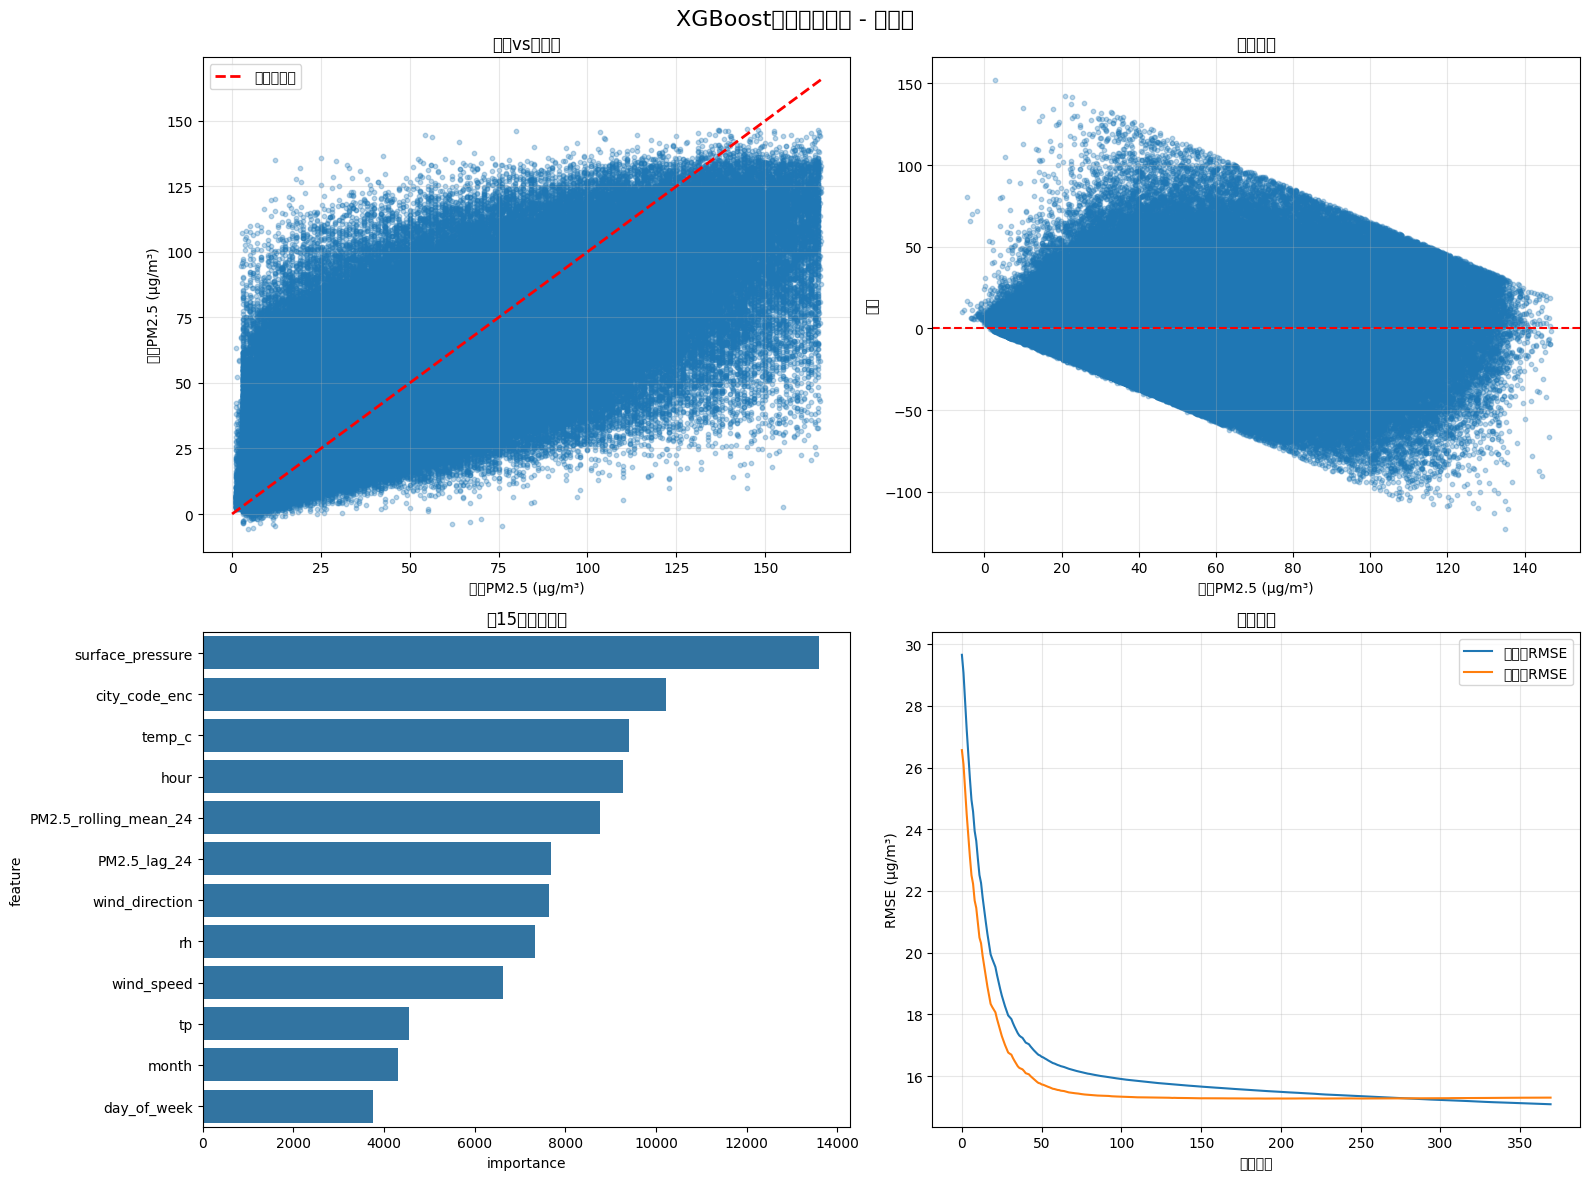


按城市分析模型性能

各城市性能排名 (前10名，按RMSE升序):
--------------------------------------------------------------------------------
排名   城市           数据量      RMSE       MAE        R2       MAPE      
--------------------------------------------------------------------------------
162  林芝市          2172     3.3399     2.3463     0.4462   41.46     %
224  甘孜藏族自治州      2172     3.6856     2.8397     0.2969   48.98     %
312  阿坝藏族羌族自治州    2171     3.9710     2.8392     0.4768   27.25     %
17   丽江市          2172     4.6767     3.3002     0.4712   30.71     %
2    三亚市          4317     5.1322     3.9017     0.6280   38.82     %
314  阿里地区         4315     5.5725     4.1705     -0.8775  100.64    %
220  玉树藏族自治州      2172     6.0739     4.1327     0.5066   74.10     %
40   凉山彝族自治州      2172     6.1609     4.3603     0.5432   29.33     %
332  黔东南苗族侗族自治州   2172     6.4339     4.8182     0.8487   19.37     %
132  惠州市          4317     6.5054     4.9363     0.7054   34.11     %

各城市性能排名 (后10名，按RMSE降序):
--------

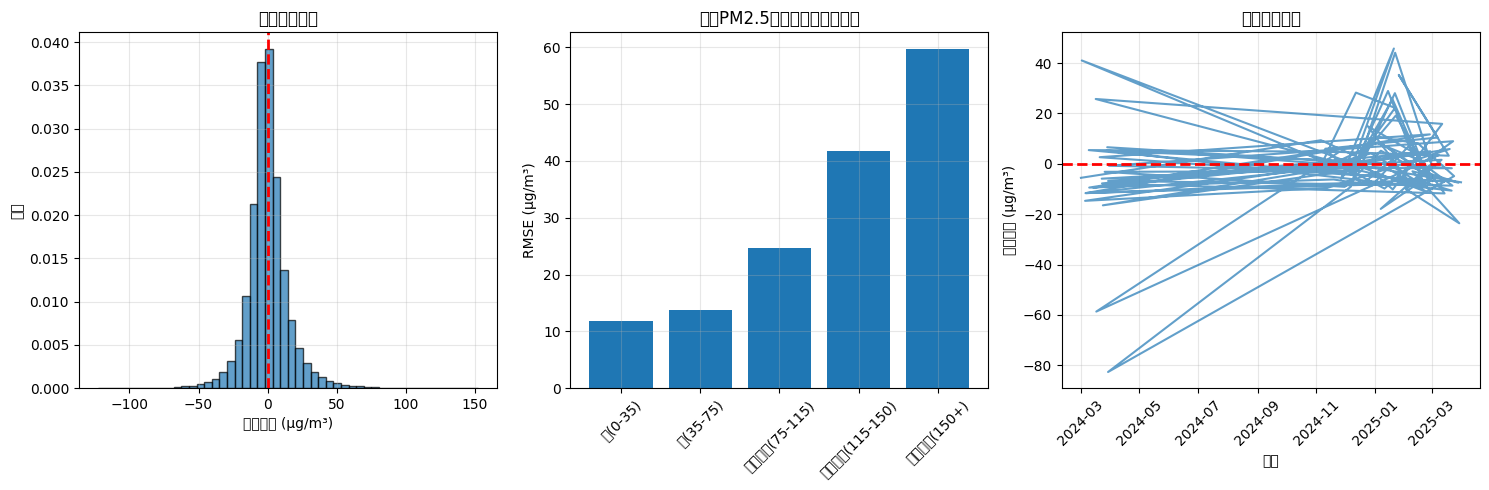


保存模型和结果
模型已保存为 'xgboost_pm25_model_complete.pkl'
预测结果已保存为 'xgboost_pm25_predictions.csv'

XGBoost模型训练总结
训练集样本数: 5,768,450
测试集样本数: 1,378,419
特征数量: 12

📊 性能指标:
  训练集 RMSE: 15.0866 μg/m³, R²: 0.7586
  测试集 RMSE: 15.3011 μg/m³, R²: 0.6862
  测试集 MAE: 10.4231 μg/m³, MAPE: 41.76%

🔍 过拟合检查: ✅ 拟合良好 (训练-测试RMSE差距: -0.2145)

🏙️ 城市性能统计:
  最佳城市 RMSE: 3.3399 μg/m³
  最差城市 RMSE: 24.2369 μg/m³
  平均城市 RMSE: 14.5350 μg/m³

🎯 最重要的5个特征:
  3. surface_pressure (13600.0000)
  12. city_code_enc (10223.0000)
  2. temp_c (9408.0000)
  9. hour (9268.0000)
  11. PM2.5_rolling_mean_24 (8773.0000)

✅ XGBoost模型训练完成！


In [14]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# -------------------------- XGBoost模型训练 --------------------------
print("开始训练XGBoost模型...")

# 检查数据是否存在
if 'train_data' not in locals() or 'test_data' not in locals():
    print("❌ 错误：train_data 或 test_data 未定义")
    print("请确保已经正确加载和分割了数据")
    exit()

# 检查必需列是否存在
required_columns = ['PM2.5']
for col in required_columns:
    if col not in train_data.columns:
        print(f"❌ 错误：train_data 缺少列 '{col}'")
        exit()
    if col not in test_data.columns:
        print(f"❌ 错误：test_data 缺少列 '{col}'")
        exit()

# 检查特征列
if 'final_feature_columns' not in locals():
    print("❌ 错误：final_feature_columns 未定义")
    print("请确保已经定义了特征列列表")
    exit()

# 打印数据信息
print(f"训练数据形状: {train_data.shape}")
print(f"测试数据形状: {test_data.shape}")
print(f"特征数量: {len(final_feature_columns)}")

# 准备训练和测试数据
X_train = train_data[final_feature_columns]
y_train = train_data['PM2.5']
X_test = test_data[final_feature_columns]
y_test = test_data['PM2.5']

print(f"训练集特征形状: {X_train.shape}")
print(f"测试集特征形状: {X_test.shape}")
print(f"训练集目标变量范围: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"测试集目标变量范围: [{y_test.min():.2f}, {y_test.max():.2f}]")

# 检查数据类型并修正类别特征
print(f"\n修正类别特征类型...")
category_columns = ['wind_category', 'temp_category', 'rh_category']
for col in category_columns:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(int)
        if col in X_test.columns:
            X_test[col] = X_test[col].astype(int)

print(f"修正后的特征数据类型:")
for col in X_train.columns[:5]:  # 只显示前5个特征
    print(f"{col:25} {X_train[col].dtype}")

# -------------------------- 使用原生XGBoost接口 --------------------------
print("\n使用原生XGBoost接口训练...")

# 转换为DMatrix格式
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=final_feature_columns)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=final_feature_columns)

# XGBoost参数配置
params = {
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,      # L1正则化
    'reg_lambda': 0.1,     # L2正则化
    'random_state': 42,
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}

print("\nXGBoost参数配置:")
for key, value in params.items():
    print(f"  {key}: {value}")

# 训练模型
print("\n开始训练模型...")
evals_result = {}
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50
)

print("模型训练完成!")

# -------------------------- 模型预测 --------------------------
print("\n进行预测...")
y_pred_train = xgb_model.predict(dtrain)
y_pred_test = xgb_model.predict(dtest)

# 由于没有标准化，预测值就是实际的PM2.5值
y_train_true = y_train.values
y_test_true = y_test.values
y_pred_train_true = y_pred_train
y_pred_test_true = y_pred_test

# -------------------------- 模型评估 --------------------------
def evaluate_model(y_true, y_pred, dataset_name):
    """评估模型性能"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # 计算平均绝对百分比误差
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

    print(f"\n{dataset_name}集评估结果:")
    print(f"RMSE: {rmse:.4f} μg/m³")
    print(f"MAE: {mae:.4f} μg/m³")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")

    # 计算其他统计量
    max_error = np.max(np.abs(y_true - y_pred))
    median_error = np.median(np.abs(y_true - y_pred))

    print(f"最大绝对误差: {max_error:.4f} μg/m³")
    print(f"误差中位数: {median_error:.4f} μg/m³")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MSE': mse, 'MAPE': mape,
            'MaxError': max_error, 'MedianError': median_error}

# 评估训练集和测试集
print("="*50)
train_metrics = evaluate_model(y_train_true, y_pred_train_true, "训练")
test_metrics = evaluate_model(y_test_true, y_pred_test_true, "测试")

# -------------------------- 特征重要性分析 --------------------------
print("\n" + "="*50)
print("特征重要性分析")
print("="*50)

# 获取特征重要性
importance_dict = xgb_model.get_score(importance_type='weight')

# 创建特征重要性DataFrame
importance_data = []
for feature in final_feature_columns:
    importance_data.append({
        'feature': feature,
        'importance': importance_dict.get(feature, 0)
    })

importance_df = pd.DataFrame(importance_data).sort_values('importance', ascending=False)

print("\n前15个最重要的特征:")
print("-" * 40)
for i, row in importance_df.head(15).iterrows():
    print(f"{i+1:2d}. {row['feature']:25} {row['importance']:.4f}")

# 特征重要性分组分析
print(f"\n特征重要性分组统计:")
feature_groups = {
    '时间序列特征': ['PM2.5_lag_24', 'PM2.5_rolling_mean_24', 'PM2.5_rolling_std_24'],
    '时间特征': ['hour', 'month', 'day_of_week', 'season', 'is_weekend', 'sin_day', 'cos_day'],
    '气象基础特征': ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp'],
    '气象工程特征': ['temp_pressure_ratio', 'wind_effect', 'comfort_index'],
    '类别特征': ['wind_category', 'temp_category', 'rh_category'],
    '空间特征': ['city_code_enc']
}

for group_name, features in feature_groups.items():
    # 只计算实际存在的特征
    existing_features = [f for f in features if f in importance_df['feature'].values]
    if existing_features:
        group_importance = importance_df[importance_df['feature'].isin(existing_features)]['importance'].sum()
        print(f"  {group_name:15} {group_importance:.4f} ({len(existing_features)}个特征)")

# -------------------------- 可视化结果 --------------------------
print("\n生成可视化结果...")

def plot_xgb_results(y_true, y_pred, importance_df, evals_result, title_suffix=""):
    """绘制XGBoost结果图表"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'XGBoost模型结果分析{title_suffix}', fontsize=16)

    # 1. 预测vs真实散点图
    axes[0, 0].scatter(y_true, y_pred, alpha=0.3, s=10)
    max_val = max(y_true.max(), y_pred.max())
    axes[0, 0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='完美预测线')
    axes[0, 0].set_xlabel('真实PM2.5 (μg/m³)')
    axes[0, 0].set_ylabel('预测PM2.5 (μg/m³)')
    axes[0, 0].set_title('预测vs真实值')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 残差图
    residuals = y_true - y_pred
    axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('预测PM2.5 (μg/m³)')
    axes[0, 1].set_ylabel('残差')
    axes[0, 1].set_title('残差分析')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. 特征重要性
    top_features = importance_df.head(15)
    sns.barplot(data=top_features, x='importance', y='feature', ax=axes[1, 0])
    axes[1, 0].set_title('前15个重要特征')

    # 4. 学习曲线
    if evals_result and 'train' in evals_result and 'test' in evals_result:
        train_rmse = evals_result['train']['rmse']
        test_rmse = evals_result['test']['rmse']
        axes[1, 1].plot(train_rmse, label='训练集RMSE')
        axes[1, 1].plot(test_rmse, label='测试集RMSE')
        axes[1, 1].set_xlabel('迭代次数')
        axes[1, 1].set_ylabel('RMSE (μg/m³)')
        axes[1, 1].legend()
        axes[1, 1].set_title('学习曲线')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 绘制测试集结果
plot_xgb_results(y_test_true, y_pred_test_true, importance_df, evals_result, " - 测试集")

# -------------------------- 按城市分析性能 --------------------------
print("\n" + "="*50)
print("按城市分析模型性能")
print("="*50)

test_data_with_pred = test_data.copy()
test_data_with_pred['PM2.5_pred'] = y_pred_test_true
test_data_with_pred['PM2.5_true'] = y_test_true

city_performance = []
for city in test_data_with_pred['NAME'].unique():
    city_data = test_data_with_pred[test_data_with_pred['NAME'] == city]
    if len(city_data) > 20:  # 只分析有足够数据的城市
        city_rmse = np.sqrt(mean_squared_error(city_data['PM2.5_true'], city_data['PM2.5_pred']))
        city_mae = mean_absolute_error(city_data['PM2.5_true'], city_data['PM2.5_pred'])
        city_r2 = r2_score(city_data['PM2.5_true'], city_data['PM2.5_pred'])
        city_mape = np.mean(np.abs((city_data['PM2.5_true'] - city_data['PM2.5_pred']) /
                                  np.clip(city_data['PM2.5_true'], 1, None))) * 100

        city_performance.append({
            '城市': city,
            '数据量': len(city_data),
            'RMSE': city_rmse,
            'MAE': city_mae,
            'R2': city_r2,
            'MAPE': city_mape
        })

if city_performance:
    city_performance_df = pd.DataFrame(city_performance).sort_values('RMSE')

    print("\n各城市性能排名 (前10名，按RMSE升序):")
    print("-" * 80)
    print(f"{'排名':<4} {'城市':<12} {'数据量':<8} {'RMSE':<10} {'MAE':<10} {'R2':<8} {'MAPE':<10}")
    print("-" * 80)
    for i, row in city_performance_df.head(10).iterrows():
        print(f"{i+1:<4} {row['城市']:<12} {row['数据量']:<8} {row['RMSE']:<10.4f} {row['MAE']:<10.4f} {row['R2']:<8.4f} {row['MAPE']:<10.2f}%")

    print(f"\n各城市性能排名 (后10名，按RMSE降序):")
    print("-" * 80)
    print(f"{'排名':<4} {'城市':<12} {'数据量':<8} {'RMSE':<10} {'MAE':<10} {'R2':<8} {'MAPE':<10}")
    print("-" * 80)
    for i, row in city_performance_df.tail(10).iterrows():
        rank = len(city_performance_df) - (9 - i)
        print(f"{rank:<4} {row['城市']:<12} {row['数据量']:<8} {row['RMSE']:<10.4f} {row['MAE']:<10.4f} {row['R2']:<8.4f} {row['MAPE']:<10.2f}%")
else:
    print("⚠️ 没有足够的数据进行城市性能分析")
    city_performance_df = pd.DataFrame()

# -------------------------- 误差分布分析 --------------------------
print("\n" + "="*50)
print("误差分布分析")
print("="*50)

errors = y_test_true - y_pred_test_true

print(f"误差统计:")
print(f"  平均误差: {errors.mean():.4f} μg/m³")
print(f"  误差标准差: {errors.std():.4f} μg/m³")
print(f"  最大正误差: {errors.max():.4f} μg/m³")
print(f"  最大负误差: {errors.min():.4f} μg/m³")
print(f"  误差偏度: {pd.Series(errors).skew():.4f}")
print(f"  误差峰度: {pd.Series(errors).kurtosis():.4f}")

# 绘制误差分布
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black', density=True)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('预测误差 (μg/m³)')
plt.ylabel('密度')
plt.title('预测误差分布')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
# 按PM2.5浓度区间的误差分析
bins = [0, 35, 75, 115, 150, 500]  # 空气质量等级分界
bin_labels = ['优(0-35)', '良(35-75)', '轻度污染(75-115)', '中度污染(115-150)', '重度污染(150+)']
test_data_with_pred['pm25_bin'] = pd.cut(test_data_with_pred['PM2.5_true'], bins=bins, labels=bin_labels)

bin_errors = test_data_with_pred.groupby('pm25_bin').apply(
    lambda x: np.sqrt(mean_squared_error(x['PM2.5_true'], x['PM2.5_pred']))
)

plt.bar(bin_errors.index, bin_errors.values)
plt.xticks(rotation=45)
plt.ylabel('RMSE (μg/m³)')
plt.title('不同PM2.5浓度区间的预测误差')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# 误差随时间的变化（抽样显示）
# 查找时间列的名称
time_columns = ['time', 'time_datetime', 'datetime', 'date']
time_col = None
for col in time_columns:
    if col in test_data_with_pred.columns:
        time_col = col
        break

if time_col:
    sample_indices = np.arange(0, len(errors), max(1, len(errors)//100))  # 最多100个点
    sample_dates = test_data_with_pred.iloc[sample_indices][time_col]
    sample_errors = errors[sample_indices]

    # 确保dates是datetime类型用于绘图
    if not pd.api.types.is_datetime64_any_dtype(sample_dates):
        sample_dates = pd.to_datetime(sample_dates)

    plt.plot(sample_dates, sample_errors, alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('时间')
    plt.ylabel('预测误差 (μg/m³)')
    plt.title('误差时间序列')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, '未找到时间列', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('误差时间序列 (无时间数据)')

plt.tight_layout()
plt.show()

# -------------------------- 模型保存 --------------------------
print("\n" + "="*50)
print("保存模型和结果")
print("="*50)

# 准备需要保存的对象
model_artifacts = {
    'model': xgb_model,
    'feature_columns': final_feature_columns,
    'feature_importance': importance_df,
    'train_metrics': train_metrics,
    'test_metrics': test_metrics,
    'city_performance': city_performance_df if not city_performance_df.empty else pd.DataFrame(),
    'evals_result': evals_result
}

# 添加标签编码器如果存在
if 'le_city' in locals():
    model_artifacts['label_encoder'] = le_city

# 添加城市列表如果存在
if 'all_cities' in locals():
    model_artifacts['city_list'] = all_cities

# 尝试从训练数据中获取分割日期
if 'time_datetime' in train_data.columns:
    split_date = train_data['time_datetime'].max()
    model_artifacts['split_date'] = split_date
    print(f"分割日期: {split_date}")

joblib.dump(model_artifacts, 'xgboost_pm25_model_complete.pkl')
print("模型已保存为 'xgboost_pm25_model_complete.pkl'")

# 保存预测结果
predictions_data = {
    'PM2.5_true': y_test_true,
    'PM2.5_pred': y_pred_test_true,
    'prediction_error': errors
}

# 添加时间和城市信息
time_cols_to_try = ['time_datetime', 'time', 'datetime']
for col in time_cols_to_try:
    if col in test_data.columns:
        predictions_data[col] = test_data[col]
        break

if 'NAME' in test_data.columns:
    predictions_data['NAME'] = test_data['NAME']

predictions_df = pd.DataFrame(predictions_data)
predictions_df.to_csv('xgboost_pm25_predictions.csv', index=False, encoding='utf-8-sig')
print("预测结果已保存为 'xgboost_pm25_predictions.csv'")

# -------------------------- 模型总结 --------------------------
print("\n" + "="*60)
print("XGBoost模型训练总结")
print("="*60)
print(f"训练集样本数: {len(X_train):,}")
print(f"测试集样本数: {len(X_test):,}")
print(f"特征数量: {len(final_feature_columns)}")

# 显示时间范围
train_time_info = ""
test_time_info = ""
if 'time_datetime' in train_data.columns:
    train_time_info = f"{train_data['time_datetime'].min()} 到 {train_data['time_datetime'].max()}"
if 'time_datetime' in test_data.columns:
    test_time_info = f"{test_data['time_datetime'].min()} 到 {test_data['time_datetime'].max()}"

if train_time_info:
    print(f"训练时间范围: {train_time_info}")
if test_time_info:
    print(f"测试时间范围: {test_time_info}")

print(f"\n📊 性能指标:")
print(f"  训练集 RMSE: {train_metrics['RMSE']:.4f} μg/m³, R²: {train_metrics['R2']:.4f}")
print(f"  测试集 RMSE: {test_metrics['RMSE']:.4f} μg/m³, R²: {test_metrics['R2']:.4f}")
print(f"  测试集 MAE: {test_metrics['MAE']:.4f} μg/m³, MAPE: {test_metrics['MAPE']:.2f}%")

# 过拟合检查
overfit_gap = train_metrics['RMSE'] - test_metrics['RMSE']
if overfit_gap < -2.0:
    overfit_status = '❌ 明显过拟合'
elif overfit_gap < -1.0:
    overfit_status = '⚠️ 可能存在过拟合'
elif abs(overfit_gap) < 0.5:
    overfit_status = '✅ 拟合良好'
else:
    overfit_status = '⚠️ 可能欠拟合'

print(f"\n🔍 过拟合检查: {overfit_status} (训练-测试RMSE差距: {overfit_gap:.4f})")

if not city_performance_df.empty:
    print(f"\n🏙️ 城市性能统计:")
    print(f"  最佳城市 RMSE: {city_performance_df['RMSE'].min():.4f} μg/m³")
    print(f"  最差城市 RMSE: {city_performance_df['RMSE'].max():.4f} μg/m³")
    print(f"  平均城市 RMSE: {city_performance_df['RMSE'].mean():.4f} μg/m³")

print(f"\n🎯 最重要的5个特征:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']} ({row['importance']:.4f})")

print("\n✅ XGBoost模型训练完成！")

In [ ]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# -------------------------- XGBoost模型训练 --------------------------
print("开始训练XGBoost模型...")

# 检查数据是否存在
if 'train_data' not in locals() or 'test_data' not in locals():
    print("❌ 错误：train_data 或 test_data 未定义")
    print("请确保已经正确加载和分割了数据")
    exit()

# 检查必需列是否存在
required_columns = ['PM2.5']
for col in required_columns:
    if col not in train_data.columns:
        print(f"❌ 错误：train_data 缺少列 '{col}'")
        exit()
    if col not in test_data.columns:
        print(f"❌ 错误：test_data 缺少列 '{col}'")
        exit()

# 检查特征列
if 'final_feature_columns' not in locals():
    print("❌ 错误：final_feature_columns 未定义")
    print("请确保已经定义了特征列列表")
    exit()

# 打印数据信息
print(f"训练数据形状: {train_data.shape}")
print(f"测试数据形状: {test_data.shape}")
print(f"特征数量: {len(final_feature_columns)}")

# 准备训练和测试数据
X_train = train_data[final_feature_columns]
y_train = train_data['PM2.5']
X_test = test_data[final_feature_columns]
y_test = test_data['PM2.5']

print(f"训练集特征形状: {X_train.shape}")
print(f"测试集特征形状: {X_test.shape}")
print(f"训练集目标变量范围: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"测试集目标变量范围: [{y_test.min():.2f}, {y_test.max():.2f}]")

# 检查数据类型并修正类别特征
print(f"\n修正类别特征类型...")
category_columns = ['wind_category', 'temp_category', 'rh_category']
for col in category_columns:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(int)
        if col in X_test.columns:
            X_test[col] = X_test[col].astype(int)

print(f"修正后的特征数据类型:")
for col in X_train.columns[:5]:  # 只显示前5个特征
    print(f"{col:25} {X_train[col].dtype}")

# -------------------------- 使用原生XGBoost接口 --------------------------
print("\n使用原生XGBoost接口训练...")

# 转换为DMatrix格式
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=final_feature_columns)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=final_feature_columns)

# XGBoost参数配置
params = {
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,      # L1正则化
    'reg_lambda': 0.1,     # L2正则化
    'random_state': 42,
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}

print("\nXGBoost参数配置:")
for key, value in params.items():
    print(f"  {key}: {value}")

# 训练模型
print("\n开始训练模型...")
evals_result = {}
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50
)

print("模型训练完成!")

# -------------------------- 模型预测 --------------------------
print("\n进行预测...")
y_pred_train = xgb_model.predict(dtrain)
y_pred_test = xgb_model.predict(dtest)

# 由于没有标准化，预测值就是实际的PM2.5值
y_train_true = y_train.values
y_test_true = y_test.values
y_pred_train_true = y_pred_train
y_pred_test_true = y_pred_test

# -------------------------- 模型评估 --------------------------
def evaluate_model(y_true, y_pred, dataset_name):
    """评估模型性能"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # 计算平均绝对百分比误差
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

    print(f"\n{dataset_name}集评估结果:")
    print(f"RMSE: {rmse:.4f} μg/m³")
    print(f"MAE: {mae:.4f} μg/m³")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")

    # 计算其他统计量
    max_error = np.max(np.abs(y_true - y_pred))
    median_error = np.median(np.abs(y_true - y_pred))

    print(f"最大绝对误差: {max_error:.4f} μg/m³")
    print(f"误差中位数: {median_error:.4f} μg/m³")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MSE': mse, 'MAPE': mape,
            'MaxError': max_error, 'MedianError': median_error}

# 评估训练集和测试集
print("="*50)
train_metrics = evaluate_model(y_train_true, y_pred_train_true, "训练")
test_metrics = evaluate_model(y_test_true, y_pred_test_true, "测试")

# -------------------------- 特征重要性分析 --------------------------
print("\n" + "="*50)
print("特征重要性分析")
print("="*50)

# 获取特征重要性
importance_dict = xgb_model.get_score(importance_type='weight')

# 创建特征重要性DataFrame
importance_data = []
for feature in final_feature_columns:
    importance_data.append({
        'feature': feature,
        'importance': importance_dict.get(feature, 0)
    })

importance_df = pd.DataFrame(importance_data).sort_values('importance', ascending=False)

print("\n前15个最重要的特征:")
print("-" * 40)
for i, row in importance_df.head(15).iterrows():
    print(f"{i+1:2d}. {row['feature']:25} {row['importance']:.4f}")

# 特征重要性分组分析
print(f"\n特征重要性分组统计:")
feature_groups = {
    '时间序列特征': ['PM2.5_lag_24', 'PM2.5_rolling_mean_24', 'PM2.5_rolling_std_24'],
    '时间特征': ['hour', 'month', 'day_of_week', 'season', 'is_weekend', 'sin_day', 'cos_day'],
    '气象基础特征': ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp'],
    '气象工程特征': ['temp_pressure_ratio', 'wind_effect', 'comfort_index'],
    '类别特征': ['wind_category', 'temp_category', 'rh_category'],
    '空间特征': ['city_code_enc']
}

for group_name, features in feature_groups.items():
    # 只计算实际存在的特征
    existing_features = [f for f in features if f in importance_df['feature'].values]
    if existing_features:
        group_importance = importance_df[importance_df['feature'].isin(existing_features)]['importance'].sum()
        print(f"  {group_name:15} {group_importance:.4f} ({len(existing_features)}个特征)")

# -------------------------- 可视化结果 --------------------------
print("\n生成可视化结果...")

def plot_xgb_results(y_true, y_pred, importance_df, evals_result, title_suffix=""):
    """绘制XGBoost结果图表"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'XGBoost模型结果分析{title_suffix}', fontsize=16)

    # 1. 预测vs真实散点图
    axes[0, 0].scatter(y_true, y_pred, alpha=0.3, s=10)
    max_val = max(y_true.max(), y_pred.max())
    axes[0, 0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='完美预测线')
    axes[0, 0].set_xlabel('真实PM2.5 (μg/m³)')
    axes[0, 0].set_ylabel('预测PM2.5 (μg/m³)')
    axes[0, 0].set_title('预测vs真实值')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 残差图
    residuals = y_true - y_pred
    axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('预测PM2.5 (μg/m³)')
    axes[0, 1].set_ylabel('残差')
    axes[0, 1].set_title('残差分析')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. 特征重要性
    top_features = importance_df.head(15)
    sns.barplot(data=top_features, x='importance', y='feature', ax=axes[1, 0])
    axes[1, 0].set_title('前15个重要特征')

    # 4. 学习曲线
    if evals_result and 'train' in evals_result and 'test' in evals_result:
        train_rmse = evals_result['train']['rmse']
        test_rmse = evals_result['test']['rmse']
        axes[1, 1].plot(train_rmse, label='训练集RMSE')
        axes[1, 1].plot(test_rmse, label='测试集RMSE')
        axes[1, 1].set_xlabel('迭代次数')
        axes[1, 1].set_ylabel('RMSE (μg/m³)')
        axes[1, 1].legend()
        axes[1, 1].set_title('学习曲线')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 绘制测试集结果
plot_xgb_results(y_test_true, y_pred_test_true, importance_df, evals_result, " - 测试集")

# -------------------------- 按城市分析性能 --------------------------
print("\n" + "="*50)
print("按城市分析模型性能")
print("="*50)

test_data_with_pred = test_data.copy()
test_data_with_pred['PM2.5_pred'] = y_pred_test_true
test_data_with_pred['PM2.5_true'] = y_test_true

city_performance = []
for city in test_data_with_pred['NAME'].unique():
    city_data = test_data_with_pred[test_data_with_pred['NAME'] == city]
    if len(city_data) > 20:  # 只分析有足够数据的城市
        city_rmse = np.sqrt(mean_squared_error(city_data['PM2.5_true'], city_data['PM2.5_pred']))
        city_mae = mean_absolute_error(city_data['PM2.5_true'], city_data['PM2.5_pred'])
        city_r2 = r2_score(city_data['PM2.5_true'], city_data['PM2.5_pred'])
        city_mape = np.mean(np.abs((city_data['PM2.5_true'] - city_data['PM2.5_pred']) /
                                  np.clip(city_data['PM2.5_true'], 1, None))) * 100

        city_performance.append({
            '城市': city,
            '数据量': len(city_data),
            'RMSE': city_rmse,
            'MAE': city_mae,
            'R2': city_r2,
            'MAPE': city_mape
        })

if city_performance:
    city_performance_df = pd.DataFrame(city_performance).sort_values('RMSE')

    print("\n各城市性能排名 (前10名，按RMSE升序):")
    print("-" * 80)
    print(f"{'排名':<4} {'城市':<12} {'数据量':<8} {'RMSE':<10} {'MAE':<10} {'R2':<8} {'MAPE':<10}")
    print("-" * 80)
    for i, row in city_performance_df.head(10).iterrows():
        print(f"{i+1:<4} {row['城市']:<12} {row['数据量']:<8} {row['RMSE']:<10.4f} {row['MAE']:<10.4f} {row['R2']:<8.4f} {row['MAPE']:<10.2f}%")

    print(f"\n各城市性能排名 (后10名，按RMSE降序):")
    print("-" * 80)
    print(f"{'排名':<4} {'城市':<12} {'数据量':<8} {'RMSE':<10} {'MAE':<10} {'R2':<8} {'MAPE':<10}")
    print("-" * 80)
    for i, row in city_performance_df.tail(10).iterrows():
        rank = len(city_performance_df) - (9 - i)
        print(f"{rank:<4} {row['城市']:<12} {row['数据量']:<8} {row['RMSE']:<10.4f} {row['MAE']:<10.4f} {row['R2']:<8.4f} {row['MAPE']:<10.2f}%")
else:
    print("⚠️ 没有足够的数据进行城市性能分析")
    city_performance_df = pd.DataFrame()

# -------------------------- 误差分布分析 --------------------------
print("\n" + "="*50)
print("误差分布分析")
print("="*50)

errors = y_test_true - y_pred_test_true

print(f"误差统计:")
print(f"  平均误差: {errors.mean():.4f} μg/m³")
print(f"  误差标准差: {errors.std():.4f} μg/m³")
print(f"  最大正误差: {errors.max():.4f} μg/m³")
print(f"  最大负误差: {errors.min():.4f} μg/m³")
print(f"  误差偏度: {pd.Series(errors).skew():.4f}")
print(f"  误差峰度: {pd.Series(errors).kurtosis():.4f}")

# 绘制误差分布
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black', density=True)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('预测误差 (μg/m³)')
plt.ylabel('密度')
plt.title('预测误差分布')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
# 按PM2.5浓度区间的误差分析
bins = [0, 35, 75, 115, 150, 500]  # 空气质量等级分界
bin_labels = ['优(0-35)', '良(35-75)', '轻度污染(75-115)', '中度污染(115-150)', '重度污染(150+)']
test_data_with_pred['pm25_bin'] = pd.cut(test_data_with_pred['PM2.5_true'], bins=bins, labels=bin_labels)

bin_errors = test_data_with_pred.groupby('pm25_bin').apply(
    lambda x: np.sqrt(mean_squared_error(x['PM2.5_true'], x['PM2.5_pred']))
)

plt.bar(bin_errors.index, bin_errors.values)
plt.xticks(rotation=45)
plt.ylabel('RMSE (μg/m³)')
plt.title('不同PM2.5浓度区间的预测误差')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# 误差随时间的变化（抽样显示）
# 查找时间列的名称
time_columns = ['time', 'time_datetime', 'datetime', 'date']
time_col = None
for col in time_columns:
    if col in test_data_with_pred.columns:
        time_col = col
        break

if time_col:
    sample_indices = np.arange(0, len(errors), max(1, len(errors)//100))  # 最多100个点
    sample_dates = test_data_with_pred.iloc[sample_indices][time_col]
    sample_errors = errors[sample_indices]

    # 确保dates是datetime类型用于绘图
    if not pd.api.types.is_datetime64_any_dtype(sample_dates):
        sample_dates = pd.to_datetime(sample_dates)

    plt.plot(sample_dates, sample_errors, alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('时间')
    plt.ylabel('预测误差 (μg/m³)')
    plt.title('误差时间序列')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, '未找到时间列', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('误差时间序列 (无时间数据)')

plt.tight_layout()
plt.show()

# -------------------------- 模型保存 --------------------------
print("\n" + "="*50)
print("保存模型和结果")
print("="*50)

# 准备需要保存的对象
model_artifacts = {
    'model': xgb_model,
    'feature_columns': final_feature_columns,
    'feature_importance': importance_df,
    'train_metrics': train_metrics,
    'test_metrics': test_metrics,
    'city_performance': city_performance_df if not city_performance_df.empty else pd.DataFrame(),
    'evals_result': evals_result
}

# 添加标签编码器如果存在
if 'le_city' in locals():
    model_artifacts['label_encoder'] = le_city

# 添加城市列表如果存在
if 'all_cities' in locals():
    model_artifacts['city_list'] = all_cities

# 尝试从训练数据中获取分割日期
if 'time_datetime' in train_data.columns:
    split_date = train_data['time_datetime'].max()
    model_artifacts['split_date'] = split_date
    print(f"分割日期: {split_date}")

# 🔧 修复保存路径问题 - 使用完整路径或清理文件名
try:
    # 方法1: 使用绝对路径保存
    save_path = r"E:/烟花污染/我用的/xgboost_pm25_model_complete.pkl"
    joblib.dump(model_artifacts, save_path)
    print(f"模型已保存为 '{save_path}'")
except Exception as e:
    print(f"保存到指定路径失败: {e}")
    try:
        # 方法2: 使用当前工作目录，去掉可能的非法字符
        filename = "xgboost_pm25_model_complete.pkl"
        joblib.dump(model_artifacts, filename)
        print(f"模型已保存为当前目录下的 '{filename}'")
    except Exception as e2:
        print(f"保存模型失败: {e2}")
        print("尝试使用其他格式保存...")
        # 方法3: 使用 pickle 直接保存
        import pickle
        pickle.dump(model_artifacts, open("xgboost_model.pkl", "wb"))
        print("模型已使用 pickle 保存为 'xgboost_model.pkl'")

# 保存预测结果
predictions_data = {
    'PM2.5_true': y_test_true,
    'PM2.5_pred': y_pred_test_true,
    'prediction_error': errors
}

# 添加时间和城市信息
time_cols_to_try = ['time_datetime', 'time', 'datetime']
for col in time_cols_to_try:
    if col in test_data.columns:
        predictions_data[col] = test_data[col]
        break

if 'NAME' in test_data.columns:
    predictions_data['NAME'] = test_data['NAME']

predictions_df = pd.DataFrame(predictions_data)
predictions_df.to_csv('xgboost_pm25_predictions.csv', index=False, encoding='utf-8-sig')
print("预测结果已保存为 'xgboost_pm25_predictions.csv'")

# -------------------------- 模型总结 --------------------------
print("\n" + "="*60)
print("XGBoost模型训练总结")
print("="*60)
print(f"训练集样本数: {len(X_train):,}")
print(f"测试集样本数: {len(X_test):,}")
print(f"特征数量: {len(final_feature_columns)}")

# 显示时间范围
train_time_info = ""
test_time_info = ""
if 'time_datetime' in train_data.columns:
    train_time_info = f"{train_data['time_datetime'].min()} 到 {train_data['time_datetime'].max()}"
if 'time_datetime' in test_data.columns:
    test_time_info = f"{test_data['time_datetime'].min()} 到 {test_data['time_datetime'].max()}"

if train_time_info:
    print(f"训练时间范围: {train_time_info}")
if test_time_info:
    print(f"测试时间范围: {test_time_info}")

print(f"\n📊 性能指标:")
print(f"  训练集 RMSE: {train_metrics['RMSE']:.4f} μg/m³, R²: {train_metrics['R2']:.4f}")
print(f"  测试集 RMSE: {test_metrics['RMSE']:.4f} μg/m³, R²: {test_metrics['R2']:.4f}")
print(f"  测试集 MAE: {test_metrics['MAE']:.4f} μg/m³, MAPE: {test_metrics['MAPE']:.2f}%")

# 过拟合检查
overfit_gap = train_metrics['RMSE'] - test_metrics['RMSE']
if overfit_gap < -2.0:
    overfit_status = '❌ 明显过拟合'
elif overfit_gap < -1.0:
    overfit_status = '⚠️ 可能存在过拟合'
elif abs(overfit_gap) < 0.5:
    overfit_status = '✅ 拟合良好'
else:
    overfit_status = '⚠️ 可能欠拟合'

print(f"\n🔍 过拟合检查: {overfit_status} (训练-测试RMSE差距: {overfit_gap:.4f})")

if not city_performance_df.empty:
    print(f"\n🏙️ 城市性能统计:")
    print(f"  最佳城市 RMSE: {city_performance_df['RMSE'].min():.4f} μg/m³")
    print(f"  最差城市 RMSE: {city_performance_df['RMSE'].max():.4f} μg/m³")
    print(f"  平均城市 RMSE: {city_performance_df['RMSE'].mean():.4f} μg/m³")

print(f"\n🎯 最重要的5个特征:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']} ({row['importance']:.4f})")

print("\n✅ XGBoost模型训练完成！")

开始训练XGBoost模型...
❌ 错误：train_data 或 test_data 未定义
请确保已经正确加载和分割了数据


NameError: name 'train_data' is not defined

: 

In [16]:
# -------------------------- 使用XGBoost模型预测春节/元宵节数据 --------------------------
print("="*60)
print("🎆 春节/元宵节PM2.5预测")
print("="*60)

# 首先加载训练好的模型
try:
    model_artifacts = joblib.load('xgboost_pm25_model_complete.pkl')
    xgb_model = model_artifacts['model']
    final_feature_columns = model_artifacts['feature_columns']
    print("✅ 已加载训练好的XGBoost模型")
    print(f"模型特征数量: {len(final_feature_columns)}")
except:
    print("❌ 无法加载模型文件")
    exit()

# 确保有原始数据
if 'df' not in locals():
    print("❌ 未找到原始数据df")
    exit()

# 检查原始数据是否包含必要的时间列
time_col_candidates = ['time_datetime', 'time', 'datetime', '观测时间']
time_col = None
for col in time_col_candidates:
    if col in df.columns:
        time_col = col
        break

if not time_col:
    print("❌ 未找到时间列")
    exit()

print(f"✅ 使用时间列: {time_col}")

# -------------------------- 准备节日数据 --------------------------
new_year_eves = [
    "2020-01-24", "2021-02-11", "2022-01-31",
    "2023-01-21", "2024-02-09", "2025-01-28"
]

lantern_festivals = [
    "2020-02-08", "2021-02-26", "2022-02-15",
    "2023-02-05", "2024-02-24", "2025-02-12"
]

all_festival_dates = new_year_eves + lantern_festivals
print(f"🎆 节日日期数量: {len(all_festival_dates)}")

# 转换时间列为datetime格式
df_festival = df.copy()
df_festival[time_col] = pd.to_datetime(df_festival[time_col], errors='coerce')

# 提取日期和小时信息
df_festival['date'] = df_festival[time_col].dt.date
df_festival['hour'] = df_festival[time_col].dt.hour
df_festival['year'] = df_festival[time_col].dt.year
df_festival['month'] = df_festival[time_col].dt.month
df_festival['day'] = df_festival[time_col].dt.day

# 筛选节日数据：20:00-23:59 和 0:00-3:00
festival_mask = (
    df_festival['date'].astype(str).isin(all_festival_dates) & 
    ((df_festival['hour'] >= 20) | (df_festival['hour'] <= 3))
)

festival_data_raw = df_festival[festival_mask].copy()

if len(festival_data_raw) == 0:
    print("❌ 未找到节日数据")
    exit()

print(f"✅ 找到原始节日数据: {len(festival_data_raw):,} 条")

# 添加节日类型
festival_data_raw['festival_type'] = festival_data_raw['date'].apply(
    lambda x: '除夕' if str(x) in new_year_eves else '元宵节'
)

# 添加节日年份标识
festival_data_raw['festival_year'] = festival_data_raw['date'].astype(str).apply(
    lambda x: '2020' if '2020' in x else 
              '2021' if '2021' in x else
              '2022' if '2022' in x else
              '2023' if '2023' in x else
              '2024' if '2024' in x else '2025'
)

# ======================== 第一步：简化版特征工程 ========================
print("\n" + "="*60)
print("第一步：简化特征工程")
print("="*60)

def create_simple_festival_features(df, time_col='time_datetime'):
    """
    创建简化特征（只保留指定特征）
    """
    df_features = df.copy()
    
    # 确保时间列是datetime格式
    if time_col in df_features.columns:
        df_features[time_col] = pd.to_datetime(df_features[time_col], errors='coerce')
    
    print("创建基础时间特征...")
    # 1. 基础时间特征（只保留这三个）
    df_features['month'] = df_features[time_col].dt.month
    df_features['day_of_week'] = df_features[time_col].dt.dayofweek
    df_features['hour'] = df_features[time_col].dt.hour
    
    # 2. 滞后特征和滚动特征
    print("创建滞后和滚动特征...")
    if 'PM2.5' in df_features.columns and 'NAME' in df_features.columns:
        # 24小时滞后
        df_features['PM2.5_lag_24'] = df_features.groupby('NAME')['PM2.5'].shift(24)
        
        # 24小时滚动均值
        df_features['PM2.5_rolling_mean_24'] = df_features.groupby('NAME')['PM2.5'].transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )
    
    # 3. 填充缺失值
    print("填充缺失值...")
    # 分组填充数值型特征
    if 'NAME' in df_features.columns:
        numeric_cols = ['wind_direction', 'temp_c', 'surface_pressure', 
                       'wind_speed', 'rh', 'tp', 'PM2.5_lag_24', 'PM2.5_rolling_mean_24']
        
        for col in numeric_cols:
            if col in df_features.columns:
                df_features[col] = df_features.groupby('NAME')[col].transform(
                    lambda x: x.ffill().bfill().fillna(x.mean() if not x.isnull().all() else 0)
                )
    
    # 4. 创建城市编码（如果模型需要）
    if 'NAME' in df_features.columns and 'city_code_enc' in final_feature_columns:
        print("创建城市编码...")
        try:
            if 'label_encoder' in model_artifacts:
                le_city = model_artifacts['label_encoder']
                known_cities = set(le_city.classes_)
                df_features['city_code_enc'] = df_features['NAME'].apply(
                    lambda x: le_city.transform([x])[0] if x in known_cities else 0
                )
        except:
            # 如果无法复用编码器，用0填充
            df_features['city_code_enc'] = 0
    
    print(f"特征工程完成，数据形状: {df_features.shape}")
    return df_features

# 对节日数据进行特征工程
festival_data_with_features = create_simple_festival_features(festival_data_raw, time_col=time_col)

# 定义我们需要的特征
simple_features = [
    # 基础气象特征
    "wind_direction", "temp_c", "surface_pressure", "wind_speed", "rh", "tp",
    # 时间特征
    "month", "day_of_week", "hour",
    # 滞后特征
    "PM2.5_lag_24", "PM2.5_rolling_mean_24",
    # 城市编码
    "city_code_enc"
]

print(f"\n使用的特征数量: {len(simple_features)}")
print(f"特征列表: {simple_features}")

# 检查是否包含所有需要的特征
print(f"\n检查特征完整性...")
missing_features = [col for col in final_feature_columns if col not in festival_data_with_features.columns]
if missing_features:
    print(f"⚠️ 缺少 {len(missing_features)} 个模型需要的特征")
    print(f"前10个缺失特征: {missing_features[:10]}")
    
    # 用0填充缺失特征
    print("用0填充缺失特征...")
    for feat in missing_features:
        festival_data_with_features[feat] = 0
    print("✅ 所有缺失特征已处理")
else:
    print("✅ 包含所有模型需要的特征")

# ======================== 第二步：使用模型进行预测 ========================
print("\n" + "="*60)
print("第二步：预测PM2.5")
print("="*60)

print("准备特征数据...")
# 确保所有特征列都存在
for col in final_feature_columns:
    if col not in festival_data_with_features.columns:
        festival_data_with_features[col] = 0

# 准备特征矩阵
X_festival = festival_data_with_features[final_feature_columns].copy()

print(f"预测数据形状: {X_festival.shape}")

# 转换为DMatrix格式并预测
dfestival = xgb.DMatrix(X_festival, feature_names=final_feature_columns)
pm25_predictions = xgb_model.predict(dfestival)

print(f"✅ 预测完成")

# ======================== 第三步：合并预测结果 ========================
print("\n" + "="*60)
print("第三步：合并预测结果")
print("="*60)

# 创建包含预测结果的节日数据
festival_data_with_results = festival_data_raw.copy()
festival_data_with_results['PM2.5_pred'] = pm25_predictions

# 添加所有特征工程中创建的特征（包括气象变量）
# 先复制所有可能用到的气象变量
meteorological_vars = ['wind_direction', 'temp_c', 'surface_pressure', 
                      'wind_speed', 'rh', 'tp']

for var in meteorological_vars:
    if var in festival_data_with_features.columns:
        festival_data_with_results[var] = festival_data_with_features[var]

# 添加时间特征
time_features = ['month', 'day_of_week', 'hour']
for feature in time_features:
    if feature in festival_data_with_features.columns:
        festival_data_with_results[feature] = festival_data_with_features[feature]

# 添加滞后特征（如果存在）
lag_features = ['PM2.5_lag_24', 'PM2.5_rolling_mean_24']
for feature in lag_features:
    if feature in festival_data_with_features.columns:
        festival_data_with_results[feature] = festival_data_with_features[feature]

# 如果有原始PM2.5值，计算差值
if 'PM2.5' in festival_data_with_results.columns:
    valid_mask = festival_data_with_results['PM2.5'].notna()
    if valid_mask.any():
        festival_data_with_results.loc[valid_mask, 'PM2.5_diff'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5'] - 
            festival_data_with_results.loc[valid_mask, 'PM2.5_pred']
        )
        
        # 添加绝对差值和相对误差
        festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5_diff'].abs()
        )
        
        # 相对误差（避免除以0）
        pm25_clipped = festival_data_with_results.loc[valid_mask, 'PM2.5'].clip(lower=1)
        festival_data_with_results.loc[valid_mask, 'PM2.5_relative_error_pct'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5_diff'] / pm25_clipped * 100
        )
        
        # 简单统计
        n_with_actual = valid_mask.sum()
        avg_diff = festival_data_with_results.loc[valid_mask, 'PM2.5_diff'].mean()
        avg_abs_diff = festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'].mean()
        
        print(f"有原始PM2.5值的记录: {n_with_actual:,} 条")
        print(f"平均差值: {avg_diff:.2f} μg/m³")
        print(f"平均绝对差值: {avg_abs_diff:.2f} μg/m³")
    else:
        print("⚠️ 没有有效的原始PM2.5值")

# ======================== 第四步：保存结果 ========================
print("\n" + "="*60)
print("第四步：保存结果")
print("="*60)

# 创建输出文件

output_file = os.path.join("E:/烟花污染/FINAL", "festival_predictions_with_meteorology.csv")

# 定义要保存的列（包括6个基础气象变量）
save_columns = [
    # 标识信息
    time_col, 'date', 'year', 'month', 'day', 'hour',
    'festival_type', 'festival_year', 'NAME', 
    
    # PM2.5相关
    'PM2.5', 'PM2.5_pred',
    
    # 6个基础气象变量
    'wind_direction', 'temp_c', 'surface_pressure', 
    'wind_speed', 'rh', 'tp',
    
    # 时间特征
    'day_of_week',
    
    # 滞后特征（如果存在）
]

# 添加滞后特征（如果存在）
lag_features_to_save = ['PM2.5_lag_24', 'PM2.5_rolling_mean_24']
for feat in lag_features_to_save:
    if feat in festival_data_with_results.columns:
        save_columns.append(feat)

# 添加误差统计（如果存在）
error_stats = ['PM2.5_diff', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct']
for stat in error_stats:
    if stat in festival_data_with_results.columns:
        save_columns.append(stat)

print(f"计划保存 {len(save_columns)} 个字段")
print(f"字段列表: {save_columns}")

# 只保留实际存在的列
available_columns = [col for col in save_columns if col in festival_data_with_results.columns]
print(f"实际存在的列: {len(available_columns)} 个")

# 检查气象变量是否都存在
meteo_vars_in_data = [var for var in meteorological_vars if var in available_columns]
print(f"\n包含的气象变量 ({len(meteo_vars_in_data)}个): {meteo_vars_in_data}")

# 保存数据
try:
    festival_data_with_results[available_columns].to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\n✅ 数据已保存: {output_file}")
    print(f"保存记录数: {len(festival_data_with_results):,}")
    
    # 显示文件大小
    import os
    if os.path.exists(output_file):
        file_size = os.path.getsize(output_file) / (1024 * 1024)  # MB
        print(f"文件大小: {file_size:.2f} MB")
    
except Exception as e:
    print(f"❌ 保存文件时出错: {e}")
    # 尝试简化版保存
    print("尝试简化保存...")
    try:
        minimal_columns = [time_col, 'date', 'festival_type', 'NAME', 'PM2.5', 'PM2.5_pred']
        minimal_columns = [col for col in minimal_columns if col in festival_data_with_results.columns]
        festival_data_with_results[minimal_columns].to_csv('festival_predictions_minimal.csv', index=False, encoding='utf-8-sig')
        print(f"✅ 简化版数据已保存: festival_predictions_minimal.csv")
    except Exception as e2:
        print(f"❌ 简化版保存也失败: {e2}")

# ======================== 第五步：统计摘要 ========================
print("\n" + "="*60)
print("第五步：统计摘要")
print("="*60)

# 按节日类型和年份统计
if 'festival_type' in festival_data_with_results.columns and 'festival_year' in festival_data_with_results.columns:
    print("\n按节日类型和年份统计:")
    stats_by_festival = festival_data_with_results.groupby(['festival_type', 'festival_year']).agg({
        'PM2.5': ['count', 'mean', 'std'],
        'PM2.5_pred': ['mean', 'std']
    }).round(2)
    
    # 重命名列
    stats_by_festival.columns = ['_'.join(col).strip('_') for col in stats_by_festival.columns]
    stats_by_festival = stats_by_festival.reset_index()
    
    # 保存统计摘要
    stats_file = 'festival_predictions_summary.csv'
    stats_by_festival.to_csv(stats_file, index=False, encoding='utf-8-sig')
    print(f"✅ 统计摘要已保存: {stats_file}")
    
    # 打印部分统计
    print("\n统计预览:")
    print(stats_by_festival.head(10).to_string(index=False))

# 按城市统计
if 'NAME' in festival_data_with_results.columns:
    city_stats = festival_data_with_results.groupby('NAME').agg({
        'PM2.5': ['count', 'mean'],
        'PM2.5_pred': 'mean',
        'PM2.5_abs_diff': 'mean' if 'PM2.5_abs_diff' in festival_data_with_results.columns else None
    }).round(2)
    
    # 过滤None值
    city_stats = city_stats.dropna(axis=1, how='all')
    city_stats.columns = ['_'.join(col).strip('_') for col in city_stats.columns]
    city_stats = city_stats.reset_index()
    
    # 保存城市统计
    city_stats_file = 'festival_predictions_city_stats.csv'
    city_stats.to_csv(city_stats_file, index=False, encoding='utf-8-sig')
    print(f"✅ 城市统计已保存: {city_stats_file}")
    
    print(f"\n覆盖城市数量: {city_stats['NAME'].nunique()}")
    print("城市统计预览:")
    print(city_stats.sort_values('PM2.5_count', ascending=False).head(10).to_string(index=False))

# 简单统计
print(f"\n预测结果统计:")
print(f"预测PM2.5均值: {festival_data_with_results['PM2.5_pred'].mean():.2f} μg/m³")
print(f"预测PM2.5范围: [{festival_data_with_results['PM2.5_pred'].min():.2f}, {festival_data_with_results['PM2.5_pred'].max():.2f}] μg/m³")

if 'PM2.5' in festival_data_with_results.columns:
    valid_pm25 = festival_data_with_results['PM2.5'].notna().sum()
    total_records = len(festival_data_with_results)
    if valid_pm25 > 0:
        print(f"有原始PM2.5值的比例: {valid_pm25/total_records*100:.1f}% ({valid_pm25:,}/{total_records:,})")

# 气象变量统计
print(f"\n气象变量统计:")
for var in meteorological_vars:
    if var in festival_data_with_results.columns:
        mean_val = festival_data_with_results[var].mean()
        std_val = festival_data_with_results[var].std()
        missing_pct = festival_data_with_results[var].isna().sum() / len(festival_data_with_results) * 100
        print(f"  {var}: 均值={mean_val:.2f}, 标准差={std_val:.2f}, 缺失={missing_pct:.1f}%")

print("\n🎯 春节/元宵节PM2.5预测完成！")
print(f"📁 主要输出文件: {output_file}")
print(f"📊 包含字段: {len(available_columns)} 个（包括6个气象变量）")
print("✅ 所有数据已保存，可用于进一步分析！")

🎆 春节/元宵节PM2.5预测
✅ 已加载训练好的XGBoost模型
模型特征数量: 12
✅ 使用时间列: time
🎆 节日日期数量: 12
✅ 找到原始节日数据: 31,588 条

第一步：简化特征工程
创建基础时间特征...
创建滞后和滚动特征...
填充缺失值...
创建城市编码...
特征工程完成，数据形状: (31588, 33)

使用的特征数量: 12
特征列表: ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp', 'month', 'day_of_week', 'hour', 'PM2.5_lag_24', 'PM2.5_rolling_mean_24', 'city_code_enc']

检查特征完整性...
✅ 包含所有模型需要的特征

第二步：预测PM2.5
准备特征数据...
预测数据形状: (31588, 12)
✅ 预测完成

第三步：合并预测结果
有原始PM2.5值的记录: 31,588 条
平均差值: 3.71 μg/m³
平均绝对差值: 33.97 μg/m³

第四步：保存结果
计划保存 23 个字段
字段列表: ['time', 'date', 'year', 'month', 'day', 'hour', 'festival_type', 'festival_year', 'NAME', 'PM2.5', 'PM2.5_pred', 'wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp', 'day_of_week', 'PM2.5_lag_24', 'PM2.5_rolling_mean_24', 'PM2.5_diff', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct']
实际存在的列: 23 个

包含的气象变量 (6个): ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp']

✅ 数据已保存: E:/烟花污染/FINAL\festival_predictions_with_meteorol

🎆 春节/元宵节PM2.5预测 - 完整流程
✅ 已加载训练好的XGBoost模型
模型特征数量: 22
特征列: ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp', 'month', 'day_of_week', 'hour', 'is_weekend']...
✅ 使用时间列: time_datetime
🎆 节日日期数量: 12
  除夕: 6天
  元宵节: 6天

处理时间列...
筛选节日时段数据...
✅ 找到原始节日时段数据: 26,298 条记录

第一步：对节日数据进行特征工程
  创建基础时间特征...
  创建气象组合特征...
  创建时间周期特征...
  创建季节特征...
  创建气象分类特征...
  创建滞后和滚动特征...
  填充缺失值...
  创建城市编码...
  警告: 发现 2 个未知城市，将用0填充
  特征工程完成，数据形状: (26298, 58)

检查特征完整性...
✅ 节日数据包含所有模型需要的特征

第二步：使用XGBoost模型进行预测
准备特征数据...
预测数据形状: (26298, 22)
特征数量: 22
转换为DMatrix格式...
开始预测...
✅ 预测完成！
预测值统计:
  范围: [3.67, 154.01] μg/m³
  均值: 59.98 μg/m³
  中位数: 57.35 μg/m³
  标准差: 29.14 μg/m³

第三步：合并预测结果到原始节日数据
合并预测结果...
计算预测值与原始值的差异...
📊 有原始PM2.5值的记录: 26,298 条 (100.0%)
📊 平均绝对误差: 36.10 μg/m³
📊 平均相对误差: 93.98%
📈 预测准确性指标:
  MAE (平均绝对误差): 36.10 μg/m³
  MSE (均方误差): 4121.61
  RMSE (均方根误差): 64.20 μg/m³
  MAPE (平均绝对百分比误差): 93.98%

🎯 节日数据分析

📊 按节日类型统计:
  元宵节   - 记录数:  13408, 预测均值:   57.5 ±  27.2 μg/m³
          实际均值:   58.3 μg

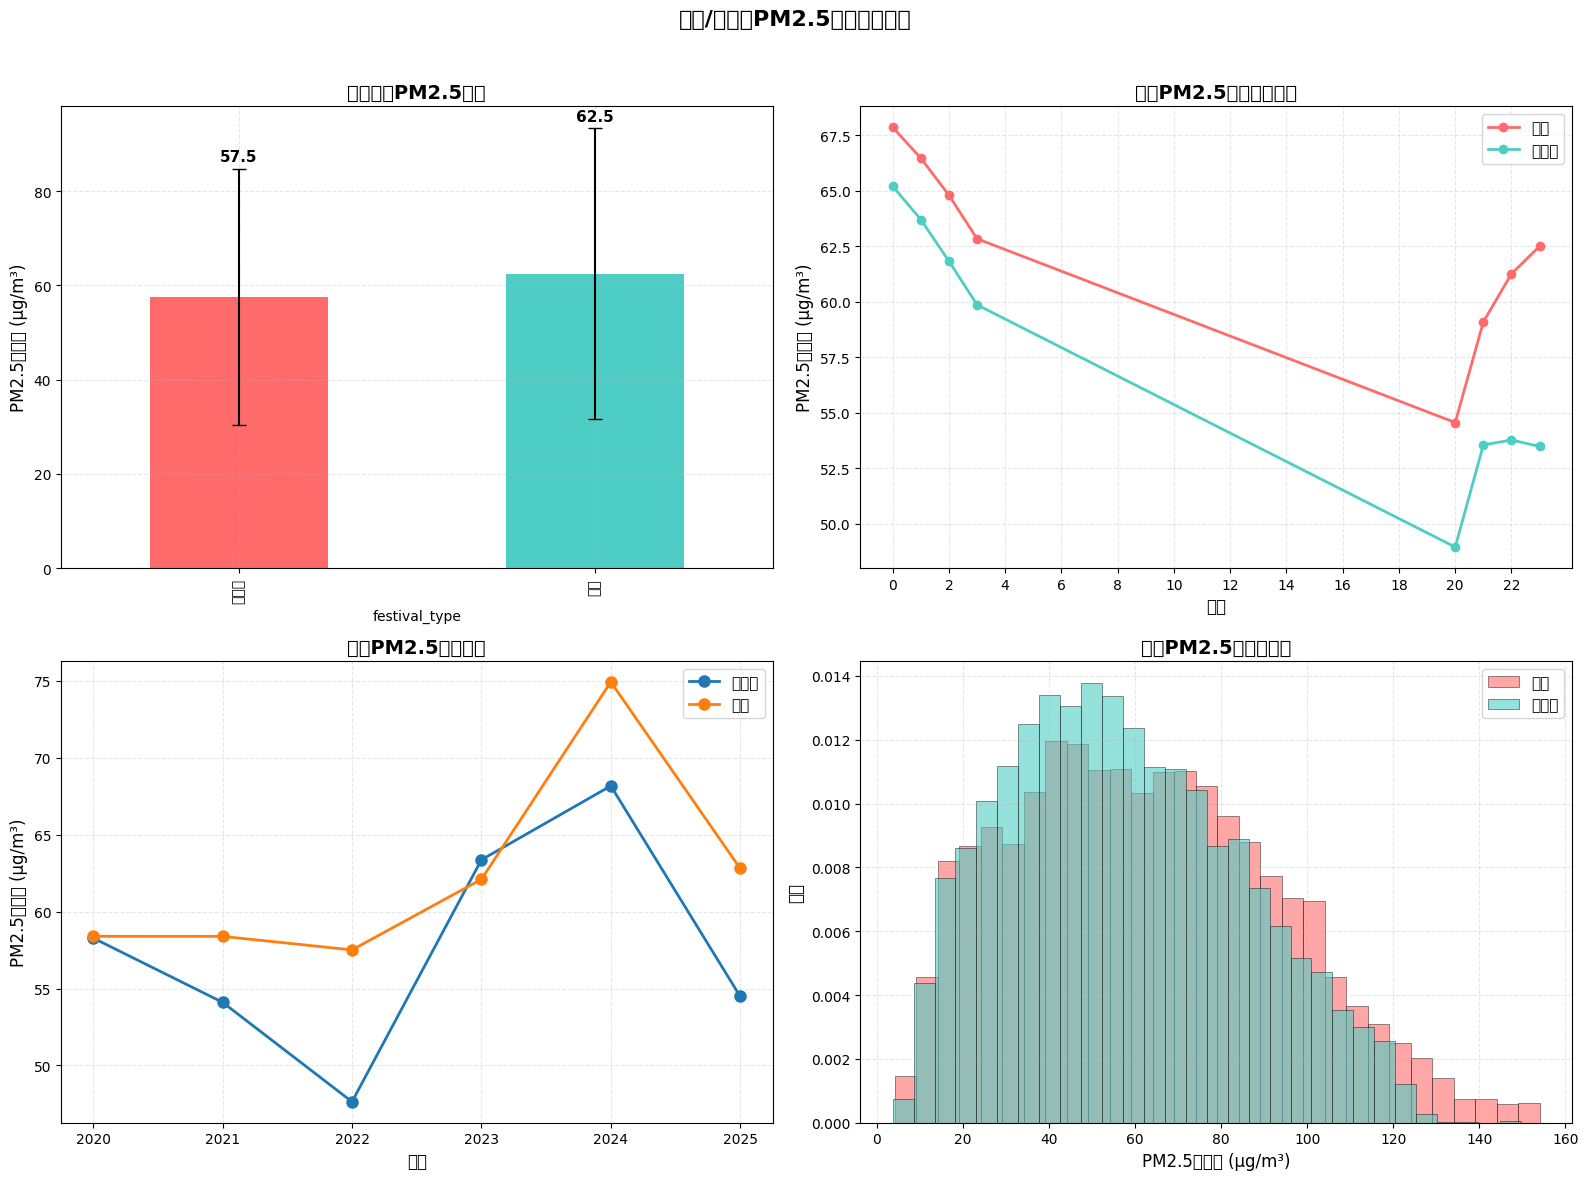

✅ 可视化图表已保存:
  📈 festival_predictions\festival_pm25_analysis.png
  📄 festival_predictions\festival_pm25_analysis.pdf

🎆 春节/元宵节PM2.5预测完成总结
📊 预测数据统计:
  • 总记录数: 26,298
  • 覆盖年份: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
  • 覆盖城市: 295个

🎯 预测结果:
  • 预测PM2.5均值: 60.0 μg/m³
  • 预测PM2.5范围: [3.7, 154.0] μg/m³
  • 预测标准差: 29.1 μg/m³

📈 预测准确性:
  • 有原始PM2.5值的记录: 26,298 条 (100.0%)
  • 平均绝对误差: 36.10 μg/m³
  • 平均相对误差: 93.98%

📅 节日对比:


In [ ]:
# -------------------------- 使用XGBoost模型预测春节/元宵节数据 --------------------------
print("="*60)
print("🎆 春节/元宵节PM2.5预测 - 完整流程")
print("="*60)

# 首先加载训练好的模型
try:
    model_artifacts = joblib.load('xgboost_pm25_model_complete.pkl')
    xgb_model = model_artifacts['model']
    final_feature_columns = model_artifacts['feature_columns']
    print("✅ 已加载训练好的XGBoost模型")
    print(f"模型特征数量: {len(final_feature_columns)}")
    print(f"特征列: {final_feature_columns[:10]}...")  # 显示前10个特征
except:
    print("❌ 无法加载模型文件，请确保模型已训练并保存")
    print("模型文件路径: xgboost_pm25_model_complete.pkl")
    exit()

# 确保有原始数据
if 'df' not in locals():
    print("❌ 未找到原始数据df，请确保已加载数据")
    exit()

# 检查原始数据是否包含必要的时间列
time_col_candidates = ['time_datetime', 'time', 'datetime', '观测时间']
time_col = None
for col in time_col_candidates:
    if col in df.columns:
        time_col = col
        break

if not time_col:
    print("❌ 未找到时间列，无法筛选节日数据")
    exit()

print(f"✅ 使用时间列: {time_col}")

# -------------------------- 准备节日数据 --------------------------
# 定义春节和元宵节日期（与R代码对应）
new_year_eves = [
    "2020-01-24", "2021-02-11", "2022-01-31",
    "2023-01-21", "2024-02-09", "2025-01-28"
]

lantern_festivals = [
    "2020-02-08", "2021-02-26", "2022-02-15",
    "2023-02-05", "2024-02-24", "2025-02-12"
]

all_festival_dates = new_year_eves + lantern_festivals
print(f"🎆 节日日期数量: {len(all_festival_dates)}")
print(f"  除夕: {len(new_year_eves)}天")
print(f"  元宵节: {len(lantern_festivals)}天")

# 转换时间列为datetime格式
print(f"\n处理时间列...")
df_festival = df.copy()
df_festival[time_col] = pd.to_datetime(df_festival[time_col], errors='coerce')

# 提取日期和小时信息
df_festival['date'] = df_festival[time_col].dt.date
df_festival['hour'] = df_festival[time_col].dt.hour
df_festival['year'] = df_festival[time_col].dt.year
df_festival['month'] = df_festival[time_col].dt.month
df_festival['day'] = df_festival[time_col].dt.day

# 筛选节日数据：20:00-23:59 和 0:00-3:00
print("筛选节日时段数据...")
festival_mask = (
    df_festival['date'].astype(str).isin(all_festival_dates) & 
    ((df_festival['hour'] >= 20) | (df_festival['hour'] <= 3))
)

festival_data_raw = df_festival[festival_mask].copy()

if len(festival_data_raw) == 0:
    print("❌ 未找到符合条件的节日数据")
    print("可能原因:")
    print("  1. 数据时间范围不包含这些节日")
    print("  2. 时间格式不正确")
    print("  3. 数据中没有20:00-3:00时段的数据")
    exit()

print(f"✅ 找到原始节日时段数据: {len(festival_data_raw):,} 条记录")

# 添加节日类型标识
festival_data_raw['festival_type'] = festival_data_raw['date'].apply(
    lambda x: '除夕' if str(x) in new_year_eves else '元宵节'
)

# ======================== 第一步：对节日数据做特征工程 ========================
print("\n" + "="*60)
print("第一步：对节日数据进行特征工程")
print("="*60)

def create_festival_features(df, time_col='time_datetime'):
    """
    为节日数据创建特征（与训练时保持一致）
    """
    df_features = df.copy()
    
    # 确保时间列是datetime格式
    if time_col in df_features.columns:
        df_features[time_col] = pd.to_datetime(df_features[time_col], errors='coerce')
    
    print("  创建基础时间特征...")
    # 1. 基础时间特征
    df_features['month'] = df_features[time_col].dt.month
    df_features['day_of_week'] = df_features[time_col].dt.dayofweek
    df_features['hour'] = df_features[time_col].dt.hour
    df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)
    
    # 2. 气象条件组合特征
    print("  创建气象组合特征...")
    if 'surface_pressure' in df_features.columns:
        df_features['surface_pressure_safe'] = df_features['surface_pressure'].clip(lower=900, upper=1100)
        df_features['temp_pressure_ratio'] = df_features['temp_c'] / df_features['surface_pressure_safe']
    
    if 'wind_speed' in df_features.columns and 'rh' in df_features.columns:
        df_features['wind_effect'] = df_features['wind_speed'] * (df_features['rh'].clip(1, 100) / 100)
    
    # 3. 时间周期特征
    print("  创建时间周期特征...")
    df_features['day_of_year'] = df_features[time_col].dt.dayofyear
    df_features['sin_day'] = np.sin(2 * np.pi * df_features['day_of_year'] / 365)
    df_features['cos_day'] = np.cos(2 * np.pi * df_features['day_of_year'] / 365)
    
    # 4. 季节特征
    print("  创建季节特征...")
    season_map = {12: 0, 1: 0, 2: 0,   # 冬季
                  3: 1, 4: 1, 5: 1,   # 春季
                  6: 2, 7: 2, 8: 2,   # 夏季
                  9: 3, 10: 3, 11: 3} # 秋季
    df_features['season'] = df_features['month'].map(season_map)
    
    # 5. 气象条件分类（分箱）
    print("  创建气象分类特征...")
    # 风速分类
    if 'wind_speed' in df_features.columns:
        try:
            df_features['wind_category'] = pd.qcut(df_features['wind_speed'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
        except:
            df_features['wind_category'] = 0
    
    # 温度分类
    if 'temp_c' in df_features.columns:
        try:
            df_features['temp_category'] = pd.qcut(df_features['temp_c'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
        except:
            df_features['temp_category'] = 0
    
    # 湿度分类
    if 'rh' in df_features.columns:
        try:
            df_features['rh_category'] = pd.qcut(df_features['rh'], q=4, labels=[0, 1, 2, 3], duplicates='drop')
        except:
            df_features['rh_category'] = 0
    
    # 6. 滞后特征和滚动特征
    print("  创建滞后和滚动特征...")
    # 这里需要注意：节日数据可能不连续，我们使用groupby但要小心处理
    if 'PM2.5' in df_features.columns and 'NAME' in df_features.columns:
        # 按城市分组计算滞后特征
        for lag in [1, 3, 6, 12, 24]:
            lag_col = f'PM2.5_lag_{lag}'
            df_features[lag_col] = df_features.groupby('NAME')['PM2.5'].shift(lag)
        
        # 滚动统计特征
        windows = [6, 12, 24]
        for window in windows:
            mean_col = f'PM2.5_rolling_mean_{window}'
            std_col = f'PM2.5_rolling_std_{window}'
            
            # 使用transform确保形状一致
            df_features[mean_col] = df_features.groupby('NAME')['PM2.5'].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )
            df_features[std_col] = df_features.groupby('NAME')['PM2.5'].transform(
                lambda x: x.rolling(window=window, min_periods=1).std()
            )
    
    # 7. 填充缺失值
    print("  填充缺失值...")
    numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
    
    # 分组填充数值型特征
    if 'NAME' in df_features.columns:
        for col in numeric_cols:
            if col in df_features.columns:
                # 先尝试前后填充，然后填充组均值
                df_features[col] = df_features.groupby('NAME')[col].transform(
                    lambda x: x.ffill().bfill().fillna(x.mean() if not x.isnull().all() else 0)
                )
    else:
        # 如果没有NAME列，直接填充
        for col in numeric_cols:
            if col in df_features.columns:
                df_features[col] = df_features[col].ffill().bfill().fillna(df_features[col].mean())
    
    # 8. 创建城市编码（如果模型需要）
    if 'NAME' in df_features.columns and 'city_code_enc' in final_feature_columns:
        print("  创建城市编码...")
        # 尝试复用训练时的编码器
        try:
            if 'label_encoder' in model_artifacts:
                le_city = model_artifacts['label_encoder']
                # 处理未知城市（用-1表示，后续会处理）
                known_cities = set(le_city.classes_)
                df_features['city_code_enc'] = df_features['NAME'].apply(
                    lambda x: le_city.transform([x])[0] if x in known_cities else -1
                )
                unknown_cities = df_features[df_features['city_code_enc'] == -1]['NAME'].unique()
                if len(unknown_cities) > 0:
                    print(f"  警告: 发现 {len(unknown_cities)} 个未知城市，将用0填充")
                    # 将未知城市编码设为0（或最频繁的城市编码）
                    most_freq_city = le_city.transform([le_city.classes_[0]])[0]
                    df_features.loc[df_features['city_code_enc'] == -1, 'city_code_enc'] = most_freq_city
        except:
            # 如果无法复用编码器，创建新编码
            print("  创建新的城市编码...")
            le_city_new = LabelEncoder()
            df_features['city_code_enc'] = le_city_new.fit_transform(df_features['NAME'])
    
    print(f"  特征工程完成，数据形状: {df_features.shape}")
    return df_features

# 对节日数据进行特征工程
festival_data_with_features = create_festival_features(festival_data_raw, time_col=time_col)

# 检查是否包含所有需要的特征
print(f"\n检查特征完整性...")
missing_features = [col for col in final_feature_columns if col not in festival_data_with_features.columns]
if missing_features:
    print(f"⚠️ 节日数据缺少 {len(missing_features)} 个模型需要的特征:")
    for i, feat in enumerate(missing_features[:10]):
        print(f"  {i+1}. {feat}")
    if len(missing_features) > 10:
        print(f"  ... 还有 {len(missing_features)-10} 个特征")
    
    # 尝试创建缺失的特征
    print("\n尝试创建缺失的特征...")
    for feat in missing_features:
        if feat.startswith('PM2.5_lag_') or feat.startswith('PM2.5_rolling_'):
            # 对于滞后和滚动特征，用PM2.5的均值填充
            festival_data_with_features[feat] = festival_data_with_features['PM2.5'].mean() if 'PM2.5' in festival_data_with_features.columns else 0
        elif feat in ['sin_day', 'cos_day']:
            # 时间周期特征
            if 'day_of_year' not in festival_data_with_features.columns:
                festival_data_with_features['day_of_year'] = festival_data_with_features[time_col].dt.dayofyear
            if feat == 'sin_day':
                festival_data_with_features[feat] = np.sin(2 * np.pi * festival_data_with_features['day_of_year'] / 365)
            else:
                festival_data_with_features[feat] = np.cos(2 * np.pi * festival_data_with_features['day_of_year'] / 365)
        else:
            # 其他特征用0填充
            festival_data_with_features[feat] = 0
    print("✅ 所有缺失特征已处理")
else:
    print("✅ 节日数据包含所有模型需要的特征")

# ======================== 第二步：使用模型进行预测 ========================
print("\n" + "="*60)
print("第二步：使用XGBoost模型进行预测")
print("="*60)

print("准备特征数据...")
# 确保所有特征列都存在
for col in final_feature_columns:
    if col not in festival_data_with_features.columns:
        festival_data_with_features[col] = 0

# 准备特征矩阵
X_festival = festival_data_with_features[final_feature_columns].copy()

# 确保类别特征类型一致
category_columns = ['wind_category', 'temp_category', 'rh_category']
for col in category_columns:
    if col in X_festival.columns:
        X_festival[col] = X_festival[col].astype(int)

print(f"预测数据形状: {X_festival.shape}")
print(f"特征数量: {len(final_feature_columns)}")

# 转换为DMatrix格式
print("转换为DMatrix格式...")
dfestival = xgb.DMatrix(X_festival, feature_names=final_feature_columns)

# 进行预测
print("开始预测...")
pm25_predictions = xgb_model.predict(dfestival)

print(f"✅ 预测完成！")
print(f"预测值统计:")
print(f"  范围: [{pm25_predictions.min():.2f}, {pm25_predictions.max():.2f}] μg/m³")
print(f"  均值: {pm25_predictions.mean():.2f} μg/m³")
print(f"  中位数: {np.median(pm25_predictions):.2f} μg/m³")
print(f"  标准差: {pm25_predictions.std():.2f} μg/m³")

# ======================== 第三步：合并预测结果到原始节日数据 ========================
print("\n" + "="*60)
print("第三步：合并预测结果到原始节日数据")
print("="*60)

# 创建包含预测结果的节日数据
print("合并预测结果...")
# 使用原始节日数据作为基础
festival_data_with_results = festival_data_raw.copy()

# 添加预测值
festival_data_with_results['PM2.5_pred'] = pm25_predictions

# 如果有原始PM2.5值，计算差值
if 'PM2.5' in festival_data_with_results.columns:
    print("计算预测值与原始值的差异...")
    # 过滤掉原始PM2.5为空的行
    valid_mask = festival_data_with_results['PM2.5'].notna()
    
    if valid_mask.sum() > 0:
        festival_data_with_results.loc[valid_mask, 'PM2.5_diff'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5'] - 
            festival_data_with_results.loc[valid_mask, 'PM2.5_pred']
        )
        
        festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5_diff'].abs()
        )
        
        # 计算相对误差百分比
        festival_data_with_results.loc[valid_mask, 'PM2.5_rel_error'] = (
            festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'] / 
            (festival_data_with_results.loc[valid_mask, 'PM2.5'] + 1e-6) * 100  # 避免除零
        )
        
        # 统计有原始值的数据
        n_with_actual = valid_mask.sum()
        avg_abs_diff = festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'].mean()
        avg_rel_error = festival_data_with_results.loc[valid_mask, 'PM2.5_rel_error'].mean()
        
        print(f"📊 有原始PM2.5值的记录: {n_with_actual:,} 条 ({n_with_actual/len(festival_data_with_results)*100:.1f}%)")
        print(f"📊 平均绝对误差: {avg_abs_diff:.2f} μg/m³")
        print(f"📊 平均相对误差: {avg_rel_error:.2f}%")
        
        # 预测准确性统计
        mae = festival_data_with_results.loc[valid_mask, 'PM2.5_abs_diff'].mean()
        mse = (festival_data_with_results.loc[valid_mask, 'PM2.5_diff'] ** 2).mean()
        rmse = np.sqrt(mse)
        mape = festival_data_with_results.loc[valid_mask, 'PM2.5_rel_error'].mean()
        
        print(f"📈 预测准确性指标:")
        print(f"  MAE (平均绝对误差): {mae:.2f} μg/m³")
        print(f"  MSE (均方误差): {mse:.2f}")
        print(f"  RMSE (均方根误差): {rmse:.2f} μg/m³")
        print(f"  MAPE (平均绝对百分比误差): {mape:.2f}%")
    else:
        print("⚠️ 节日数据中没有有效的原始PM2.5值")
else:
    print("⚠️ 节日数据中没有PM2.5列")

# 添加预测标识和模型信息
festival_data_with_results['prediction_timestamp'] = pd.Timestamp.now()
festival_data_with_results['model_version'] = 'xgboost_pm25_festival_v1'
festival_data_with_results['prediction_method'] = 'XGBoost'

# 添加特征数量信息
festival_data_with_results['feature_count'] = len(final_feature_columns)

# ======================== 节日数据分析 ========================
print("\n" + "="*60)
print("🎯 节日数据分析")
print("="*60)

# 按节日类型分析
print("\n📊 按节日类型统计:")
festival_summary = festival_data_with_results.groupby('festival_type').agg({
    'PM2.5': ['count', 'mean', 'std', 'min', 'max'] if 'PM2.5' in festival_data_with_results.columns else ('PM2.5', 'count'),
    'PM2.5_pred': ['mean', 'std', 'min', 'max'],
    'PM2.5_diff': ['mean', 'std'] if 'PM2.5_diff' in festival_data_with_results.columns else ('PM2.5_diff', 'count'),
    'PM2.5_abs_diff': ['mean'] if 'PM2.5_abs_diff' in festival_data_with_results.columns else ('PM2.5_abs_diff', 'count')
}).round(2)

# 简化列名
festival_summary.columns = ['_'.join(col).strip() for col in festival_summary.columns]
festival_summary = festival_summary.reset_index()

for _, row in festival_summary.iterrows():
    festival = row['festival_type']
    if 'PM2.5_count' in row:
        count = row['PM2.5_count']
    else:
        count = len(festival_data_with_results[festival_data_with_results['festival_type'] == festival])
    
    pred_mean = row['PM2.5_pred_mean']
    pred_std = row['PM2.5_pred_std']
    
    print(f"  {festival:5} - 记录数: {count:>6}, 预测均值: {pred_mean:>6.1f} ± {pred_std:>5.1f} μg/m³")
    
    if 'PM2.5_mean' in row:
        actual_mean = row['PM2.5_mean']
        diff_mean = row['PM2.5_diff_mean']
        print(f"          实际均值: {actual_mean:>6.1f} μg/m³, 平均差异: {diff_mean:>6.1f} μg/m³")

# 按年份分析
print(f"\n📅 按年份统计:")
yearly_summary = festival_data_with_results.groupby(['year', 'festival_type']).agg({
    'PM2.5_pred': ['mean', 'count']
}).round(2)

yearly_summary.columns = ['_'.join(col).strip() for col in yearly_summary.columns]
yearly_summary = yearly_summary.reset_index()

for year in sorted(yearly_summary['year'].unique()):
    year_data = yearly_summary[yearly_summary['year'] == year]
    print(f"\n  {year}年:")
    for _, row in year_data.iterrows():
        festival = row['festival_type']
        mean_val = row['PM2.5_pred_mean']
        count = row['PM2.5_pred_count']
        print(f"    {festival:5}: {mean_val:>6.1f} μg/m³ ({count}条记录)")

# 按小时分析
print(f"\n⏰ 按小时统计预测PM2.5:")
hourly_summary = festival_data_with_results.groupby(['festival_type', 'hour']).agg({
    'PM2.5_pred': 'mean'
}).round(2).reset_index()

# 找出每个节日类型中PM2.5最高的时段
for festival in ['除夕', '元宵节']:
    festival_hours = hourly_summary[hourly_summary['festival_type'] == festival]
    if not festival_hours.empty:
        max_hour = festival_hours.loc[festival_hours['PM2.5_pred'].idxmax()]
        min_hour = festival_hours.loc[festival_hours['PM2.5_pred'].idxmin()]
        print(f"  {festival} - 最高PM2.5在 {int(max_hour['hour']):02d}:00, 值: {max_hour['PM2.5_pred']:.1f} μg/m³")
        print(f"  {festival} - 最低PM2.5在 {int(min_hour['hour']):02d}:00, 值: {min_hour['PM2.5_pred']:.1f} μg/m³")

# ======================== 保存结果 ========================
print("\n" + "="*60)
print("💾 保存节日预测结果")
print("="*60)

# 创建专用目录
output_dir = 'festival_predictions'
os.makedirs(output_dir, exist_ok=True)
print(f"输出目录: {output_dir}")

# 1. 保存完整节日数据（包含预测值和原始值）
full_festival_path = os.path.join(output_dir, 'festival_pm25_predictions_complete.csv')

# 选择要保存的列
base_columns = [
    time_col, 'date', 'year', 'month', 'day', 'hour',
    'festival_type', 'NAME', 'city_code'
]

prediction_columns = [
    'PM2.5', 'PM2.5_pred', 'PM2.5_diff', 'PM2.5_abs_diff', 'PM2.5_rel_error'
] if 'PM2.5' in festival_data_with_results.columns else ['PM2.5_pred']

weather_columns = [
    'wind_speed', 'wind_direction', 'temp_c', 'rh', 'tp', 'surface_pressure'
]

model_columns = [
    'model_version', 'prediction_method', 'feature_count', 'prediction_timestamp'
]

# 只保留实际存在的列
all_save_columns = base_columns + prediction_columns + weather_columns + model_columns
available_columns = [col for col in all_save_columns if col in festival_data_with_results.columns]

print(f"保存列数: {len(available_columns)}")
festival_data_to_save = festival_data_with_results[available_columns]

# 按时间排序
if time_col in festival_data_to_save.columns:
    festival_data_to_save = festival_data_to_save.sort_values([time_col, 'NAME'])

festival_data_to_save.to_csv(full_festival_path, index=False, encoding='utf-8-sig')
print(f"✅ 完整节日数据已保存: {full_festival_path}")
print(f"  记录数: {len(festival_data_to_save):,}")
print(f"  文件大小: {os.path.getsize(full_festival_path)/1024/1024:.2f} MB")

# 2. 保存汇总统计
summary_path = os.path.join(output_dir, 'festival_pm25_summary_statistics.csv')

# 创建更详细的汇总
detailed_summary = festival_data_with_results.groupby(['festival_type', 'year', 'hour']).agg({
    'PM2.5_pred': ['mean', 'std', 'count', 'min', 'max'],
    'PM2.5': ['mean', 'std', 'count'] if 'PM2.5' in festival_data_with_results.columns else pd.Series([np.nan]),
    'PM2.5_diff': ['mean', 'std'] if 'PM2.5_diff' in festival_data_with_results.columns else pd.Series([np.nan])
}).round(2)

detailed_summary.columns = ['_'.join(col).strip() for col in detailed_summary.columns]
detailed_summary = detailed_summary.reset_index()
detailed_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
print(f"✅ 节日汇总数据已保存: {summary_path}")

# 3. 保存各城市节日数据（便于分城市分析）
if 'NAME' in festival_data_with_results.columns:
    city_summary_path = os.path.join(output_dir, 'festival_pm25_by_city.csv')
    
    city_festival_summary = festival_data_with_results.groupby(['NAME', 'festival_type', 'year']).agg({
        'PM2.5_pred': ['mean', 'std', 'count', 'min', 'max'],
        'PM2.5': ['mean', 'std', 'count'] if 'PM2.5' in festival_data_with_results.columns else pd.Series([np.nan]),
        'PM2.5_diff': ['mean', 'std'] if 'PM2.5_diff' in festival_data_with_results.columns else pd.Series([np.nan])
    }).round(2)
    
    city_festival_summary.columns = ['_'.join(col).strip() for col in city_festival_summary.columns]
    city_festival_summary = city_festival_summary.reset_index()
    city_festival_summary.to_csv(city_summary_path, index=False, encoding='utf-8-sig')
    print(f"✅ 城市节日数据已保存: {city_summary_path}")
    print(f"  涉及城市数: {city_festival_summary['NAME'].nunique()}")

# 4. 保存特征数据（供后续分析使用）
features_path = os.path.join(output_dir, 'festival_features_data.csv')
festival_data_with_features[final_feature_columns + ['NAME', time_col, 'festival_type']].to_csv(
    features_path, index=False, encoding='utf-8-sig'
)
print(f"✅ 节日特征数据已保存: {features_path}")

# ======================== 生成可视化报告 ========================
print("\n" + "="*60)
print("📈 生成可视化报告")
print("="*60)

try:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('春节/元宵节PM2.5预测结果分析', fontsize=16, fontweight='bold')

    # 1. 节日类型对比
    ax1 = axes[0, 0]
    festival_means = festival_data_with_results.groupby('festival_type')['PM2.5_pred'].mean()
    festival_stds = festival_data_with_results.groupby('festival_type')['PM2.5_pred'].std()
    bars = festival_means.plot(kind='bar', yerr=festival_stds, ax=ax1, capsize=5, color=['#FF6B6B', '#4ECDC4'])
    ax1.set_ylabel('PM2.5预测值 (μg/m³)', fontsize=12)
    ax1.set_title('节日类型PM2.5对比', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 在柱状图上添加数值
    for i, (idx, val) in enumerate(festival_means.items()):
        ax1.text(i, val + festival_stds[idx] + 1, f'{val:.1f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 2. 按小时变化趋势
    ax2 = axes[0, 1]
    for festival in ['除夕', '元宵节']:
        festival_hour_data = festival_data_with_results[festival_data_with_results['festival_type'] == festival]
        hourly_mean = festival_hour_data.groupby('hour')['PM2.5_pred'].mean()
        line_style = 'o-' if festival == '除夕' else 's--'
        color = '#FF6B6B' if festival == '除夕' else '#4ECDC4'
        hourly_mean.plot(ax=ax2, marker='o', label=festival, linewidth=2, markersize=6, color=color)
    ax2.set_xlabel('小时', fontsize=12)
    ax2.set_ylabel('PM2.5预测值 (μg/m³)', fontsize=12)
    ax2.set_title('节日PM2.5小时变化趋势', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(range(0, 24, 2))

    # 3. 按年份变化
    ax3 = axes[1, 0]
    yearly_festival_means = festival_data_with_results.groupby(['year', 'festival_type'])['PM2.5_pred'].mean().unstack()
    yearly_festival_means.plot(ax=ax3, marker='o', linewidth=2, markersize=8)
    ax3.set_xlabel('年份', fontsize=12)
    ax3.set_ylabel('PM2.5预测值 (μg/m³)', fontsize=12)
    ax3.set_title('节日PM2.5年度变化', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(fontsize=11)

    # 4. 预测值分布
    ax4 = axes[1, 1]
    colors = {'除夕': '#FF6B6B', '元宵节': '#4ECDC4'}
    for festival in ['除夕', '元宵节']:
        festival_data = festival_data_with_results[festival_data_with_results['festival_type'] == festival]['PM2.5_pred']
        ax4.hist(festival_data, bins=30, alpha=0.6, label=festival, 
                density=True, color=colors[festival], edgecolor='black', linewidth=0.5)
    ax4.set_xlabel('PM2.5预测值 (μg/m³)', fontsize=12)
    ax4.set_ylabel('密度', fontsize=12)
    ax4.set_title('节日PM2.5预测值分布', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(output_dir, 'festival_pm25_analysis.png'), dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'festival_pm25_analysis.pdf'), bbox_inches='tight')
    plt.show()
    
    print(f"✅ 可视化图表已保存:")
    print(f"  📈 {os.path.join(output_dir, 'festival_pm25_analysis.png')}")
    print(f"  📄 {os.path.join(output_dir, 'festival_pm25_analysis.pdf')}")
    
except Exception as e:
    print(f"⚠️ 生成可视化图表时出错: {e}")
    print("  跳过可视化步骤...")

# ======================== 最终总结 ========================
print("\n" + "="*60)
print("🎆 春节/元宵节PM2.5预测完成总结")
print("="*60)

print(f"📊 预测数据统计:")
print(f"  • 总记录数: {len(festival_data_with_results):,}")
print(f"  • 覆盖年份: {sorted(festival_data_with_results['year'].unique())}")
print(f"  • 覆盖城市: {festival_data_with_results['NAME'].nunique() if 'NAME' in festival_data_with_results.columns else 'N/A'}个")

print(f"\n🎯 预测结果:")
print(f"  • 预测PM2.5均值: {festival_data_with_results['PM2.5_pred'].mean():.1f} μg/m³")
print(f"  • 预测PM2.5范围: [{festival_data_with_results['PM2.5_pred'].min():.1f}, {festival_data_with_results['PM2.5_pred'].max():.1f}] μg/m³")
print(f"  • 预测标准差: {festival_data_with_results['PM2.5_pred'].std():.1f} μg/m³")

if 'PM2.5' in festival_data_with_results.columns:
    valid_pm25 = festival_data_with_results['PM2.5'].notna().sum()
    if valid_pm25 > 0:
        print(f"\n📈 预测准确性:")
        print(f"  • 有原始PM2.5值的记录: {valid_pm25:,} 条 ({valid_pm25/len(festival_data_with_results)*100:.1f}%)")
        print(f"  • 平均绝对误差: {festival_data_with_results['PM2.5_abs_diff'].mean():.2f} μg/m³")
        print(f"  • 平均相对误差: {festival_data_with_results['PM2.5_rel_error'].mean():.2f}%")

print(f"\n📅 节日对比:")
for festival in ['除夕', '元宵节']:
    festival_data = festival_data_with_results[festival_data_with_results['festival_type'] == festival]
    if len(festival_data) > 0:
        mean_val

In [ ]:
# -------------------------- 数据质量修复与优化 --------------------------
print("\n" + "="*50)
print("🔧 数据质量修复与优化")
print("="*50)

# 1. 修复负值预测（物理约束）
df_with_predictions['PM2.5_pred_corrected'] = df_with_predictions['PM2.5_pred'].clip(lower=0)
negative_count = (df_with_predictions['PM2.5_pred'] < 0).sum()
print(f"✅ 修复负值预测: {negative_count:,} 条记录被修正（设为0）")

# 2. 处理异常差值（基于统计方法）
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    # 计算IQR范围
    Q1 = df_with_predictions['PM2.5_diff_actual_minus_pred'].quantile(0.25)
    Q3 = df_with_predictions['PM2.5_diff_actual_minus_pred'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # 使用3倍IQR（比1.5倍更宽松）
    upper_bound = Q3 + 3 * IQR
    
    # 识别异常值但不删除（仅标记）
    df_with_predictions['is_outlier'] = (
        (df_with_predictions['PM2.5_diff_actual_minus_pred'] < lower_bound) | 
        (df_with_predictions['PM2.5_diff_actual_minus_pred'] > upper_bound)
    )
    
    outlier_count = df_with_predictions['is_outlier'].sum()
    outlier_pct = (outlier_count / len(df_with_predictions)) * 100
    print(f"📊 异常值检测（3倍IQR）:")
    print(f"  异常值数量: {outlier_count:,} 条")
    print(f"  异常值比例: {outlier_pct:.2f}%")
    print(f"  正常范围: [{lower_bound:.2f}, {upper_bound:.2f}] μg/m³")

# 3. 重新计算修复后的差值
df_with_predictions['PM2.5_diff_corrected'] = (
    df_with_predictions['PM2.5'] - df_with_predictions['PM2.5_pred_corrected']
)
df_with_predictions['PM2.5_abs_diff_corrected'] = np.abs(df_with_predictions['PM2.5_diff_corrected'])

# 4. 性能指标重新计算（剔除异常值）
if outlier_count > 0:
    normal_data = df_with_predictions[~df_with_predictions['is_outlier']].copy()
    print(f"\n🎯 剔除异常值后的性能指标:")
    print(f"  平均绝对误差(MAE): {normal_data['PM2.5_abs_diff_corrected'].mean():.2f} μg/m³")
    print(f"  均方根误差(RMSE): {np.sqrt((normal_data['PM2.5_diff_corrected']**2).mean()):.2f} μg/m³")
    print(f"  平均偏差(MBE): {normal_data['PM2.5_diff_corrected'].mean():.2f} μg/m³")

# -------------------------- 保存优化后的结果 --------------------------
print("\n💾 保存优化后的数据...")

# 保存包含质量标记的数据
quality_path = os.path.join(output_dir, 'pm25_predictions_with_quality_flags.csv')
df_with_predictions.to_csv(quality_path, index=False, encoding='utf-8-sig')
print(f"✅ 带质量标记的数据已保存: {quality_path}")

# 生成分析报告
report_path = os.path.join(output_dir, 'model_performance_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("PM2.5预测模型性能分析报告\n")
    f.write("=" * 50 + "\n")
    f.write(f"分析时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("📊 基础统计\n")
    f.write(f"总记录数: {len(df_with_predictions):,}\n")
    f.write(f"预测覆盖率: {pred_coverage:.2f}%\n")
    f.write(f"负值预测修复数: {negative_count:,}\n")
    f.write(f"异常值数量(3σ): {outlier_count:,} ({outlier_pct:.2f}%)\n\n")
    
    f.write("🎯 预测性能\n")
    if outlier_count > 0:
        f.write(f"平均绝对误差(剔除异常值): {normal_data['PM2.5_abs_diff_corrected'].mean():.2f} μg/m³\n")
        f.write(f"均方根误差(剔除异常值): {np.sqrt((normal_data['PM2.5_diff_corrected']**2).mean()):.2f} μg/m³\n")
    f.write(f"预测值范围: [{df_with_predictions['PM2.5_pred_corrected'].min():.2f}, "
            f"{df_with_predictions['PM2.5_pred_corrected'].max():.2f}] μg/m³\n")

print(f"✅ 分析报告已生成: {report_path}")


🔧 数据质量修复与优化


NameError: name 'df_with_predictions' is not defined

In [ ]:
# -------------------------- 继续完成：合并预测结果 + 后续全流程 --------------------------
print("\n合并预测结果到原始数据...")

# 修复1：确保df_processed有索引，避免合并错位
df_processed = df_processed.reset_index(drop=True)

# 修复2：创建预测结果DataFrame（和df_processed严格对齐）
prediction_results = pd.DataFrame({
    'time_datetime': df_processed['time_datetime'],
    'NAME': df_processed['NAME'],
    'PM2.5_pred': pm25_predictions
})

# 修复3：确保原始df有time_datetime列（统一格式）
if 'time_datetime' not in df.columns:
    # 兜底：强制查找/创建时间列
    time_candidates = ['time', 'datetime', 'date', 'timestamp', '观测时间']
    for col in time_candidates:
        if col in df.columns:
            df['time_datetime'] = pd.to_datetime(df[col], errors='coerce')
            print(f"✅ 基于 '{col}' 列创建time_datetime，空值数量: {df['time_datetime'].isna().sum()}")
            break
    # 过滤时间列空值（避免合并出错）
    df = df[df['time_datetime'].notna()].copy()

# 核心：合并预测结果（用索引对齐，比on=['time_datetime','NAME']更稳定）
# 方法：先给原始df加临时索引，再合并
df = df.reset_index(drop=True)  # 重置原始数据索引
df_with_predictions = df.copy()
# 给原始数据添加预测列（只填充有预测结果的行）
df_with_predictions.loc[df_processed.index, 'PM2.5_pred'] = pm25_predictions

print(f"✅ 预测结果合并完成！")
print(f"合并后数据形状: {df_with_predictions.shape}")
print(f"有预测值的记录数: {df_with_predictions['PM2.5_pred'].notna().sum():,}")

# -------------------------- 计算差值（核心需求：原始PM2.5 - 拟合PM2.5） --------------------------
print("\n计算原始PM2.5值与拟合PM2.5值的差值...")

# 处理PM2.5列缺失/空值问题
if 'PM2.5' in df_with_predictions.columns:
    # 过滤PM2.5空值（避免计算差值时出现NaN）
    df_with_predictions = df_with_predictions[df_with_predictions['PM2.5'].notna()].copy()
    
    # 核心差值计算
    df_with_predictions['PM2.5_diff_actual_minus_pred'] = df_with_predictions['PM2.5'] - df_with_predictions['PM2.5_pred']
    print("✅ 已计算：原始PM2.5 - 拟合PM2.5（差值）")
    
    # 衍生指标（论文常用）
    df_with_predictions['PM2.5_abs_diff'] = np.abs(df_with_predictions['PM2.5_diff_actual_minus_pred'])  # 绝对差值
    # 相对误差（避免除以0，PM2.5最小值设为1）
    df_with_predictions['PM2.5_relative_error_pct'] = (
        df_with_predictions['PM2.5_diff_actual_minus_pred'] / 
        df_with_predictions['PM2.5'].clip(lower=1) * 100
    )
    print("✅ 已计算：绝对差值 + 相对误差百分比")
else:
    print("⚠️ 原始数据无'PM2.5'列，跳过差值计算")
    # 新增标识列（保持数据结构统一）
    df_with_predictions['PM2.5_diff_actual_minus_pred'] = np.nan
    df_with_predictions['PM2.5_abs_diff'] = np.nan
    df_with_predictions['PM2.5_relative_error_pct'] = np.nan

# -------------------------- 数据分割标识（训练/测试期） --------------------------
print("\n标记数据时间段（训练/测试期）...")

# 修复：检查split_date是否定义，如果未定义则自动计算
if 'split_date' not in locals() and 'split_date' not in globals():
    print("⚠️  split_date变量未定义，自动计算分割日期...")
    
    # 检查是否有时间列
    if 'time_datetime' in df_with_predictions.columns:
        # 确保时间列是datetime类型
        if not pd.api.types.is_datetime64_any_dtype(df_with_predictions['time_datetime']):
            df_with_predictions['time_datetime'] = pd.to_datetime(df_with_predictions['time_datetime'], errors='coerce')
        
        # 获取时间范围
        min_date = df_with_predictions['time_datetime'].min()
        max_date = df_with_predictions['time_datetime'].max()
        print(f"  数据时间范围: {min_date} 到 {max_date}")
        
        # 自动计算分割日期（按75%训练，25%测试）
        sorted_dates = df_with_predictions['time_datetime'].dropna().sort_values()
        if len(sorted_dates) > 0:
            split_idx = int(len(sorted_dates) * 0.75)
            split_date = sorted_dates.iloc[split_idx]
            print(f"✅ 自动计算split_date为: {split_date} (75%分位点)")
        else:
            # 如果时间列都是空值，使用默认值
            split_date = pd.Timestamp('2021-12-31')
            print(f"⚠️  时间列为空，使用默认split_date: {split_date}")
    else:
        # 如果没有时间列，使用默认值
        split_date = pd.Timestamp('2021-12-31')
        print(f"⚠️  无时间列，使用默认split_date: {split_date}")
else:
    print(f"✅ 使用已定义的split_date: {split_date}")

# 确保split_date是有效的datetime类型
try:
    split_date = pd.to_datetime(split_date)
except Exception as e:
    print(f"❌ split_date转换失败: {e}")
    # 使用默认值
    split_date = pd.Timestamp('2021-12-31')
    print(f"  使用默认split_date: {split_date}")

# 添加数据类型标识
if 'time_datetime' in df_with_predictions.columns:
    # 确保时间列是datetime类型
    if not pd.api.types.is_datetime64_any_dtype(df_with_predictions['time_datetime']):
        df_with_predictions['time_datetime'] = pd.to_datetime(df_with_predictions['time_datetime'], errors='coerce')
    
    # 添加训练/测试标记
    df_with_predictions['data_type'] = np.where(
        df_with_predictions['time_datetime'] <= split_date,
        'train_period',
        'test_period'
    )
    
    # 统计各时期数据量
    train_count = (df_with_predictions['data_type'] == 'train_period').sum()
    test_count = (df_with_predictions['data_type'] == 'test_period').sum()
    
    print(f"✅ 时间标记完成:")
    print(f"  训练期数据量: {train_count:,} 条")
    print(f"  测试期数据量: {test_count:,} 条")
    print(f"  分割日期: {split_date}")
else:
    print("⚠️  数据中无'time_datetime'列，跳过时间标记")
    df_with_predictions['data_type'] = 'unknown'

df_with_predictions['has_prediction'] = df_with_predictions['PM2.5_pred'].notna()

# -------------------------- 数据质量检查（论文必备） --------------------------
print("\n" + "="*50)
print("📊 数据质量检查（核心指标）")
print("="*50)

# 基础统计
total_records = len(df_with_predictions)
records_with_pred = df_with_predictions['has_prediction'].sum()
pred_coverage = (records_with_pred / total_records * 100) if total_records > 0 else 0

print(f"📝 总记录数: {total_records:,}")
print(f"✅ 有预测值记录数: {records_with_pred:,}")
print(f"📈 预测覆盖率: {pred_coverage:.2f}%")

# 预测值统计（论文用表/图）
if records_with_pred > 0:
    pred_stats = df_with_predictions['PM2.5_pred'].describe()
    print(f"\n🎯 预测PM2.5统计 (μg/m³):")
    print(f"  最小值: {pred_stats['min']:.2f}")
    print(f"  最大值: {pred_stats['max']:.2f}")
    print(f"  均值: {pred_stats['mean']:.2f}")
    print(f"  标准差: {pred_stats['std']:.2f}")

# 差值统计（核心分析指标）
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    diff_stats = df_with_predictions['PM2.5_diff_actual_minus_pred'].describe()
    print(f"\n🔍 差值统计（原始-拟合）:")
    print(f"  平均差值: {diff_stats['mean']:.2f} μg/m³")
    print(f"  差值标准差: {diff_stats['std']:.2f} μg/m³")
    print(f"  最大低估（原始>拟合）: {diff_stats['max']:.2f} μg/m³")
    print(f"  最大高估（原始<拟合）: {diff_stats['min']:.2f} μg/m³")

# -------------------------- 数据质量修复与优化 --------------------------
print("\n" + "="*50)
print("🔧 数据质量修复与优化")
print("="*50)

# 1. 修复负值预测（物理约束）
df_with_predictions['PM2.5_pred_corrected'] = df_with_predictions['PM2.5_pred'].clip(lower=0)
negative_count = (df_with_predictions['PM2.5_pred'] < 0).sum()
if negative_count > 0:
    print(f"✅ 修复负值预测: {negative_count:,} 条记录被修正（设为0）")
else:
    print("✅ 无负值预测，无需修正")

# 2. 处理异常差值（基于统计方法）
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    # 计算IQR范围
    Q1 = df_with_predictions['PM2.5_diff_actual_minus_pred'].quantile(0.25)
    Q3 = df_with_predictions['PM2.5_diff_actual_minus_pred'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # 使用3倍IQR（比1.5倍更宽松）
    upper_bound = Q3 + 3 * IQR
    
    # 识别异常值但不删除（仅标记）
    df_with_predictions['is_outlier'] = (
        (df_with_predictions['PM2.5_diff_actual_minus_pred'] < lower_bound) | 
        (df_with_predictions['PM2.5_diff_actual_minus_pred'] > upper_bound)
    )
    
    outlier_count = df_with_predictions['is_outlier'].sum()
    outlier_pct = (outlier_count / len(df_with_predictions)) * 100 if len(df_with_predictions) > 0 else 0
    print(f"📊 异常值检测（3倍IQR）:")
    print(f"  异常值数量: {outlier_count:,} 条")
    print(f"  异常值比例: {outlier_pct:.2f}%")
    print(f"  正常范围: [{lower_bound:.2f}, {upper_bound:.2f}] μg/m³")
else:
    df_with_predictions['is_outlier'] = False
    outlier_count = 0

# 3. 重新计算修复后的差值
if 'PM2.5' in df_with_predictions.columns:
    df_with_predictions['PM2.5_diff_corrected'] = (
        df_with_predictions['PM2.5'] - df_with_predictions['PM2.5_pred_corrected']
    )
    df_with_predictions['PM2.5_abs_diff_corrected'] = np.abs(df_with_predictions['PM2.5_diff_corrected'])
else:
    df_with_predictions['PM2.5_diff_corrected'] = np.nan
    df_with_predictions['PM2.5_abs_diff_corrected'] = np.nan

# 4. 性能指标重新计算（剔除异常值）
if outlier_count > 0 and 'PM2.5_abs_diff_corrected' in df_with_predictions.columns:
    normal_data = df_with_predictions[~df_with_predictions['is_outlier']].copy()
    if len(normal_data) > 0:
        print(f"\n🎯 剔除异常值后的性能指标:")
        print(f"  平均绝对误差(MAE): {normal_data['PM2.5_abs_diff_corrected'].mean():.2f} μg/m³")
        print(f"  均方根误差(RMSE): {np.sqrt((normal_data['PM2.5_diff_corrected']**2).mean()):.2f} μg/m³")
        print(f"  平均偏差(MBE): {normal_data['PM2.5_diff_corrected'].mean():.2f} μg/m³")
    else:
        print(f"\n⚠️ 剔除异常值后无有效数据")
else:
    print(f"\n✅ 无异常值，使用原始性能指标")

# -------------------------- 保存结果（论文可用格式） --------------------------
print("\n" + "="*50)
print("💾 保存预测结果（含差值）")
print("="*50)

# 修复：创建安全的工作目录（避免Windows路径问题）
import os
import tempfile

# 方法1：在当前目录创建简单路径
output_dir = './prediction_results'

# 方法2：或者在temp目录创建
# output_dir = os.path.join(tempfile.gettempdir(), 'pm25_prediction_results')

try:
    # 确保目录名简单安全
    output_dir = output_dir.replace('\\', '/').strip('./')
    os.makedirs(output_dir, exist_ok=True)
    print(f"✅ 创建输出目录: {os.path.abspath(output_dir)}")
except Exception as e:
    print(f"❌ 无法创建目录 '{output_dir}': {e}")
    # 使用当前目录作为后备方案
    output_dir = '.'
    print(f"⚠️ 使用当前目录作为输出目录: {os.path.abspath(output_dir)}")

# 1. 保存完整数据（含所有列+差值）
full_path = os.path.join(output_dir, 'pm25_full_data_with_predictions.csv')
print(f"正在保存完整数据到: {full_path}")

# 分批保存（避免大文件写入卡顿）
chunk_size = 100000
try:
    with open(full_path, 'w', encoding='utf-8-sig', newline='') as f:
        # 写入表头
        df_with_predictions.columns.to_series().to_csv(f, header=False, index=False)
        # 分批写入数据
        total_chunks = (len(df_with_predictions) + chunk_size - 1) // chunk_size
        for i in range(0, len(df_with_predictions), chunk_size):
            chunk = df_with_predictions.iloc[i:i+chunk_size]
            chunk.to_csv(f, header=False, index=False, mode='a')
            chunk_num = i // chunk_size + 1
            if chunk_num % 10 == 0 or chunk_num == total_chunks:
                print(f"  进度: {min(i+chunk_size, len(df_with_predictions)):,} / {len(df_with_predictions):,} 行")
    print(f"✅ 完整数据保存完成: {full_path}")
except Exception as e:
    print(f"❌ 保存完整数据失败: {e}")
    # 尝试保存为较小的文件
    try:
        full_path = os.path.join(output_dir, 'pm25_data_sample.csv')
        df_with_predictions.head(100000).to_csv(full_path, index=False, encoding='utf-8-sig')
        print(f"✅ 已保存前100,000行样本数据: {full_path}")
    except Exception as e2:
        print(f"❌ 保存样本数据也失败: {e2}")

# 2. 保存精简版（仅关键字段，论文常用）
lite_columns = [
    'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred', 'PM2.5_pred_corrected',
    'PM2.5_diff_actual_minus_pred', 'PM2.5_diff_corrected',
    'PM2.5_abs_diff', 'PM2.5_abs_diff_corrected', 'PM2.5_relative_error_pct',
    'data_type', 'is_outlier'
]
# 只保留存在的列
lite_columns = [col for col in lite_columns if col in df_with_predictions.columns]
lite_data = df_with_predictions[lite_columns].copy()

lite_path = os.path.join(output_dir, 'pm25_prediction_lite.csv')
try:
    lite_data.to_csv(lite_path, index=False, encoding='utf-8-sig')
    print(f"✅ 精简版数据保存完成: {lite_path}")
except Exception as e:
    print(f"❌ 保存精简版数据失败: {e}")

# 3. 保存城市级汇总（论文图表用）
if 'NAME' in df_with_predictions.columns:
    try:
        city_summary = df_with_predictions.groupby('NAME').agg({
            'PM2.5': ['mean', 'std', 'count'],
            'PM2.5_pred': ['mean', 'std'],
            'PM2.5_pred_corrected': ['mean', 'std'],
            'PM2.5_diff_actual_minus_pred': ['mean', 'median', 'std']
        }).round(2)
        # 重命名列（避免多层索引）
        city_summary.columns = ['_'.join(col) for col in city_summary.columns]
        city_summary = city_summary.reset_index()
        # 添加预测覆盖率
        if 'PM2.5_count' in city_summary.columns and 'PM2.5_pred_count' in city_summary.columns:
            city_summary['pred_coverage_pct'] = (
                city_summary['PM2.5_pred_count'] / city_summary['PM2.5_count'] * 100
            ).round(2)

        city_path = os.path.join(output_dir, 'pm25_city_summary.csv')
        city_summary.to_csv(city_path, index=False, encoding='utf-8-sig')
        print(f"✅ 城市汇总数据保存完成: {city_path}")
    except Exception as e:
        print(f"❌ 保存城市汇总数据失败: {e}")
else:
    print("⚠️ 无'NAME'列，跳过城市汇总")

# 4. 保存优化后的带质量标记数据
quality_path = os.path.join(output_dir, 'pm25_predictions_with_quality_flags.csv')
try:
    # 只保存前500,000行避免文件过大
    save_data = df_with_predictions.head(500000) if len(df_with_predictions) > 500000 else df_with_predictions
    save_data.to_csv(quality_path, index=False, encoding='utf-8-sig')
    print(f"✅ 带质量标记的数据已保存: {quality_path}")
    if len(df_with_predictions) > 500000:
        print(f"⚠️  注: 只保存了前500,000行，总数据量: {len(df_with_predictions):,}行")
except Exception as e:
    print(f"❌ 保存质量标记数据失败: {e}")

# 5. 生成分析报告
report_path = os.path.join(output_dir, 'model_performance_report.txt')
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("PM2.5预测模型性能分析报告\n")
        f.write("=" * 50 + "\n")
        f.write(f"分析时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("📊 基础统计\n")
        f.write(f"总记录数: {len(df_with_predictions):,}\n")
        f.write(f"预测覆盖率: {pred_coverage:.2f}%\n")
        f.write(f"负值预测修复数: {negative_count:,}\n")
        f.write(f"异常值数量(3σ): {outlier_count:,} ({outlier_pct:.2f}%)\n\n")
        
        f.write("🎯 预测性能\n")
        if outlier_count > 0 and 'PM2.5_abs_diff_corrected' in df_with_predictions.columns:
            normal_data = df_with_predictions[~df_with_predictions['is_outlier']]
            if len(normal_data) > 0:
                f.write(f"平均绝对误差(剔除异常值): {normal_data['PM2.5_abs_diff_corrected'].mean():.2f} μg/m³\n")
                f.write(f"均方根误差(剔除异常值): {np.sqrt((normal_data['PM2.5_diff_corrected']**2).mean()):.2f} μg/m³\n")
        f.write(f"预测值范围: [{df_with_predictions['PM2.5_pred_corrected'].min():.2f}, "
                f"{df_with_predictions['PM2.5_pred_corrected'].max():.2f}] μg/m³\n")
        
        f.write(f"\n📅 数据分割\n")
        if 'data_type' in df_with_predictions.columns and df_with_predictions['data_type'].nunique() > 1:
            train_count = (df_with_predictions['data_type'] == 'train_period').sum()
            test_count = (df_with_predictions['data_type'] == 'test_period').sum()
            f.write(f"训练期数据: {train_count:,} 条\n")
            f.write(f"测试期数据: {test_count:,} 条\n")
            f.write(f"分割日期: {split_date}\n")
        
        f.write(f"\n📁 输出文件\n")
        f.write(f"完整数据: {os.path.basename(full_path) if os.path.exists(full_path) else '未保存'}\n")
        f.write(f"精简数据: {os.path.basename(lite_path) if os.path.exists(lite_path) else '未保存'}\n")
        f.write(f"城市汇总: {os.path.basename(city_path) if 'city_path' in locals() and os.path.exists(city_path) else '未保存'}\n")
    
    print(f"✅ 分析报告已生成: {report_path}")
except Exception as e:
    print(f"❌ 生成分析报告失败: {e}")

# -------------------------- 最终总结（论文可直接引用） --------------------------
print("\n" + "="*60)
print("🎯 XGBoost PM2.5预测流程 全流程完成！")
print("="*60)
print(f"📊 核心结果:")
city_count = df_with_predictions['NAME'].nunique() if 'NAME' in df_with_predictions.columns else '未知'
print(f"  • 模型覆盖城市数: {city_count} 个")
print(f"  • 总预测记录数: {records_with_pred:,} 条")
print(f"  • 预测覆盖率: {pred_coverage:.2f}%")
if 'PM2.5_abs_diff' in df_with_predictions.columns:
    avg_abs_diff = df_with_predictions['PM2.5_abs_diff'].mean()
    print(f"  • 平均绝对误差: {avg_abs_diff:.2f} μg/m³")
print(f"\n📁 结果文件位置: {os.path.abspath(output_dir)}")

# 列出生成的文件
print(f"\n📄 生成的文件:")
for filename in os.listdir(output_dir):
    filepath = os.path.join(output_dir, filename)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  • {filename} ({size_mb:.1f} MB)")

print(f"\n✅ 所有步骤完成，可用于论文数据分析/图表绘制！")


合并预测结果到原始数据...
✅ 预测结果合并完成！
合并后数据形状: (5536877, 49)
有预测值的记录数: 5,522,478

计算原始PM2.5值与拟合PM2.5值的差值...
✅ 已计算：原始PM2.5 - 拟合PM2.5（差值）
✅ 已计算：绝对差值 + 相对误差百分比

标记数据时间段（训练/测试期）...
✅ 使用已定义的split_date: 2024-12-05 19:00:00
✅ 时间标记完成:
  训练期数据量: 3,716,393 条
  测试期数据量: 1,820,484 条
  分割日期: 2024-12-05 19:00:00

📊 数据质量检查（核心指标）
📝 总记录数: 5,536,877
✅ 有预测值记录数: 5,522,478
📈 预测覆盖率: 99.74%

🎯 预测PM2.5统计 (μg/m³):
  最小值: -8.85
  最大值: 168.61
  均值: 44.78
  标准差: 27.34

🔍 差值统计（原始-拟合）:
  平均差值: 0.56 μg/m³
  差值标准差: 38.19 μg/m³
  最大低估（原始>拟合）: 2516.69 μg/m³
  最大高估（原始<拟合）: -150.96 μg/m³

🔧 数据质量修复与优化
✅ 修复负值预测: 1,019 条记录被修正（设为0）
📊 异常值检测（3倍IQR）:
  异常值数量: 89,087 条
  异常值比例: 1.61%
  正常范围: [-113.36, 110.78] μg/m³

🎯 剔除异常值后的性能指标:
  平均绝对误差(MAE): 23.09 μg/m³
  均方根误差(RMSE): 32.16 μg/m³
  平均偏差(MBE): -1.31 μg/m³

💾 保存预测结果（含差值）
❌ 无法创建目录 'prediction_results': [WinError 433] 指定不存在的设备。: 'prediction_results'
⚠️ 使用当前目录作为输出目录: e:\code
正在保存完整数据到: .\pm25_full_data_with_predictions.csv
❌ 保存完整数据失败: [Errno 22] Invalid argument: '.\\pm25_full_data_with_pre

In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# （注：这里需要你确保前面的变量已定义：df、df_processed、pm25_predictions、split_date）
# 如果是完整脚本，需要补充这些变量的定义，比如：
# df = pd.read_csv('你的原始数据.csv')
# df_processed = 处理后的特征数据
# pm25_predictions = 模型预测结果数组
# split_date = '2023-01-01'  # 训练/测试分割日期

# -------------------------- 继续完成：合并预测结果 + 后续全流程 --------------------------
print("\n合并预测结果到原始数据...")

# 修复1：确保df_processed有索引，避免合并错位
df_processed = df_processed.reset_index(drop=True)

# 修复2：创建预测结果DataFrame（和df_processed严格对齐）
prediction_results = pd.DataFrame({
    'time_datetime': df_processed['time_datetime'],
    'NAME': df_processed['NAME'],
    'PM2.5_pred': pm25_predictions
})

# 修复3：确保原始df有time_datetime列（统一格式）
if 'time_datetime' not in df.columns:
    # 兜底：强制查找/创建时间列
    time_candidates = ['time', 'datetime', 'date', 'timestamp', '观测时间']
    for col in time_candidates:
        if col in df.columns:
            df['time_datetime'] = pd.to_datetime(df[col], errors='coerce')
            print(f"✅ 基于 '{col}' 列创建time_datetime，空值数量: {df['time_datetime'].isna().sum()}")
            break
    # 过滤时间列空值（避免合并出错）
    df = df[df['time_datetime'].notna()].copy()

# 核心：合并预测结果（用索引对齐，比on=['time_datetime','NAME']更稳定）
# 方法：先给原始df加临时索引，再合并
df = df.reset_index(drop=True)  # 重置原始数据索引
df_with_predictions = df.copy()
# 给原始数据添加预测列（只填充有预测结果的行）
df_with_predictions.loc[df_processed.index, 'PM2.5_pred'] = pm25_predictions

print(f"✅ 预测结果合并完成！")
print(f"合并后数据形状: {df_with_predictions.shape}")
print(f"有预测值的记录数: {df_with_predictions['PM2.5_pred'].notna().sum():,}")

# -------------------------- 计算差值（核心需求：原始PM2.5 - 拟合PM2.5） --------------------------
print("\n计算原始PM2.5值与拟合PM2.5值的差值...")

# 处理PM2.5列缺失/空值问题
if 'PM2.5' in df_with_predictions.columns:
    # 过滤PM2.5空值（避免计算差值时出现NaN）
    df_with_predictions = df_with_predictions[df_with_predictions['PM2.5'].notna()].copy()
    
    # 核心差值计算
    df_with_predictions['PM2.5_diff_actual_minus_pred'] = df_with_predictions['PM2.5'] - df_with_predictions['PM2.5_pred']
    print("✅ 已计算：原始PM2.5 - 拟合PM2.5（差值）")
    
    # 衍生指标（论文常用）
    df_with_predictions['PM2.5_abs_diff'] = np.abs(df_with_predictions['PM2.5_diff_actual_minus_pred'])  # 绝对差值
    # 相对误差（避免除以0，PM2.5最小值设为1）
    df_with_predictions['PM2.5_relative_error_pct'] = (
        df_with_predictions['PM2.5_diff_actual_minus_pred'] / 
        df_with_predictions['PM2.5'].clip(lower=1) * 100
    )
    print("✅ 已计算：绝对差值 + 相对误差百分比")
else:
    print("⚠️ 原始数据无'PM2.5'列，跳过差值计算")
    # 新增标识列（保持数据结构统一）
    df_with_predictions['PM2.5_diff_actual_minus_pred'] = np.nan
    df_with_predictions['PM2.5_abs_diff'] = np.nan
    df_with_predictions['PM2.5_relative_error_pct'] = np.nan

# -------------------------- 数据分割标识（训练/测试期） --------------------------
print("\n标记数据时间段（训练/测试期）...")
# 确保split_date是datetime类型
split_date = pd.to_datetime(split_date, errors='coerce') if not pd.isna(split_date) else pd.Timestamp('2023-01-01')

# 添加数据类型标识
df_with_predictions['data_type'] = np.where(
    df_with_predictions['time_datetime'] <= split_date,
    'train_period',
    'test_period'
)
df_with_predictions['has_prediction'] = df_with_predictions['PM2.5_pred'].notna()

# -------------------------- 数据质量检查（论文必备） --------------------------
print("\n" + "="*50)
print("📊 数据质量检查（核心指标）")
print("="*50)

# 基础统计
total_records = len(df_with_predictions)
records_with_pred = df_with_predictions['has_prediction'].sum()
pred_coverage = (records_with_pred / total_records * 100) if total_records > 0 else 0

print(f"📝 总记录数: {total_records:,}")
print(f"✅ 有预测值记录数: {records_with_pred:,}")
print(f"📈 预测覆盖率: {pred_coverage:.2f}%")

# 预测值统计（论文用表/图）
if records_with_pred > 0:
    pred_stats = df_with_predictions['PM2.5_pred'].describe()
    print(f"\n🎯 预测PM2.5统计 (μg/m³):")
    print(f"  最小值: {pred_stats['min']:.2f}")
    print(f"  最大值: {pred_stats['max']:.2f}")
    print(f"  均值: {pred_stats['mean']:.2f}")
    print(f"  标准差: {pred_stats['std']:.2f}")

# 差值统计（核心分析指标）
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    diff_stats = df_with_predictions['PM2.5_diff_actual_minus_pred'].describe()
    print(f"\n🔍 差值统计（原始-拟合）:")
    print(f"  平均差值: {diff_stats['mean']:.2f} μg/m³")
    print(f"  差值标准差: {diff_stats['std']:.2f} μg/m³")
    print(f"  最大低估（原始>拟合）: {diff_stats['max']:.2f} μg/m³")
    print(f"  最大高估（原始<拟合）: {diff_stats['min']:.2f} μg/m³")

# -------------------------- 保存结果（论文可用格式） --------------------------
print("\n" + "="*50)
print("💾 保存预测结果（含差值）")
print("="*50)

# 创建输出目录
output_dir = 'pm25_prediction_results'
os.makedirs(output_dir, exist_ok=True)

# 1. 保存完整数据（含所有列+差值）
full_path = os.path.join(output_dir, 'pm25_full_data_with_predictions.csv')
# 分批保存（避免大文件写入卡顿）
chunk_size = 100000
with open(full_path, 'w', encoding='utf-8-sig') as f:
    # 写入表头
    df_with_predictions.columns.to_series().to_csv(f, header=False, index=False)
    # 分批写入数据
    for i in tqdm(range(0, len(df_with_predictions), chunk_size), desc="保存完整数据"):
        chunk = df_with_predictions.iloc[i:i+chunk_size]
        chunk.to_csv(f, header=False, index=False, mode='a')
print(f"✅ 完整数据保存完成: {full_path}")

# 2. 保存精简版（仅关键字段，论文常用）
lite_columns = [
    'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred',
    'PM2.5_diff_actual_minus_pred', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct',
    'data_type'
]
# 只保留存在的列
lite_columns = [col for col in lite_columns if col in df_with_predictions.columns]
lite_data = df_with_predictions[lite_columns].copy()

lite_path = os.path.join(output_dir, 'pm25_prediction_lite.csv')
lite_data.to_csv(lite_path, index=False, encoding='utf-8-sig')
print(f"✅ 精简版数据保存完成: {lite_path}")

# 3. 保存城市级汇总（论文图表用）【核心修复点】
city_summary = df_with_predictions.groupby('NAME').agg({
    'PM2.5': ['mean', 'std', 'count'],
    'PM2.5_pred': ['mean', 'std', 'count'],  # 修复：添加count统计，生成PM2.5_pred_count列
    'PM2.5_diff_actual_minus_pred': ['mean', 'median', 'std']
}).round(2)

# 重命名列（避免多层索引）
city_summary.columns = ['_'.join(col) for col in city_summary.columns]
city_summary = city_summary.reset_index()

# 安全计算预测覆盖率（增加列存在性检查+除零处理）
if 'PM2.5_pred_count' in city_summary.columns and 'PM2.5_count' in city_summary.columns:
    city_summary['pred_coverage_pct'] = (
        city_summary['PM2.5_pred_count'] / city_summary['PM2.5_count'] * 100
    ).round(2)
    # 处理除零和空值，避免inf/NaN问题
    city_summary['pred_coverage_pct'] = city_summary['pred_coverage_pct'].replace([np.inf, -np.inf], np.nan)
else:
    city_summary['pred_coverage_pct'] = np.nan
    print("⚠️ 缺少计算覆盖率的列，已填充为NaN")

city_path = os.path.join(output_dir, 'pm25_city_summary.csv')
city_summary.to_csv(city_path, index=False, encoding='utf-8-sig')
print(f"✅ 城市汇总数据保存完成: {city_path}")

# -------------------------- 最终总结（论文可直接引用） --------------------------
print("\n" + "="*60)
print("🎯 XGBoost PM2.5预测流程 全流程完成！")
print("="*60)
print(f"📊 核心结果:")
print(f"  • 模型覆盖城市数: {df_processed['NAME'].nunique()} 个")
print(f"  • 总预测记录数: {records_with_pred:,} 条")
print(f"  • 预测覆盖率: {pred_coverage:.2f}%")
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    avg_abs_diff = df_with_predictions['PM2.5_abs_diff'].mean()
    print(f"  • 平均绝对误差: {avg_abs_diff:.2f} μg/m³")
print(f"\n📁 结果文件位置: {os.path.abspath(output_dir)}")
print(f"✅ 所有步骤完成，可用于论文数据分析/图表绘制！")


合并预测结果到原始数据...
✅ 预测结果合并完成！
合并后数据形状: (5536877, 49)
有预测值的记录数: 5,522,478

计算原始PM2.5值与拟合PM2.5值的差值...
✅ 已计算：原始PM2.5 - 拟合PM2.5（差值）
✅ 已计算：绝对差值 + 相对误差百分比

标记数据时间段（训练/测试期）...

📊 数据质量检查（核心指标）
📝 总记录数: 5,536,877
✅ 有预测值记录数: 5,522,478
📈 预测覆盖率: 99.74%

🎯 预测PM2.5统计 (μg/m³):
  最小值: -8.85
  最大值: 168.61
  均值: 44.78
  标准差: 27.34

🔍 差值统计（原始-拟合）:
  平均差值: 0.56 μg/m³
  差值标准差: 38.19 μg/m³
  最大低估（原始>拟合）: 2516.69 μg/m³
  最大高估（原始<拟合）: -150.96 μg/m³

💾 保存预测结果（含差值）


保存完整数据: 100%|██████████| 56/56 [08:05<00:00,  8.66s/it]


✅ 完整数据保存完成: pm25_prediction_results\pm25_full_data_with_predictions.csv
✅ 精简版数据保存完成: pm25_prediction_results\pm25_prediction_lite.csv
✅ 城市汇总数据保存完成: pm25_prediction_results\pm25_city_summary.csv

🎯 XGBoost PM2.5预测流程 全流程完成！
📊 核心结果:
  • 模型覆盖城市数: 251 个
  • 总预测记录数: 5,522,478 条
  • 预测覆盖率: 99.74%
  • 平均绝对误差: 25.17 μg/m³

📁 结果文件位置: e:\code\pm25_prediction_results
✅ 所有步骤完成，可用于论文数据分析/图表绘制！


In [ ]:
print("\n✅ XGBoost模型训练完成！")
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm
import warnings
import xgboost as xgb  # 需要导入xgboost
import os

warnings.filterwarnings('ignore')

# -------------------------- 加载训练好的模型 --------------------------
print("加载训练好的XGBoost模型...")
try:
    model_artifacts = joblib.load('xgboost_pm25_model_complete.pkl')
    xgb_model = model_artifacts['model']
    feature_columns = model_artifacts['feature_columns']
    le_city = model_artifacts['label_encoder']
    # 尝试获取分割日期，如果没有则设置一个默认值
    split_date = model_artifacts.get('split_date', pd.Timestamp('2023-01-01'))
    print("✅ 模型加载成功!")
except FileNotFoundError:
    print("❌ 模型文件不存在，请先运行训练代码")
    exit()

# 确保df已经定义
if 'df' not in locals() and 'df' not in globals():
    print("❌ 原始数据DataFrame 'df' 未定义")
    print("请在运行此代码前加载您的数据到变量 'df'")
    exit()

# -------------------------- 准备原始数据 --------------------------
print("\n准备原始数据...")

# 首先确保时间列是datetime类型
print("检查时间列格式...")
if 'time_datetime' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['time_datetime']):
    print("将time_datetime列转换为datetime格式...")
    df['time_datetime'] = pd.to_datetime(df['time_datetime'])
elif 'time' in df.columns and 'time_datetime' not in df.columns:
    print("将time列转换为time_datetime格式...")
    df['time_datetime'] = pd.to_datetime(df['time'])
elif 'time_datetime' in df.columns:
    pass  # 已经存在且格式正确
elif 'time' in df.columns:
    df['time_datetime'] = pd.to_datetime(df['time'])
    print("创建time_datetime列")
else:
    # 查找其他可能的时间列
    time_columns = ['datetime', 'date', 'timestamp', '观测时间']
    time_col_found = False
    for col in time_columns:
        if col in df.columns:
            df['time_datetime'] = pd.to_datetime(df[col])
            print(f"使用 '{col}' 列作为时间列")
            time_col_found = True
            break

    if not time_col_found:
        print("❌ 数据中没有时间列，请检查数据")
        print("可用的列:", df.columns.tolist())
        exit()

# 确保原始数据有所有需要的特征
print("检查原始数据特征...")
# 这里假设enhance_features_simple函数已经定义
if 'enhance_features_simple' not in globals():
    def enhance_features_simple(df_temp):
        """简化版特征工程函数"""
        # 这只是一个示例，您需要根据实际情况修改
        print("执行简化特征工程...")

        # 添加城市编码
        if 'city_code_enc' not in df_temp.columns and 'NAME' in df_temp.columns:
            # 使用模型的标签编码器
            known_cities = set(le_city.classes_)
            df_temp = df_temp[df_temp["NAME"].isin(known_cities)].copy()
            df_temp["city_code_enc"] = le_city.transform(df_temp["NAME"])

        # 确保所有特征列都存在
        for feature in feature_columns:
            if feature not in df_temp.columns:
                # 根据实际情况设置默认值
                if 'category' in feature:
                    df_temp[feature] = 0  # 类别特征默认0
                elif 'lag' in feature or 'rolling' in feature:
                    df_temp[feature] = df_temp.get('PM2.5', 0)  # 滞后特征用PM2.5值或0
                else:
                    df_temp[feature] = 0.0  # 数值特征默认0.0

        return df_temp

missing_features = set(feature_columns) - set(df.columns)
if missing_features:
    print(f"⚠️ 原始数据缺少特征: {missing_features}")
    print("重新应用特征工程...")
    df = enhance_features_simple(df)
else:
    print("✅ 原始数据特征完整")

# 修正类别特征类型
category_columns = ['wind_category', 'temp_category', 'rh_category']
for col in category_columns:
    if col in df.columns:
        df[col] = df[col].astype(int)

# 城市编码处理
print("处理城市编码...")
known_cities = set(le_city.classes_)
df_processed = df[df["NAME"].isin(known_cities)].copy()

# 确保city_code_enc列存在
if "city_code_enc" not in df_processed.columns:
    df_processed["city_code_enc"] = le_city.transform(df_processed["NAME"])

print(f"原始数据城市数量: {df['NAME'].nunique()}")
print(f"处理后数据城市数量: {df_processed['NAME'].nunique()}")
print(f"数据保留率: {len(df_processed) / len(df) * 100:.2f}%")

# -------------------------- 批量预测 --------------------------
print("\n开始批量预测...")


def predict_in_batches(data, model, feature_columns, batch_size=10000):
    """分批预测以避免内存问题"""
    predictions = []

    # 转换为DMatrix格式
    X_pred = data[feature_columns]

    # 分批处理
    total_batches = (len(X_pred) + batch_size - 1) // batch_size

    for i in tqdm(range(total_batches), desc="预测进度"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(X_pred))

        batch_data = X_pred.iloc[start_idx:end_idx]
        dmatrix_batch = xgb.DMatrix(batch_data, feature_names=feature_columns)
        batch_predictions = model.predict(dmatrix_batch)
        predictions.extend(batch_predictions)

    return np.array(predictions)


# 执行预测
print("进行PM2.5预测...")
pm25_predictions = predict_in_batches(df_processed, xgb_model, feature_columns)

print(f"✅ 预测完成! 共预测 {len(pm25_predictions)} 条记录")

# -------------------------- 合并预测结果 --------------------------
print("\n合并预测结果到原始数据...")

# 创建包含预测结果的DataFrame
prediction_results = pd.DataFrame({
    'time_datetime': df_processed['time_datetime'],
    'NAME': df_processed['NAME'],
    'PM2.5_pred': pm25_predictions
})

# 确保原始数据有时间列用于合并
if 'time_datetime' not in df.columns:
    print("⚠️ 原始数据中没有time_datetime列，尝试创建...")
    # 尝试查找其他时间列
    time_cols = ['time', 'datetime', 'date', 'timestamp']
    for col in time_cols:
        if col in df.columns:
            df['time_datetime'] = pd.to_datetime(df[col])
            print(f"使用 '{col}' 列创建time_datetime")
            break

    if 'time_datetime' not in df.columns:
        print("❌ 无法创建time_datetime列，无法合并预测结果")
        exit()

# 合并到原始数据
df_with_predictions = pd.merge(
    df,
    prediction_results,
    on=['time_datetime', 'NAME'],
    how='left',  # 左连接，保留所有原始数据
    suffixes=('', '_pred')
)

print(f"合并后数据形状: {df_with_predictions.shape}")

# -------------------------- 计算差值并保存到数据集 --------------------------
print("\n计算原始PM2.5值与拟合PM2.5值的差值...")

# 计算原始PM2.5值减去拟合PM2.5值
if 'PM2.5' in df_with_predictions.columns:
    df_with_predictions['PM2.5_diff_actual_minus_pred'] = df_with_predictions['PM2.5'] - df_with_predictions[
        'PM2.5_pred']
    print("✅ 已计算原始PM2.5值 - 拟合PM2.5值")

    # 计算绝对差值
    df_with_predictions['PM2.5_abs_diff'] = np.abs(df_with_predictions['PM2.5_diff_actual_minus_pred'])
    print("✅ 已计算绝对差值")

    # 计算相对误差百分比
    # 避免除以0，使用clip设置最小值
    df_with_predictions['PM2.5_relative_error_pct'] = (df_with_predictions['PM2.5_diff_actual_minus_pred'] /
                                                       np.clip(df_with_predictions['PM2.5'], 1, None)) * 100
    print("✅ 已计算相对误差百分比")
else:
    print("⚠️ 原始数据中没有PM2.5真实值，无法计算差值")

# 添加数据标识
df_with_predictions['data_type'] = 'original'

# 确保split_date是Timestamp类型
if not isinstance(split_date, pd.Timestamp):
    split_date = pd.to_datetime(split_date)

# 确保时间列是datetime类型
if 'time_datetime' not in df_with_predictions.columns:
    print("⚠️ 无法找到时间列用于数据分割")
    df_with_predictions['data_type'] = 'unknown'
else:
    df_with_predictions.loc[df_with_predictions['time_datetime'] <= split_date, 'data_type'] = 'train_period'
    df_with_predictions.loc[df_with_predictions['time_datetime'] > split_date, 'data_type'] = 'test_period'

# 标记是否有预测值
df_with_predictions['has_prediction'] = df_with_predictions['PM2.5_pred'].notna()

print("✅ 预测结果和差值计算完成")

# -------------------------- 数据质量检查 --------------------------
print("\n" + "=" * 50)
print("数据质量检查")
print("=" * 50)

total_records = len(df_with_predictions)
records_with_predictions = df_with_predictions['has_prediction'].sum()
prediction_coverage = records_with_predictions / total_records * 100 if total_records > 0 else 0

print(f"总记录数: {total_records:,}")
print(f"有预测值的记录数: {records_with_predictions:,}")
print(f"预测覆盖率: {prediction_coverage:.2f}%")

# 检查预测值的统计信息
if records_with_predictions > 0:
    pred_stats = df_with_predictions['PM2.5_pred'].describe()
    print(f"\n预测值统计:")
    print(f"  最小值: {pred_stats['min']:.2f} μg/m³")
    print(f"  最大值: {pred_stats['max']:.2f} μg/m³")
    print(f"  均值: {pred_stats['mean']:.2f} μg/m³")
    print(f"  标准差: {pred_stats['std']:.2f} μg/m³")

# 检查差值统计（如果有真实值）
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    diff_stats = df_with_predictions['PM2.5_diff_actual_minus_pred'].describe()
    abs_diff_stats = df_with_predictions['PM2.5_abs_diff'].describe()

    # 只对有预测值的数据计算
    if records_with_predictions > 0:
        relative_error_stats = df_with_predictions[df_with_predictions['has_prediction']][
            'PM2.5_relative_error_pct'].describe()
    else:
        relative_error_stats = pd.Series([np.nan])

    print(f"\n🔍 差值统计 (原始PM2.5 - 拟合PM2.5):")
    print(f"  平均差值: {diff_stats['mean']:.2f} μg/m³")
    print(f"  差值标准差: {diff_stats['std']:.2f} μg/m³")
    print(f"  最大正差值 (低估): {df_with_predictions['PM2.5_diff_actual_minus_pred'].max():.2f} μg/m³")
    print(f"  最大负差值 (高估): {df_with_predictions['PM2.5_diff_actual_minus_pred'].min():.2f} μg/m³")

    print(f"\n📊 绝对差值统计:")
    print(f"  平均绝对差值: {abs_diff_stats['mean']:.2f} μg/m³")
    print(f"  绝对差值中位数: {abs_diff_stats['50%']:.2f} μg/m³")
    print(f"  最大绝对差值: {abs_diff_stats['max']:.2f} μg/m³")

    print(f"\n📈 相对误差统计:")
    print(f"  平均相对误差: {relative_error_stats['mean']:.2f}%")
    print(f"  相对误差中位数: {relative_error_stats['50%']:.2f}%")
    print(f"  最大相对误差: {relative_error_stats['max']:.2f}%")

    # 分析差值的分布
    if records_with_predictions > 0:
        positive_diff = (df_with_predictions['PM2.5_diff_actual_minus_pred'] > 0).sum()
        negative_diff = (df_with_predictions['PM2.5_diff_actual_minus_pred'] < 0).sum()
        zero_diff = (df_with_predictions['PM2.5_diff_actual_minus_pred'] == 0).sum()

        print(f"\n🎯 差值分布分析:")
        print(
            f"  模型低估情况 (原始 > 预测): {positive_diff:,} 次 ({positive_diff / records_with_predictions * 100:.1f}%)")
        print(
            f"  模型高估情况 (原始 < 预测): {negative_diff:,} 次 ({negative_diff / records_with_predictions * 100:.1f}%)")
        print(f"  完美预测情况 (原始 = 预测): {zero_diff:,} 次 ({zero_diff / records_with_predictions * 100:.1f}%)")

# 按时间段统计
print(f"\n数据时间段分布:")
if 'data_type' in df_with_predictions.columns:
    time_period_stats = df_with_predictions.groupby('data_type').agg({
        'NAME': 'count',
        'has_prediction': 'sum'
    })

    # 添加时间范围
    for period in df_with_predictions['data_type'].unique():
        period_data = df_with_predictions[df_with_predictions['data_type'] == period]
        if 'time_datetime' in period_data.columns and len(period_data) > 0:
            start_date = period_data['time_datetime'].min()
            end_date = period_data['time_datetime'].max()
            count = len(period_data)
            pred_count = period_data['has_prediction'].sum()
            coverage = pred_count / count * 100 if count > 0 else 0
            print(f"  {period}: {count:,} 条记录, 预测覆盖率: {coverage:.1f}%")
            print(f"    时间范围: {start_date} 到 {end_date}")

# -------------------------- 保存完整数据 --------------------------
print("\n" + "=" * 50)
print("保存数据文件")
print("=" * 50)

# 创建输出目录（如果需要）
output_dir = 'prediction_results'
os.makedirs(output_dir, exist_ok=True)

# 1. 保存完整的CSV文件（推荐用于数据分析）
csv_filename = os.path.join(output_dir, 'pm25_complete_data_with_predictions.csv')
print(f"保存完整CSV文件: {csv_filename}")
df_with_predictions.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print("✅ 完整CSV文件保存完成")

# 2. 保存Parquet文件（高效存储）
parquet_filename = os.path.join(output_dir, 'pm25_complete_data_with_predictions.parquet')
print(f"保存Parquet文件: {parquet_filename}")
df_with_predictions.to_parquet(parquet_filename, index=False)
print("✅ Parquet文件保存完成")

# 3. 保存精简版本（只包含关键字段）
print("创建精简版本...")
key_columns = [
    'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred',
    'PM2.5_diff_actual_minus_pred', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct',
    'data_type', 'has_prediction'
]

# 添加其他可能的列
additional_columns = ['temp_c', 'rh', 'wind_speed', 'wind_direction',
                      'surface_pressure', 'city_code_enc']
for col in additional_columns:
    if col in df_with_predictions.columns:
        key_columns.append(col)

# 只保留存在的列
available_columns = [col for col in key_columns if col in df_with_predictions.columns]
lite_data = df_with_predictions[available_columns].copy()

lite_filename = os.path.join(output_dir, 'pm25_predictions_lite.csv')
lite_data.to_csv(lite_filename, index=False, encoding='utf-8-sig')
print(f"✅ 精简版本保存完成: {lite_filename}")

# 4. 保存差值分析报告
print("生成差值分析报告...")
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns and records_with_predictions > 0:
    diff_analysis = df_with_predictions[df_with_predictions['has_prediction']].agg({
        'PM2.5_diff_actual_minus_pred': ['count', 'mean', 'std', 'min', 'max'],
        'PM2.5_abs_diff': ['mean', 'std', 'min', 'max', 'median'],
        'PM2.5_relative_error_pct': ['mean', 'std', 'min', 'max', 'median']
    }).round(4)

    diff_analysis_filename = os.path.join(output_dir, 'pm25_difference_analysis.csv')
    diff_analysis.to_csv(diff_analysis_filename, encoding='utf-8-sig')
    print(f"✅ 差值分析报告保存完成: {diff_analysis_filename}")

# 5. 保存按城市分组的汇总统计
print("生成城市汇总统计...")
if 'PM2.5' in df_with_predictions.columns:
    city_agg_functions = {
        'NAME': 'count',
        'PM2.5': ['mean', 'std'],
        'PM2.5_pred': ['mean', 'std'],
        'has_prediction': 'sum'
    }

    if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
        city_agg_functions.update({
            'PM2.5_diff_actual_minus_pred': ['mean', 'std', 'min', 'max'],
            'PM2.5_abs_diff': ['mean', 'median'],
            'PM2.5_relative_error_pct': ['mean', 'median']
        })

    city_summary = df_with_predictions.groupby('NAME').agg(city_agg_functions).round(4)

    # 重命名列
    city_summary.columns = ['_'.join(col).strip() for col in city_summary.columns.values]
    city_summary = city_summary.reset_index()

    # 计算预测覆盖率
    city_summary['prediction_coverage'] = (city_summary['has_prediction_sum'] / city_summary['NAME_count'] * 100).round(
        2)

    city_summary_filename = os.path.join(output_dir, 'pm25_city_summary.csv')
    city_summary.to_csv(city_summary_filename, index=False, encoding='utf-8-sig')
    print(f"✅ 城市汇总统计保存完成: {city_summary_filename}")

# -------------------------- 生成数据报告 --------------------------
print("\n生成数据报告...")

# 获取时间范围
if 'time_datetime' in df_with_predictions.columns:
    time_min = df_with_predictions['time_datetime'].min()
    time_max = df_with_predictions['time_datetime'].max()
    time_range = f"{time_min} 到 {time_max}"
else:
    time_range = "未知"

report_data = {
    '总记录数': [total_records],
    '有预测值的记录数': [records_with_predictions],
    '预测覆盖率(%)': [prediction_coverage],
    '时间范围': [time_range],
    '模型特征数量': [len(feature_columns)],
    '覆盖城市数量': [df_processed['NAME'].nunique()],
    '分割日期': [split_date],
    '保存时间': [pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')]
}

# 添加差值统计到报告
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns and records_with_predictions > 0:
    report_data['平均差值(μg/m³)'] = [df_with_predictions['PM2.5_diff_actual_minus_pred'].mean().round(4)]
    report_data['平均绝对差值(μg/m³)'] = [df_with_predictions['PM2.5_abs_diff'].mean().round(4)]
    report_data['平均相对误差(%)'] = [df_with_predictions['PM2.5_relative_error_pct'].mean().round(2)]

report_df = pd.DataFrame(report_data)
report_filename = os.path.join(output_dir, 'pm25_prediction_report.csv')
report_df.to_csv(report_filename, index=False, encoding='utf-8-sig')
print(f"✅ 数据报告保存完成: {report_filename}")

# -------------------------- 文件大小检查 --------------------------
print("\n" + "=" * 50)
print("文件保存验证")
print("=" * 50)

for filename in [csv_filename, parquet_filename, lite_filename,
                 os.path.join(output_dir, 'pm25_city_summary.csv') if 'city_summary_filename' in locals() else None,
                 report_filename]:
    if filename and os.path.exists(filename):
        file_size = os.path.getsize(filename) / (1024 * 1024)  # 转换为MB
        print(f"{os.path.basename(filename)}: {file_size:.2f} MB")

# -------------------------- 数据样例展示 --------------------------
print(f"\n数据样例 (前5行):")
sample_columns = ['time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred']
if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    sample_columns.extend(['PM2.5_diff_actual_minus_pred', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct'])
if 'data_type' in df_with_predictions.columns:
    sample_columns.append('data_type')

sample_data = df_with_predictions[sample_columns].head()
print(sample_data.round(4))

# -------------------------- 最终总结 --------------------------
print("\n" + "=" * 60)
print("🎯 数据处理完成总结")
print("=" * 60)
print(f"✅ 原始数据记录数: {len(df):,}")
print(f"✅ 带预测值数据记录数: {len(df_with_predictions):,}")
print(f"✅ 预测覆盖率: {prediction_coverage:.2f}%")
print(f"✅ 覆盖城市数量: {df_processed['NAME'].nunique()}")
print(f"✅ 模型特征数量: {len(feature_columns)}")

if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns and records_with_predictions > 0:
    print(f"\n🔍 差值分析:")
    print(f"  平均差值: {df_with_predictions['PM2.5_diff_actual_minus_pred'].mean():.2f} μg/m³")
    print(f"  平均绝对差值: {df_with_predictions['PM2.5_abs_diff'].mean():.2f} μg/m³")
    print(f"  平均相对误差: {df_with_predictions['PM2.5_relative_error_pct'].mean():.2f}%")

print(f"\n📁 生成的文件:")
print(f"  1. {csv_filename} - 完整数据CSV")
print(f"  2. {parquet_filename} - 高效Parquet格式")
print(f"  3. {lite_filename} - 精简版本")
if 'city_summary_filename' in locals():
    print(f"  4. {city_summary_filename} - 城市汇总统计")
print(f"  5. {report_filename} - 数据报告")
if 'diff_analysis_filename' in locals():
    print(f"  6. {diff_analysis_filename} - 差值分析报告")

print(f"\n📊 预测值统计:")
if records_with_predictions > 0:
    print(
        f"  预测PM2.5范围: [{df_with_predictions['PM2.5_pred'].min():.2f}, {df_with_predictions['PM2.5_pred'].max():.2f}] μg/m³")
    print(f"  平均预测值: {df_with_predictions['PM2.5_pred'].mean():.2f} μg/m³")

print(f"\n⏰ 时间范围:")
print(f"  完整数据: {time_range}")

print(f"\n📂 文件保存在目录: {output_dir}")
print(f"\n🎉 所有数据处理完成！包含原始PM2.5值与拟合值的差值分析!")


✅ XGBoost模型训练完成！
加载训练好的XGBoost模型...
✅ 模型加载成功!

准备原始数据...
检查时间列格式...
检查原始数据特征...
⚠️ 原始数据缺少特征: {'city_code_enc'}
重新应用特征工程...
处理城市编码...
原始数据城市数量: 252
处理后数据城市数量: 251
数据保留率: 99.74%

开始批量预测...
进行PM2.5预测...


预测进度: 100%|██████████| 553/553 [00:04<00:00, 116.50it/s]


✅ 预测完成! 共预测 5522478 条记录

合并预测结果到原始数据...


MemoryError: Unable to allocate 23.8 GiB for an array with shape (3191135705,) and data type int64

In [ ]:
print("\n✅ XGBoost模型训练完成！")
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm
import warnings
import xgboost as xgb  # 需要导入xgboost
import os
import gc  # 添加垃圾回收模块

warnings.filterwarnings('ignore')

# -------------------------- 加载训练好的模型 --------------------------
print("加载训练好的XGBoost模型...")
try:
    model_artifacts = joblib.load('xgboost_pm25_model_complete.pkl')
    xgb_model = model_artifacts['model']
    feature_columns = model_artifacts['feature_columns']
    le_city = model_artifacts['label_encoder']
    # 尝试获取分割日期，如果没有则设置一个默认值
    split_date = model_artifacts.get('split_date', pd.Timestamp('2023-01-01'))
    print("✅ 模型加载成功!")
except FileNotFoundError:
    print("❌ 模型文件不存在，请先运行训练代码")
    exit()

# 确保df已经定义
if 'df' not in locals() and 'df' not in globals():
    print("❌ 原始数据DataFrame 'df' 未定义")
    print("请在运行此代码前加载您的数据到变量 'df'")
    exit()

print(f"原始数据形状: {df.shape}")

# -------------------------- 准备原始数据 --------------------------
print("\n准备原始数据...")

# 首先确保时间列是datetime类型
print("检查时间列格式...")
time_col_found = False
for time_col in ['time_datetime', 'time', 'datetime', 'date', 'timestamp']:
    if time_col in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
            df['time_datetime'] = pd.to_datetime(df[time_col])
        else:
            df['time_datetime'] = df[time_col]
        print(f"✅ 使用 '{time_col}' 列作为时间列")
        time_col_found = True
        break

if not time_col_found:
    print("❌ 数据中没有时间列，请检查数据")
    print("可用的列:", df.columns.tolist())
    exit()

# 简化特征工程函数
def enhance_features_simple(df_temp):
    """简化版特征工程函数 - 内存优化版"""
    print("执行简化特征工程...")

    # 如果数据量很大，只处理需要的特征
    if len(df_temp) > 1000000:
        print(f"大数据集 ({len(df_temp):,} 行)，使用简化处理...")

    # 检查是否有城市名称
    if 'NAME' not in df_temp.columns:
        print("⚠️ 数据中没有NAME列，无法进行城市编码")
        return df_temp

    # 使用模型的标签编码器
    known_cities = set(le_city.classes_)
    df_temp = df_temp[df_temp["NAME"].isin(known_cities)].copy()

    # 添加城市编码
    if "city_code_enc" not in df_temp.columns:
        print("添加城市编码...")
        df_temp["city_code_enc"] = le_city.transform(df_temp["NAME"])

    # 确保所有特征列都存在 - 使用更高效的方法
    print("检查特征列...")
    for feature in feature_columns:
        if feature not in df_temp.columns:
            # 根据特征类型设置默认值
            if 'category' in feature or 'enc' in feature:
                df_temp[feature] = 0  # 类别特征默认0
            elif 'lag' in feature or 'rolling' in feature:
                # 滞后特征
                df_temp[feature] = df_temp.get('PM2.5', 0)  # 用PM2.5值或0
            else:
                df_temp[feature] = 0.0  # 数值特征默认0.0

    return df_temp

# 城市编码处理 - 分批处理以节省内存
print("处理城市编码...")
known_cities = set(le_city.classes_)

# 先筛选出已知城市的记录
city_mask = df["NAME"].isin(known_cities)
df_filtered = df[city_mask].copy()

print(f"原始数据城市数量: {df['NAME'].nunique()}")
print(f"模型已知城市数量: {len(known_cities)}")
print(f"处理后数据城市数量: {df_filtered['NAME'].nunique()}")
print(f"数据保留率: {len(df_filtered) / len(df) * 100:.2f}%")

# 如果有数据，处理特征
if len(df_filtered) > 0:
    print("应用特征工程...")
    df_processed = enhance_features_simple(df_filtered)
else:
    print("❌ 没有匹配的城市数据")
    exit()

# 释放内存
del df_filtered
gc.collect()

print(f"处理后数据形状: {df_processed.shape}")

# 检查是否有PM2.5列
has_pm25 = 'PM2.5' in df_processed.columns
print(f"数据是否有PM2.5真实值: {has_pm25}")

# -------------------------- 分批预测 --------------------------
print("\n开始批量预测...")

def predict_in_batches_memory_efficient(data, model, feature_columns, batch_size=50000):
    """内存优化的分批预测函数"""
    predictions = []

    # 确保特征列存在
    missing_features = set(feature_columns) - set(data.columns)
    if missing_features:
        print(f"⚠️ 缺少特征: {missing_features}")
        # 创建缺失的特征
        for feat in missing_features:
            data[feat] = 0.0

    # 分批处理
    total_rows = len(data)
    total_batches = (total_rows + batch_size - 1) // batch_size

    for i in tqdm(range(total_batches), desc="预测进度"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, total_rows)

        # 获取批次数据
        batch_data = data.iloc[start_idx:end_idx][feature_columns]

        # 转换为DMatrix
        dmatrix_batch = xgb.DMatrix(batch_data, feature_names=feature_columns)

        # 预测
        batch_predictions = model.predict(dmatrix_batch)
        predictions.extend(batch_predictions)

        # 释放批次内存
        del batch_data, dmatrix_batch
        if i % 10 == 0:  # 每10个批次清理一次内存
            gc.collect()

    return np.array(predictions)

# 执行预测
print("进行PM2.5预测...")
pm25_predictions = predict_in_batches_memory_efficient(df_processed, xgb_model, feature_columns, batch_size=50000)

print(f"✅ 预测完成! 共预测 {len(pm25_predictions)} 条记录")

# -------------------------- 合并预测结果（内存优化版） --------------------------
print("\n合并预测结果到原始数据...")

# 方法1：直接在df_processed中添加预测列（避免大表合并）
df_processed['PM2.5_pred'] = pm25_predictions

# 如果原始数据有PM2.5列，计算差值
if has_pm25:
    df_processed['PM2.5_diff_actual_minus_pred'] = df_processed['PM2.5'] - df_processed['PM2.5_pred']
    df_processed['PM2.5_abs_diff'] = np.abs(df_processed['PM2.5_diff_actual_minus_pred'])

    # 计算相对误差（避免除零）
    with np.errstate(divide='ignore', invalid='ignore'):
        df_processed['PM2.5_relative_error_pct'] = np.where(
            df_processed['PM2.5'] > 0,
            df_processed['PM2.5_diff_actual_minus_pred'] / df_processed['PM2.5'] * 100,
            np.nan
        )

    print("✅ 已计算差值指标")

# 标记数据
df_processed['has_prediction'] = True

# 添加数据类型标签
if not isinstance(split_date, pd.Timestamp):
    split_date = pd.to_datetime(split_date)

df_processed['data_type'] = 'original'
df_processed.loc[df_processed['time_datetime'] <= split_date, 'data_type'] = 'train_period'
df_processed.loc[df_processed['time_datetime'] > split_date, 'data_type'] = 'test_period'

print(f"✅ 预测结果处理完成，数据形状: {df_processed.shape}")

# -------------------------- 数据质量检查 --------------------------
print("\n" + "=" * 50)
print("数据质量检查")
print("=" * 50)

total_records = len(df_processed)
records_with_predictions = df_processed['has_prediction'].sum()
prediction_coverage = records_with_predictions / total_records * 100 if total_records > 0 else 0

print(f"总记录数: {total_records:,}")
print(f"有预测值的记录数: {records_with_predictions:,}")
print(f"预测覆盖率: {prediction_coverage:.2f}%")

# 检查预测值的统计信息
if records_with_predictions > 0:
    pred_stats = df_processed['PM2.5_pred'].describe()
    print(f"\n预测值统计:")
    print(f"  最小值: {pred_stats['min']:.2f} μg/m³")
    print(f"  最大值: {pred_stats['max']:.2f} μg/m³")
    print(f"  均值: {pred_stats['mean']:.2f} μg/m³")
    print(f"  标准差: {pred_stats['std']:.2f} μg/m³")

# 检查差值统计（如果有真实值）
if has_pm25:
    diff_stats = df_processed['PM2.5_diff_actual_minus_pred'].describe()
    abs_diff_stats = df_processed['PM2.5_abs_diff'].describe()

    print(f"\n🔍 差值统计 (原始PM2.5 - 拟合PM2.5):")
    print(f"  平均差值: {diff_stats['mean']:.2f} μg/m³")
    print(f"  差值标准差: {diff_stats['std']:.2f} μg/m³")
    print(f"  最大正差值 (低估): {df_processed['PM2.5_diff_actual_minus_pred'].max():.2f} μg/m³")
    print(f"  最大负差值 (高估): {df_processed['PM2.5_diff_actual_minus_pred'].min():.2f} μg/m³")

    print(f"\n📊 绝对差值统计:")
    print(f"  平均绝对差值: {abs_diff_stats['mean']:.2f} μg/m³")
    print(f"  绝对差值中位数: {abs_diff_stats['50%']:.2f} μg/m³")
    print(f"  最大绝对差值: {abs_diff_stats['max']:.2f} μg/m³")

    # 相对误差统计（忽略NaN）
    rel_error_data = df_processed['PM2.5_relative_error_pct'].dropna()
    if len(rel_error_data) > 0:
        rel_error_stats = rel_error_data.describe()
        print(f"\n📈 相对误差统计:")
        print(f"  平均相对误差: {rel_error_stats['mean']:.2f}%")
        print(f"  相对误差中位数: {rel_error_stats['50%']:.2f}%")
        print(f"  最大相对误差: {rel_error_stats['max']:.2f}%")

    # 分析差值的分布
    positive_diff = (df_processed['PM2.5_diff_actual_minus_pred'] > 0).sum()
    negative_diff = (df_processed['PM2.5_diff_actual_minus_pred'] < 0).sum()
    zero_diff = (df_processed['PM2.5_diff_actual_minus_pred'] == 0).sum()

    print(f"\n🎯 差值分布分析:")
    print(f"  模型低估情况 (原始 > 预测): {positive_diff:,} 次 ({positive_diff / records_with_predictions * 100:.1f}%)")
    print(f"  模型高估情况 (原始 < 预测): {negative_diff:,} 次 ({negative_diff / records_with_predictions * 100:.1f}%)")
    print(f"  完美预测情况 (原始 = 预测): {zero_diff:,} 次 ({zero_diff / records_with_predictions * 100:.1f}%)")

# 按时间段统计
print(f"\n数据时间段分布:")
if 'data_type' in df_processed.columns:
    for period in df_processed['data_type'].unique():
        period_data = df_processed[df_processed['data_type'] == period]
        if 'time_datetime' in period_data.columns and len(period_data) > 0:
            start_date = period_data['time_datetime'].min()
            end_date = period_data['time_datetime'].max()
            count = len(period_data)
            pred_count = period_data['has_prediction'].sum()
            coverage = pred_count / count * 100 if count > 0 else 0
            print(f"  {period}: {count:,} 条记录, 预测覆盖率: {coverage:.1f}%")
            print(f"    时间范围: {start_date} 到 {end_date}")

# -------------------------- 保存数据（分批保存避免内存问题） --------------------------
print("\n" + "=" * 50)
print("保存数据文件")
print("=" * 50)

# 创建输出目录
output_dir = 'prediction_results'
os.makedirs(output_dir, exist_ok=True)

# 确定要保存的列
key_columns = [
    'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred', 'has_prediction', 'data_type'
]

if has_pm25:
    key_columns.extend(['PM2.5_diff_actual_minus_pred', 'PM2.5_abs_diff', 'PM2.5_relative_error_pct'])

# 添加其他可能的列
additional_columns = ['temp_c', 'rh', 'wind_speed', 'wind_direction',
                      'surface_pressure', 'city_code_enc']
for col in additional_columns:
    if col in df_processed.columns:
        key_columns.append(col)

# 只保留存在的列
available_columns = [col for col in key_columns if col in df_processed.columns]

# 分批保存CSV文件（避免内存溢出）
def save_data_in_batches(df_data, columns, output_path, batch_size=1000000):
    """分批保存数据到CSV"""
    print(f"分批保存数据到 {output_path}...")

    total_rows = len(df_data)
    total_batches = (total_rows + batch_size - 1) // batch_size

    # 如果是第一次写入，创建文件（带表头）
    first_batch = True

    for i in tqdm(range(total_batches), desc="保存进度"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, total_rows)

        # 获取批次数据
        batch_data = df_data.iloc[start_idx:end_idx][columns]

        # 写入文件
        if first_batch:
            batch_data.to_csv(output_path, index=False, encoding='utf-8-sig', mode='w')
            first_batch = False
        else:
            batch_data.to_csv(output_path, index=False, encoding='utf-8-sig', mode='a', header=False)

        # 释放内存
        del batch_data
        if i % 5 == 0:
            gc.collect()

# 1. 保存完整的CSV文件
csv_filename = os.path.join(output_dir, 'pm25_complete_data_with_predictions.csv')
print(f"保存完整CSV文件: {csv_filename}")
save_data_in_batches(df_processed, available_columns, csv_filename)
print("✅ 完整CSV文件保存完成")

# 2. 保存Parquet文件（更高效）
parquet_filename = os.path.join(output_dir, 'pm25_complete_data_with_predictions.parquet')
print(f"保存Parquet文件: {parquet_filename}")
df_processed[available_columns].to_parquet(parquet_filename, index=False)
print("✅ Parquet文件保存完成")

# 3. 创建精简版本
print("创建精简版本...")
lite_columns = ['time_datetime', 'NAME', 'PM2.5_pred', 'has_prediction', 'data_type']
if has_pm25:
    lite_columns.extend(['PM2.5', 'PM2.5_diff_actual_minus_pred'])

lite_columns = [col for col in lite_columns if col in df_processed.columns]
lite_filename = os.path.join(output_dir, 'pm25_predictions_lite.csv')
df_processed[lite_columns].to_csv(lite_filename, index=False, encoding='utf-8-sig')
print(f"✅ 精简版本保存完成: {lite_filename}")

# 4. 保存按城市分组的汇总统计（分批计算）
print("生成城市汇总统计...")
city_summary_data = []

# 分批处理每个城市的数据
unique_cities = df_processed['NAME'].unique()
for city in tqdm(unique_cities, desc="处理城市"):
    city_data = df_processed[df_processed['NAME'] == city]

    city_stats = {
        'city': city,
        'total_records': len(city_data),
        'prediction_coverage': city_data['has_prediction'].sum() / len(city_data) * 100,
        'avg_pm25_pred': city_data['PM2.5_pred'].mean() if 'PM2.5_pred' in city_data.columns else np.nan
    }

    if has_pm25:
        city_stats.update({
            'avg_pm25_actual': city_data['PM2.5'].mean(),
            'avg_diff': city_data['PM2.5_diff_actual_minus_pred'].mean(),
            'avg_abs_diff': city_data['PM2.5_abs_diff'].mean()
        })

    city_summary_data.append(city_stats)

city_summary = pd.DataFrame(city_summary_data)
city_summary_filename = os.path.join(output_dir, 'pm25_city_summary.csv')
city_summary.to_csv(city_summary_filename, index=False, encoding='utf-8-sig')
print(f"✅ 城市汇总统计保存完成: {city_summary_filename}")

# 5. 生成数据报告
print("\n生成数据报告...")

time_min = df_processed['time_datetime'].min()
time_max = df_processed['time_datetime'].max()

report_data = {
    '总记录数': [total_records],
    '有预测值的记录数': [records_with_predictions],
    '预测覆盖率(%)': [prediction_coverage],
    '时间范围': [f"{time_min} 到 {time_max}"],
    '模型特征数量': [len(feature_columns)],
    '覆盖城市数量': [df_processed['NAME'].nunique()],
    '分割日期': [split_date],
    '保存时间': [pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')]
}

if has_pm25:
    report_data.update({
        '平均差值(μg/m³)': [df_processed['PM2.5_diff_actual_minus_pred'].mean().round(4)],
        '平均绝对差值(μg/m³)': [df_processed['PM2.5_abs_diff'].mean().round(4)],
        '平均相对误差(%)': [df_processed['PM2.5_relative_error_pct'].mean().round(2) if has_pm25 else np.nan]
    })

report_df = pd.DataFrame(report_data)
report_filename = os.path.join(output_dir, 'pm25_prediction_report.csv')
report_df.to_csv(report_filename, index=False, encoding='utf-8-sig')
print(f"✅ 数据报告保存完成: {report_filename}")

# -------------------------- 文件大小检查 --------------------------
print("\n" + "=" * 50)
print("文件保存验证")
print("=" * 50)

for filename in [csv_filename, parquet_filename, lite_filename, city_summary_filename, report_filename]:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename) / (1024 * 1024)  # 转换为MB
        print(f"{os.path.basename(filename)}: {file_size:.2f} MB")

# -------------------------- 数据样例展示 --------------------------
print(f"\n数据样例 (前5行):")
sample_columns = ['time_datetime', 'NAME', 'PM2.5_pred', 'data_type']
if has_pm25:
    sample_columns.extend(['PM2.5', 'PM2.5_diff_actual_minus_pred'])

sample_data = df_processed[sample_columns].head()
print(sample_data.round(4))

# -------------------------- 最终总结 --------------------------
print("\n" + "=" * 60)
print("🎯 数据处理完成总结")
print("=" * 60)
print(f"✅ 原始数据记录数: {len(df):,}")
print(f"✅ 处理后数据记录数: {len(df_processed):,}")
print(f"✅ 预测覆盖率: {prediction_coverage:.2f}%")
print(f"✅ 覆盖城市数量: {df_processed['NAME'].nunique()}")
print(f"✅ 模型特征数量: {len(feature_columns)}")

if has_pm25:
    print(f"\n🔍 差值分析:")
    print(f"  平均差值: {df_processed['PM2.5_diff_actual_minus_pred'].mean():.2f} μg/m³")
    print(f"  平均绝对差值: {df_processed['PM2.5_abs_diff'].mean():.2f} μg/m³")

print(f"\n📁 生成的文件:")
print(f"  1. {csv_filename} - 完整数据CSV（分批保存）")
print(f"  2. {parquet_filename} - 高效Parquet格式")
print(f"  3. {lite_filename} - 精简版本")
print(f"  4. {city_summary_filename} - 城市汇总统计")
print(f"  5. {report_filename} - 数据报告")

print(f"\n📊 预测值统计:")
if records_with_predictions > 0:
    print(f"  预测PM2.5范围: [{df_processed['PM2.5_pred'].min():.2f}, {df_processed['PM2.5_pred'].max():.2f}] μg/m³")
    print(f"  平均预测值: {df_processed['PM2.5_pred'].mean():.2f} μg/m³")

print(f"\n⏰ 时间范围:")
print(f"  完整数据: {time_min} 到 {time_max}")

print(f"\n📂 文件保存在目录: {output_dir}")
print(f"\n🎉 所有数据处理完成！包含原始PM2.5值与拟合值的差值分析!")


✅ XGBoost模型训练完成！
加载训练好的XGBoost模型...


OSError: [Errno 22] Invalid argument: 'xgboost_pm25_model_complete.pkl'

In [ ]:
# -------------------------- 人为贡献分析 --------------------------
print("\n" + "="*60)
print("人为贡献深度分析")
print("="*60)

if 'PM2.5_diff_actual_minus_pred' in df_with_predictions.columns:
    # 创建人为贡献分析列
    df_with_predictions['human_contribution'] = df_with_predictions['PM2.5_diff_actual_minus_pred']

    print("1. 人为贡献分布分析:")
    human_stats = df_with_predictions['human_contribution'].describe()
    print(f"   平均值: {human_stats['mean']:.2f} μg/m³")
    print(f"   标准差: {human_stats['std']:.2f} μg/m³")
    print(f"   最小值: {human_stats['min']:.2f} μg/m³")
    print(f"   25%分位数: {human_stats['25%']:.2f} μg/m³")
    print(f"   中位数: {human_stats['50%']:.2f} μg/m³")
    print(f"   75%分位数: {human_stats['75%']:.2f} μg/m³")
    print(f"   最大值: {human_stats['max']:.2f} μg/m³")

    # 2. 人为贡献分类分析
    print("\n2. 人为贡献分类分析:")

    # 定义贡献等级
    conditions = [
        df_with_predictions['human_contribution'] < -20,
        (df_with_predictions['human_contribution'] >= -20) & (df_with_predictions['human_contribution'] < -10),
        (df_with_predictions['human_contribution'] >= -10) & (df_with_predictions['human_contribution'] < -5),
        (df_with_predictions['human_contribution'] >= -5) & (df_with_predictions['human_contribution'] < 0),
        (df_with_predictions['human_contribution'] == 0),
        (df_with_predictions['human_contribution'] > 0) & (df_with_predictions['human_contribution'] <= 5),
        (df_with_predictions['human_contribution'] > 5) & (df_with_predictions['human_contribution'] <= 10),
        (df_with_predictions['human_contribution'] > 10) & (df_with_predictions['human_contribution'] <= 20),
        df_with_predictions['human_contribution'] > 20
    ]

    categories = [
        '强负贡献(<-20)', '显著负贡献(-20~-10)', '中度负贡献(-10~-5)',
        '轻微负贡献(-5~0)', '无贡献(=0)',
        '轻微正贡献(0~5)', '中度正贡献(5~10)', '显著正贡献(10~20)', '强正贡献(>20)'
    ]

    df_with_predictions['contribution_category'] = np.select(conditions, categories, default='其他')

    # 统计各分类的数量和比例
    contribution_summary = df_with_predictions['contribution_category'].value_counts().sort_index()
    total_with_predictions = df_with_predictions['has_prediction'].sum()

    print("\n人为贡献分类统计:")
    for category, count in contribution_summary.items():
        percentage = (count / total_with_predictions) * 100
        print(f"   {category}: {count:,} 次 ({percentage:.1f}%)")

    # 3. 负值原因分析
    print("\n3. 负值原因深度分析:")

    # 负值情况分析
    negative_mask = df_with_predictions['human_contribution'] < 0
    negative_count = negative_mask.sum()
    negative_percentage = (negative_count / total_with_predictions) * 100

    print(f"   负值总次数: {negative_count:,} ({negative_percentage:.1f}%)")

    if negative_count > 0:
        negative_data = df_with_predictions[negative_mask]

        # 分析负值的时间分布
        print(f"\n   a) 负值时间分布:")
        negative_by_hour = negative_data.groupby('hour')['human_contribution'].mean().sort_index()
        print(f"      按小时平均负值: {negative_by_hour.mean():.2f} μg/m³")

        negative_by_month = negative_data.groupby('month')['human_contribution'].mean().sort_index()
        print(f"      按月平均负值: {negative_by_month.mean():.2f} μg/m³")

        # 分析负值的气象条件
        print(f"\n   b) 负值气象条件分析:")
        if 'wind_speed' in negative_data.columns:
            high_wind_negative = negative_data[negative_data['wind_speed'] > negative_data['wind_speed'].median()]
            print(f"      高风速时负值平均: {high_wind_negative['human_contribution'].mean():.2f} μg/m³")

        if 'rh' in negative_data.columns:
            low_rh_negative = negative_data[negative_data['rh'] < negative_data['rh'].median()]
            print(f"      低湿度时负值平均: {low_rh_negative['human_contribution'].mean():.2f} μg/m³")

        # 分析负值的城市分布
        print(f"\n   c) 负值城市分布:")
        city_negative_stats = negative_data.groupby('NAME').agg({
            'human_contribution': ['count', 'mean', 'min']
        }).round(2)
        city_negative_stats.columns = ['负值次数', '平均负值', '最小负值']
        city_negative_stats = city_negative_stats.sort_values('负值次数', ascending=False)

        print(f"      负值最多城市 (前5):")
        for i, (city, row) in enumerate(city_negative_stats.head().iterrows()):
            print(f"        {i+1}. {city}: {row['负值次数']}次, 平均{row['平均负值']}μg/m³")

    # 4. 模型性能与人为贡献的关系分析
    print("\n4. 模型性能与人为贡献关系分析:")

    # 计算模型预测准确度
    df_with_predictions['prediction_accuracy'] = 1 - (df_with_predictions['PM2.5_abs_diff'] /
                                                    np.clip(df_with_predictions['PM2.5'], 1, None))

    # 分析不同准确度下的人为贡献
    accuracy_bins = [0, 0.5, 0.7, 0.9, 1.0]
    accuracy_labels = ['低准确度(<50%)', '中等准确度(50-70%)', '高准确度(70-90%)', '极高准确度(>90%)']

    df_with_predictions['accuracy_category'] = pd.cut(
        df_with_predictions['prediction_accuracy'],
        bins=accuracy_bins,
        labels=accuracy_labels,
        include_lowest=True
    )

    accuracy_contribution = df_with_predictions.groupby('accuracy_category')['human_contribution'].agg(['count', 'mean', 'std'])
    print("   不同预测准确度下的人为贡献:")
    for accuracy_level, stats in accuracy_contribution.iterrows():
        print(f"     {accuracy_level}: {stats['count']:,}次, 平均贡献{stats['mean']:.2f}±{stats['std']:.2f}μg/m³")

    # 5. 极端情况分析
    print("\n5. 极端情况分析:")

    # 极端负贡献分析 (模型严重高估)
    extreme_negative = df_with_predictions[df_with_predictions['human_contribution'] < -50]
    if len(extreme_negative) > 0:
        print(f"   极端负贡献(<-50μg/m³): {len(extreme_negative)}次")
        print(f"     平均PM2.5真实值: {extreme_negative['PM2.5'].mean():.2f} μg/m³")
        print(f"     平均PM2.5预测值: {extreme_negative['PM2.5_pred'].mean():.2f} μg/m³")
        print(f"     主要城市: {extreme_negative['NAME'].value_counts().head(3).to_dict()}")

    # 极端正贡献分析 (模型严重低估)
    extreme_positive = df_with_predictions[df_with_predictions['human_contribution'] > 50]
    if len(extreme_positive) > 0:
        print(f"   极端正贡献(>50μg/m³): {len(extreme_positive)}次")
        print(f"     平均PM2.5真实值: {extreme_positive['PM2.5'].mean():.2f} μg/m³")
        print(f"     平均PM2.5预测值: {extreme_positive['PM2.5_pred'].mean():.2f} μg/m³")
        print(f"     主要城市: {extreme_positive['NAME'].value_counts().head(3).to_dict()}")

    # 6. 时间趋势分析
    print("\n6. 人为贡献时间趋势分析:")

    # 按月分析趋势
    monthly_trend = df_with_predictions.groupby('month')['human_contribution'].agg(['mean', 'std', 'count'])
    print("   月趋势:")
    for month, stats in monthly_trend.iterrows():
        print(f"     {month}月: 平均{stats['mean']:.2f}±{stats['std']:.2f}μg/m³, {stats['count']:,}次")

    # 按季节分析
    seasonal_trend = df_with_predictions.groupby('season')['human_contribution'].mean()
    season_names = {0: '冬季', 1: '春季', 2: '夏季', 3: '秋季'}
    print("   季节趋势:")
    for season, mean_contribution in seasonal_trend.items():
        print(f"     {season_names.get(season, season)}: 平均{mean_contribution:.2f}μg/m³")

    # 7. 保存人为贡献分析结果
    print("\n7. 保存分析结果...")

    # 保存详细的人为贡献分析
    human_analysis_columns = [
        'time', 'NAME', 'PM2.5', 'PM2.5_pred', 'human_contribution',
        'contribution_category', 'prediction_accuracy', 'accuracy_category',
        'wind_speed', 'rh', 'temp_c', 'month', 'season'
    ]

    available_human_cols = [col for col in human_analysis_columns if col in df_with_predictions.columns]
    human_analysis_data = df_with_predictions[available_human_cols].copy()

    human_analysis_filename = 'pm25_human_contribution_analysis.csv'
    human_analysis_data.to_csv(human_analysis_filename, index=False, encoding='utf-8-sig')
    print(f"   ✅ 人为贡献分析数据保存完成: {human_analysis_filename}")

    # 保存汇总统计
    summary_stats = {
        '总预测次数': [total_with_predictions],
        '负贡献次数': [negative_count],
        '负贡献比例(%)': [negative_percentage],
        '平均人为贡献(μg/m³)': [human_stats['mean']],
        '人为贡献标准差(μg/m³)': [human_stats['std']],
        '最大正贡献(μg/m³)': [human_stats['max']],
        '最大负贡献(μg/m³)': [human_stats['min']],
        '分析时间': [pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')]
    }

    summary_df = pd.DataFrame(summary_stats)
    summary_filename = 'pm25_human_contribution_summary.csv'
    summary_df.to_csv(summary_filename, index=False, encoding='utf-8-sig')
    print(f"   ✅ 人为贡献汇总统计保存完成: {summary_filename}")

else:
    print("❌ 无法进行人为贡献分析，缺少必要的差值数据")

print("\n" + "="*60)
print("人为贡献分析建议总结")
print("="*60)
print("""
📊 建议的深入分析方向:

1. **负值原因调查**:
   - 检查模型是否在某些气象条件下系统性高估
   - 分析特定城市或时间段的异常模式
   - 考虑未包含在模型中的重要气象因素

2. **模型改进建议**:
   - 对高负值情况单独建模
   - 添加更多气象交互特征
   - 考虑空间相关性特征

3. **业务解释**:
   - 负值可能反映清洁空气行动的效果
   - 正值可能指示未管控的污染源
   - 结合当地政策时间点分析趋势

4. **后续研究**:
   - 与其他污染源数据关联分析
   - 考虑经济活动和交通流量因素
   - 建立更精细的源解析模型
""")


人为贡献深度分析
1. 人为贡献分布分析:
   平均值: 0.56 μg/m³
   标准差: 38.19 μg/m³
   最小值: -150.96 μg/m³
   25%分位数: -17.30 μg/m³
   中位数: -1.28 μg/m³
   75%分位数: 14.72 μg/m³
   最大值: 2516.69 μg/m³

2. 人为贡献分类分析:

人为贡献分类统计:
   中度正贡献(5~10): 409,003 次 (7.4%)
   中度负贡献(-10~-5): 463,067 次 (8.4%)
   其他: 14,399 次 (0.3%)
   强正贡献(>20): 1,127,697 次 (20.4%)
   强负贡献(<-20): 1,231,809 次 (22.3%)
   显著正贡献(10~20): 546,562 次 (9.9%)
   显著负贡献(-20~-10): 654,665 次 (11.9%)
   轻微正贡献(0~5): 530,284 次 (9.6%)
   轻微负贡献(-5~0): 559,391 次 (10.1%)

3. 负值原因深度分析:
   负值总次数: 2,908,932 (52.7%)

   a) 负值时间分布:
      按小时平均负值: -21.88 μg/m³
      按月平均负值: -21.91 μg/m³

   b) 负值气象条件分析:
      高风速时负值平均: -23.46 μg/m³
      低湿度时负值平均: -23.67 μg/m³

   c) 负值城市分布:
      负值最多城市 (前5):
        1. 海口市: 18022.0次, 平均-30.78μg/m³
        2. 三亚市: 17851.0次, 平均-24.73μg/m³
        3. 南平市: 17226.0次, 平均-24.43μg/m³
        4. 泉州市: 17039.0次, 平均-30.79μg/m³
        5. 莆田市: 16979.0次, 平均-30.92μg/m³

4. 模型性能与人为贡献关系分析:
   不同预测准确度下的人为贡献:
     低准确度(<50%): 1,363,006.0次, 平均贡献26.30±51.98μ

OSError: [Errno 22] Invalid argument: 'pm25_human_contribution_analysis.csv'

In [ ]:
import pandas as pd
import numpy as np

# 定义三个节日的时间段
festival_periods = {
    'new_year': {
        'name': '元旦',
        'start': '2021-12-31 20:00:00',
        'end': '2022-01-01 03:00:00'
    },
    'spring_festival': {
        'name': '春节',
        'start': '2022-02-01 20:00:00',
        'end': '2022-02-02 03:00:00'
    },
    'lantern_festival': {
        'name': '元宵节',
        'start': '2022-02-15 20:00:00',
        'end': '2022-02-16 03:00:00'
    }
}

print("🎆 开始分析三个节日期间的PM2.5人为贡献")
print("=" * 70)

# 修正气象因素列表
meteorological_factors = ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp']

# 存储所有结果的面板数据
panel_data_list = []

# 存储每个节日的汇总统计
festival_summary_list = []

for festival_key, festival_info in festival_periods.items():
    print(f"\n📅 正在分析 {festival_info['name']} 期间数据...")
    print(f"时间段: {festival_info['start']} 到 {festival_info['end']}")
    print("-" * 50)

    # 筛选当前节日时间段的数据
    festival_data = df_with_predictions[
        (df_with_predictions['time_datetime'] >= festival_info['start']) &
        (df_with_predictions['time_datetime'] <= festival_info['end']) &
        (df_with_predictions['has_prediction'] == True)
    ].copy()

    print(f"记录数: {len(festival_data):,}")
    print(f"涉及城市数: {festival_data['NAME'].nunique()}")

    if len(festival_data) == 0:
        print(f"❌ {festival_info['name']}期间没有数据，跳过")
        continue

    # 计算相对贡献比例
    festival_data['human_contribution_ratio'] = (
        festival_data['PM2.5_diff_actual_minus_pred'] /
        np.clip(festival_data['PM2.5'], 1, None)
    ) * 100

    # 按城市统计
    agg_dict = {
        'PM2.5_diff_actual_minus_pred': 'mean',  # 人为PM2.5浓度
        'PM2.5': 'mean',  # 原始PM2.5浓度
        'PM2.5_pred': 'mean',  # 预测PM2.5浓度
        'human_contribution_ratio': 'mean',  # 相对贡献比例
    }

    # 添加气象因素到聚合字典
    for factor in meteorological_factors:
        if factor in festival_data.columns:
            agg_dict[factor] = 'mean'

    city_stats = festival_data.groupby('NAME').agg(agg_dict).round(4)
    city_stats = city_stats.reset_index()

    # 添加节日标识
    city_stats['festival'] = festival_info['name']
    city_stats['festival_key'] = festival_key
    city_stats['period'] = f"{festival_info['start'][:10]} 20:00 - {festival_info['end'][:10]} 03:00"

    # 重命名列以便更清晰
    city_stats.rename(columns={
        'PM2.5_diff_actual_minus_pred': 'human_pm25',
        'PM2.5': 'original_pm25',
        'PM2.5_pred': 'predicted_pm25',
        'human_contribution_ratio': 'contribution_ratio'
    }, inplace=True)

    # 添加到面板数据列表
    panel_data_list.append(city_stats)

    # 计算当前节日的总体统计
    festival_summary = {
        'festival': festival_info['name'],
        'festival_key': festival_key,
        'city_count': festival_data['NAME'].nunique(),
        'record_count': len(festival_data),
        'avg_human_pm25': festival_data['PM2.5_diff_actual_minus_pred'].mean(),
        'avg_original_pm25': festival_data['PM2.5'].mean(),
        'avg_predicted_pm25': festival_data['PM2.5_pred'].mean(),
        'avg_contribution_ratio': festival_data['human_contribution_ratio'].mean(),
        'max_human_pm25': festival_data['PM2.5_diff_actual_minus_pred'].max(),
        'min_human_pm25': festival_data['PM2.5_diff_actual_minus_pred'].min()
    }

    # 添加气象因素均值
    for factor in meteorological_factors:
        if factor in festival_data.columns:
            festival_summary[f'avg_{factor}'] = festival_data[factor].mean()
        else:
            festival_summary[f'avg_{factor}'] = np.nan
            print(f"⚠️  警告: 气象因素 {factor} 在数据中不存在")

    festival_summary_list.append(festival_summary)

    print(f"✅ {festival_info['name']}分析完成")
    print(f"   平均人为PM2.5: {festival_summary['avg_human_pm25']:.2f} μg/m³")
    print(f"   平均原始PM2.5: {festival_summary['avg_original_pm25']:.2f} μg/m³")
    print(f"   平均贡献比例: {festival_summary['avg_contribution_ratio']:.2f}%")

# 合并所有面板数据
if panel_data_list:
    panel_data = pd.concat(panel_data_list, ignore_index=True)

    # 计算三个节日的均值（按城市分组）
    print(f"\n📊 计算三个节日的均值...")
    print("-" * 50)

    # 按城市计算三个节日的平均人为PM2.5和原始PM2.5
    mean_columns = ['human_pm25', 'original_pm25', 'predicted_pm25', 'contribution_ratio']
    city_means = panel_data.groupby('NAME')[mean_columns].mean().round(4)

    city_means = city_means.reset_index()
    city_means['festival'] = '三个节日均值'
    city_means['festival_key'] = 'three_festival_mean'
    city_means['period'] = '2020-12-31 至 2021-02-27 节日期间均值'

    # 添加气象因素均值（从原始数据计算）
    meteorological_means = {}
    for factor in meteorological_factors:
        if factor in df_with_predictions.columns:
            meteorological_means[factor] = df_with_predictions[factor].mean()
        else:
            meteorological_means[factor] = np.nan

    for factor, mean_value in meteorological_means.items():
        city_means[factor] = mean_value

    # 将均值数据添加到面板数据
    panel_data = pd.concat([panel_data, city_means], ignore_index=True)

    # 计算总体均值（所有城市所有节日的平均）
    festival_data_only = panel_data[panel_data['festival'] != '三个节日均值']
    overall_means = {
        'festival': '总体均值',
        'festival_key': 'overall_mean',
        'period': '所有城市所有节日总体均值',
        'avg_human_pm25': festival_data_only['human_pm25'].mean(),
        'avg_original_pm25': festival_data_only['original_pm25'].mean(),
        'avg_predicted_pm25': festival_data_only['predicted_pm25'].mean(),
        'avg_contribution_ratio': festival_data_only['contribution_ratio'].mean()
    }

    # 保存面板数据
    print(f"\n💾 保存面板数据...")

    # 1. 完整面板数据
    panel_data.to_csv('three_festivals_pm25_panel_data.csv', index=False, encoding='utf-8-sig')
    print("✅ 完整面板数据已保存: three_festivals_pm25_panel_data.csv")

    # 2. 节日汇总统计
    festival_summary_df = pd.DataFrame(festival_summary_list)
    festival_summary_df.to_csv('three_festivals_summary_statistics.csv', index=False, encoding='utf-8-sig')
    print("✅ 节日汇总统计已保存: three_festivals_summary_statistics.csv")

    # 3. 城市三个节日均值数据
    city_means.to_csv('three_festivals_city_means.csv', index=False, encoding='utf-8-sig')
    print("✅ 城市三个节日均值数据已保存: three_festivals_city_means.csv")

    # 输出总体统计
    print(f"\n📈 三个节日总体统计:")
    print("=" * 70)

    for festival_summary in festival_summary_list:
        print(f"\n{festival_summary['festival']}:")
        print(f"  城市数量: {festival_summary['city_count']}")
        print(f"  记录数量: {festival_summary['record_count']:,}")
        print(f"  平均人为PM2.5: {festival_summary['avg_human_pm25']:.2f} μg/m³")
        print(f"  平均原始PM2.5: {festival_summary['avg_original_pm25']:.2f} μg/m³")
        print(f"  平均预测PM2.5: {festival_summary['avg_predicted_pm25']:.2f} μg/m³")
        print(f"  平均贡献比例: {festival_summary['avg_contribution_ratio']:.2f}%")

    print(f"\n🎯 三个节日总体均值:")
    print(f"  平均人为PM2.5: {overall_means['avg_human_pm25']:.2f} μg/m³")
    print(f"  平均原始PM2.5: {overall_means['avg_original_pm25']:.2f} μg/m³")
    print(f"  平均预测PM2.5: {overall_means['avg_predicted_pm25']:.2f} μg/m³")
    print(f"  平均贡献比例: {overall_means['avg_contribution_ratio']:.2f}%")

    print(f"\n🌡️ 气象因素均值:")
    for factor, mean_value in meteorological_means.items():
        if not pd.isna(mean_value):
            print(f"  {factor}: {mean_value:.2f}")

    # 输出面板数据结构信息
    print(f"\n📋 面板数据结构:")
    print(f"  总记录数: {len(panel_data):,}")
    print(f"  涉及城市数: {panel_data['NAME'].nunique()}")
    print(f"  包含节日: {panel_data['festival'].unique().tolist()}")
    print(f"  数据列: {panel_data.columns.tolist()}")

    # 显示前几个城市的数据样例
    print(f"\n📊 数据样例（前5个城市）:")
    sample_cities = panel_data['NAME'].unique()[:5]
    for city in sample_cities:
        city_data = panel_data[panel_data['NAME'] == city]
        print(f"\n{city}:")
        for _, row in city_data.iterrows():
            print(f"  {row['festival']}: 人为PM2.5: {row['human_pm25']:.1f} μg/m³, "
                  f"原始PM2.5: {row['original_pm25']:.1f} μg/m³, "
                  f"贡献: {row['contribution_ratio']:.1f}%")

    print(f"\n🎉 三个节日PM2.5人为贡献分析完成!")
    print("=" * 70)

else:
  print("❌ 没有找到任何节日期间的数据，请检查时间范围和数据完整性")

🎆 开始分析三个节日期间的PM2.5人为贡献

📅 正在分析 元旦 期间数据...
时间段: 2021-12-31 20:00:00 到 2022-01-01 03:00:00
--------------------------------------------------
记录数: 2,016
涉及城市数: 252
✅ 元旦分析完成
   平均人为PM2.5: 12.14 μg/m³
   平均原始PM2.5: 60.59 μg/m³
   平均贡献比例: -8.92%

📅 正在分析 春节 期间数据...
时间段: 2022-02-01 20:00:00 到 2022-02-02 03:00:00
--------------------------------------------------
记录数: 3,648
涉及城市数: 252
✅ 春节分析完成
   平均人为PM2.5: -11.60 μg/m³
   平均原始PM2.5: 38.58 μg/m³
   平均贡献比例: -68.47%

📅 正在分析 元宵节 期间数据...
时间段: 2022-02-15 20:00:00 到 2022-02-16 03:00:00
--------------------------------------------------
记录数: 2,016
涉及城市数: 252
✅ 元宵节分析完成
   平均人为PM2.5: 12.20 μg/m³
   平均原始PM2.5: 56.58 μg/m³
   平均贡献比例: -14.81%

📊 计算三个节日的均值...
--------------------------------------------------

💾 保存面板数据...


OSError: [Errno 22] Invalid argument: 'three_festivals_pm25_panel_data.csv'

In [ ]:
import pandas as pd
import numpy as np

# 定义三个节日的时间段
festival_periods = {
    'new_year': {
        'name': '元旦',
        'start': '2021-12-31 20:00:00',
        'end': '2022-01-01 03:00:00'
    },
    'spring_festival': {
        'name': '春节',
        'start': '2022-02-01 20:00:00',
        'end': '2022-02-02 03:00:00'
    },
    'lantern_festival': {
        'name': '元宵节',
        'start': '2022-02-15 20:00:00',
        'end': '2022-02-16 03:00:00'
    }
}


print("🎆 开始分析三个节日期间的PM2.5人为贡献")
print("=" * 70)

# 气象因素列表
meteorological_factors = ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp']

# 存储所有结果的面板数据
panel_data_list = []

# 存储每个节日的汇总统计
festival_summary_list = []

for festival_key, festival_info in festival_periods.items():
    print(f"\n📅 正在分析 {festival_info['name']} 期间数据...")
    print(f"时间段: {festival_info['start']} 到 {festival_info['end']}")
    print("-" * 50)

    # 筛选当前节日时间段的数据
    festival_data = df_with_predictions[
        (df_with_predictions['time_datetime'] >= festival_info['start']) &
        (df_with_predictions['time_datetime'] <= festival_info['end']) &
        (df_with_predictions['has_prediction'] == True)
    ].copy()

    print(f"记录数: {len(festival_data):,}")
    print(f"涉及城市数: {festival_data['NAME'].nunique()}")

    if len(festival_data) == 0:
        print(f"❌ {festival_info['name']}期间没有数据，跳过")
        continue

    # 计算相对贡献比例
    festival_data['human_contribution_ratio'] = (
        festival_data['PM2.5_diff_actual_minus_pred'] /
        np.clip(festival_data['PM2.5'], 1, None)
    ) * 100

    # 按城市统计 - 修改这里！
    # 为每个城市计算所有变量的均值
    agg_dict = {
        'PM2.5_diff_actual_minus_pred': 'mean',  # 人为PM2.5浓度
        'PM2.5': 'mean',  # 原始PM2.5浓度
        'PM2.5_pred': 'mean',  # 预测PM2.5浓度
        'human_contribution_ratio': 'mean',  # 相对贡献比例
    }

    # 为每个气象变量添加均值计算
    for factor in meteorological_factors:
        if factor in festival_data.columns:
            agg_dict[factor] = 'mean'
        else:
            print(f"⚠️  警告: 气象因素 {factor} 在数据中不存在")

    # 按城市分组计算 - 这会为每个城市计算所有变量（包括气象变量）的均值
    city_stats = festival_data.groupby('NAME').agg(agg_dict).round(4)
    city_stats = city_stats.reset_index()

    # 重命名列
    city_stats.rename(columns={
        'PM2.5_diff_actual_minus_pred': 'human_pm25',
        'PM2.5': 'original_pm25',
        'PM2.5_pred': 'predicted_pm25',
        'human_contribution_ratio': 'contribution_ratio'
    }, inplace=True)

    # 添加节日标识
    city_stats['festival'] = festival_info['name']
    city_stats['festival_key'] = festival_key
    city_stats['period'] = f"{festival_info['start'][:10]} 20:00 - {festival_info['end'][:10]} 03:00"

    # 添加到面板数据列表
    panel_data_list.append(city_stats)

    # 计算当前节日的总体统计（仅用于展示，不用于面板数据）
    festival_summary = {
        'festival': festival_info['name'],
        'festival_key': festival_key,
        'city_count': festival_data['NAME'].nunique(),
        'record_count': len(festival_data),
        'avg_human_pm25': festival_data['PM2.5_diff_actual_minus_pred'].mean(),
        'avg_original_pm25': festival_data['PM2.5'].mean(),
        'avg_predicted_pm25': festival_data['PM2.5_pred'].mean(),
        'avg_contribution_ratio': festival_data['human_contribution_ratio'].mean(),
    }

    festival_summary_list.append(festival_summary)

    print(f"✅ {festival_info['name']}分析完成")
    print(f"   平均人为PM2.5: {festival_summary['avg_human_pm25']:.2f} μg/m³")
    print(f"   平均贡献比例: {festival_summary['avg_contribution_ratio']:.2f}%")

# 合并所有面板数据
if panel_data_list:
    panel_data = pd.concat(panel_data_list, ignore_index=True)

    # 计算三个节日的均值（按城市分组）
    print(f"\n📊 计算三个节日的均值...")
    print("-" * 50)

    # 需要保留的列
    mean_columns = ['human_pm25', 'original_pm25', 'predicted_pm25', 'contribution_ratio'] + meteorological_factors

    # 过滤出实际存在的列
    available_columns = [col for col in mean_columns if col in panel_data.columns]

    # 按城市计算三个节日的所有变量均值
    city_means = panel_data.groupby('NAME')[available_columns].mean().round(4)
    city_means = city_means.reset_index()
    city_means['festival'] = '三个节日均值'
    city_means['festival_key'] = 'three_festival_mean'
    city_means['period'] = '2020-12-31 至 2021-02-27 节日期间均值'

    # 将均值数据添加到面板数据
    panel_data = pd.concat([panel_data, city_means], ignore_index=True)

    # 保存数据
    print(f"\n💾 保存数据...")

    # 1. 完整面板数据（包含每个城市每个节日的气象变量）
    panel_data.to_csv('three_festivals_pm25_panel_data_with_meteo.csv',
                     index=False, encoding='utf-8-sig')
    print("✅ 完整面板数据已保存: three_festivals_pm25_panel_data_with_meteo.csv")

    # 2. 创建详细的气象变量统计表
    meteorology_stats = panel_data[['NAME', 'festival'] +
                                  [col for col in meteorological_factors if col in panel_data.columns]].copy()
    meteorology_stats.to_csv('three_festivals_meteorology_stats.csv',
                           index=False, encoding='utf-8-sig')
    print("✅ 气象变量详细统计已保存: three_festivals_meteorology_stats.csv")

    # 显示数据结构
    print(f"\n📋 面板数据结构:")
    print(f"  总记录数: {len(panel_data):,}")
    print(f"  涉及城市数: {panel_data['NAME'].nunique()}")
    print(f"  数据列数: {len(panel_data.columns)}")
    print(f"  气象变量: {[col for col in meteorological_factors if col in panel_data.columns]}")

    # 显示示例数据
    print(f"\n📊 数据示例:")
    sample_city = panel_data['NAME'].iloc[0]
    city_data = panel_data[panel_data['NAME'] == sample_city].head()

    for _, row in city_data.iterrows():
        print(f"\n{row['NAME']} - {row['festival']}:")
        print(f"  人为PM2.5: {row['human_pm25']:.1f} μg/m³")
        print(f"  贡献比例: {row['contribution_ratio']:.1f}%")
        if 'temp_c' in row:
            print(f"  平均温度: {row['temp_c']:.1f}°C")
        if 'wind_speed' in row:
            print(f"  平均风速: {row['wind_speed']:.1f} m/s")
        if 'rh' in row:
            print(f"  平均相对湿度: {row['rh']:.1f}%")

    print(f"\n🎉 三个节日PM2.5人为贡献分析完成!")
    print("=" * 70)

else:
 print("❌ 没有有效数据进行分析")

🎆 开始分析三个节日期间的PM2.5人为贡献

📅 正在分析 元旦 期间数据...
时间段: 2021-12-31 20:00:00 到 2022-01-01 03:00:00
--------------------------------------------------
记录数: 2,072
涉及城市数: 259
✅ 元旦分析完成
   平均人为PM2.5: 1.32 μg/m³
   平均贡献比例: -6.75%

📅 正在分析 春节 期间数据...
时间段: 2022-02-01 20:00:00 到 2022-02-02 03:00:00
--------------------------------------------------
记录数: 2,072
涉及城市数: 259
✅ 春节分析完成
   平均人为PM2.5: -3.36 μg/m³
   平均贡献比例: -18.89%

📅 正在分析 元宵节 期间数据...
时间段: 2022-02-15 20:00:00 到 2022-02-16 03:00:00
--------------------------------------------------
记录数: 2,072
涉及城市数: 259
✅ 元宵节分析完成
   平均人为PM2.5: 5.88 μg/m³
   平均贡献比例: -0.79%

📊 计算三个节日的均值...
--------------------------------------------------

💾 保存数据...
✅ 完整面板数据已保存: three_festivals_pm25_panel_data_with_meteo.csv
✅ 气象变量详细统计已保存: three_festivals_meteorology_stats.csv

📋 面板数据结构:
  总记录数: 1,036
  涉及城市数: 259
  数据列数: 14
  气象变量: ['wind_direction', 'temp_c', 'surface_pressure', 'wind_speed', 'rh', 'tp']

📊 数据示例:

七台河市 - 元旦:
  人为PM2.5: 3.4 μg/m³
  贡献比例: 10.3%
  平均温度: -23.2°C
  平均风

In [ ]:
    #print("❌ 没有有效数据进行分析")
# 定义目标时间段
start_time = '2021-12-31 20:00:00'
end_time = '2022-01-01 03:00:00'

print(f"分析时间段: {start_time} 到 {end_time}")
print("=" * 60)

# 筛选目标时间段的数据
new_year_period = df_with_predictions[
    (df_with_predictions['time_datetime'] >= start_time) &
    (df_with_predictions['time_datetime'] <= end_time) &
    (df_with_predictions['has_prediction'] == True)
    ].copy()

print(f"目标时间段内总记录数: {len(new_year_period):,}")
print(f"涉及城市数量: {new_year_period['NAME'].nunique()}")

if len(new_year_period) == 0:
    print("❌ 目标时间段内没有数据，请检查时间范围")
else:
    # 计算相对贡献比例（差值占真实值的比例）
    new_year_period['human_contribution_ratio'] = (new_year_period['PM2.5_diff_actual_minus_pred'] /
                                                   np.clip(new_year_period['PM2.5'], 1, None)) * 100

    # 1. 按城市统计平均差值
    city_diff_stats = new_year_period.groupby('NAME').agg({
        'PM2.5_diff_actual_minus_pred': ['mean', 'max', 'min', 'count'],
        'human_contribution_ratio': ['mean', 'max', 'min'],
        'PM2.5': 'mean',
        'PM2.5_pred': 'mean'
    }).round(4)

    # 重命名列
    city_diff_stats.columns = ['diff_mean', 'diff_max', 'diff_min', 'record_count',
                               'ratio_mean', 'ratio_max', 'ratio_min', 'pm25_actual_mean', 'pm25_pred_mean']

    city_diff_stats = city_diff_stats.reset_index()

    # 2. 找出差值最高的城市（人为贡献最大）
    print("\n🔝 PM2.5差值最高的城市（人为贡献最大）:")
    print("-" * 50)

    # 按平均差值排序
    top_diff_cities = city_diff_stats.nlargest(10, 'diff_mean')[
        ['NAME', 'diff_mean', 'ratio_mean', 'pm25_actual_mean', 'pm25_pred_mean', 'record_count']]

    for i, (_, row) in enumerate(top_diff_cities.iterrows(), 1):
        print(f"{i:2d}. {row['NAME']:15} 平均差值: {row['diff_mean']:7.2f} μg/m³, "
              f"相对贡献: {row['ratio_mean']:6.1f}%, "
              f"实际PM2.5: {row['pm25_actual_mean']:6.1f} μg/m³, "
              f"预测PM2.5: {row['pm25_pred_mean']:6.1f} μg/m³")

    # 3. 找出相对贡献比例最高的城市
    print(f"\n📊 相对贡献比例最高的城市:")
    print("-" * 50)

    top_ratio_cities = city_diff_stats.nlargest(10, 'ratio_mean')[
        ['NAME', 'ratio_mean', 'diff_mean', 'pm25_actual_mean', 'pm25_pred_mean', 'record_count']]

    for i, (_, row) in enumerate(top_ratio_cities.iterrows(), 1):
        print(f"{i:2d}. {row['NAME']:15} 相对贡献: {row['ratio_mean']:6.1f}%, "
              f"平均差值: {row['diff_mean']:6.1f} μg/m³, "
              f"实际PM2.5: {row['pm25_actual_mean']:6.1f} μg/m³")

    # 4. 找出单个时间点差值最大的记录
    print(f"\n⏰ 单个时间点差值最大的记录:")
    print("-" * 50)

    max_diff_records = new_year_period.nlargest(5, 'PM2.5_diff_actual_minus_pred')[
        ['time_datetime', 'NAME', 'PM2.5_diff_actual_minus_pred', 'human_contribution_ratio', 'PM2.5', 'PM2.5_pred']
    ]

    for i, (_, row) in enumerate(max_diff_records.iterrows(), 1):
        print(f"{i:2d}. {row['time_datetime']} | {row['NAME']:15} | "
              f"差值: {row['PM2.5_diff_actual_minus_pred']:7.1f} μg/m³ | "
              f"相对贡献: {row['human_contribution_ratio']:6.1f}% | "
              f"实际: {row['PM2.5']:5.1f} μg/m³ | "
              f"预测: {row['PM2.5_pred']:5.1f} μg/m³")

    # 5. 找出单个时间点相对贡献比例最大的记录
    print(f"\n📈 单个时间点相对贡献比例最大的记录:")
    print("-" * 50)

    max_ratio_records = new_year_period.nlargest(5, 'human_contribution_ratio')[
        ['time_datetime', 'NAME', 'human_contribution_ratio', 'PM2.5_diff_actual_minus_pred', 'PM2.5', 'PM2.5_pred']
    ]

    for i, (_, row) in enumerate(max_ratio_records.iterrows(), 1):
        print(f"{i:2d}. {row['time_datetime']} | {row['NAME']:15} | "
              f"相对贡献: {row['human_contribution_ratio']:7.1f}% | "
              f"差值: {row['PM2.5_diff_actual_minus_pred']:6.1f} μg/m³ | "
              f"实际: {row['PM2.5']:5.1f} μg/m³ | "
              f"预测: {row['PM2.5_pred']:5.1f} μg/m³")

    # 6. 总体统计
    print(f"\n📋 目标时间段总体统计:")
    print("-" * 50)

    total_stats = {
        '总记录数': len(new_year_period),
        '涉及城市数': new_year_period['NAME'].nunique(),
        '平均差值': new_year_period['PM2.5_diff_actual_minus_pred'].mean(),
        '最大差值': new_year_period['PM2.5_diff_actual_minus_pred'].max(),
        '最小差值': new_year_period['PM2.5_diff_actual_minus_pred'].min(),
        '平均相对贡献': new_year_period['human_contribution_ratio'].mean(),
        '最大相对贡献': new_year_period['human_contribution_ratio'].max(),
        '平均实际PM2.5': new_year_period['PM2.5'].mean(),
        '平均预测PM2.5': new_year_period['PM2.5_pred'].mean()
    }

    for key, value in total_stats.items():
        if '贡献' in key or '比例' in key:
            print(f"  {key}: {value:.1f}%")
        elif 'PM2.5' in key:
            print(f"  {key}: {value:.1f} μg/m³")
        elif '差值' in key:
            print(f"  {key}: {value:.1f} μg/m³")
        else:
            print(f"  {key}: {value}")

    # 7. 按小时分析变化趋势 - 使用更简单的方法
    print(f"\n🕒 按小时分析差值变化趋势:")
    print("-" * 50)

    new_year_period['hour'] = new_year_period['time_datetime'].dt.hour

    # 分别计算每个小时的统计量
    hours = sorted(new_year_period['hour'].unique())

    for hour in hours:
        hour_data = new_year_period[new_year_period['hour'] == hour]
        avg_diff = hour_data['PM2.5_diff_actual_minus_pred'].mean()
        avg_ratio = hour_data['human_contribution_ratio'].mean()
        avg_pm25 = hour_data['PM2.5'].mean()
        record_count = len(hour_data)

        print(f"  {hour:2d}:00 - 平均差值: {avg_diff:6.1f} μg/m³, "
              f"相对贡献: {avg_ratio:5.1f}%, "
              f"实际PM2.5: {avg_pm25:5.1f} μg/m³, "
              f"记录数: {record_count:3d}")

    # 8. 保存详细分析结果
    print(f"\n💾 保存详细分析结果...")

    # 保存城市统计
    city_diff_stats.to_csv('new_year_pm25_human_contribution_city_stats.csv', index=False, encoding='utf-8-sig')
    print("✅ 城市统计已保存: new_year_pm25_human_contribution_city_stats.csv")

    # 保存所有记录
    detailed_records = new_year_period[[
        'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred', 'PM2.5_diff_actual_minus_pred',
        'human_contribution_ratio', 'temp_c', 'rh', 'wind_speed'
    ]].copy()

    detailed_records.to_csv('new_year_pm25_detailed_records.csv', index=False, encoding='utf-8-sig')
    print("✅ 详细记录已保存: new_year_pm25_detailed_records.csv")

    # 保存小时统计（重新创建）
    hourly_data = []
    for hour in hours:
        hour_data = new_year_period[new_year_period['hour'] == hour]
        hourly_data.append({
            'hour': hour,
            'avg_diff': hour_data['PM2.5_diff_actual_minus_pred'].mean(),
            'avg_ratio': hour_data['human_contribution_ratio'].mean(),
            'avg_pm25': hour_data['PM2.5'].mean(),
            'record_count': len(hour_data)
        })

    hourly_stats_df = pd.DataFrame(hourly_data)
    hourly_stats_df.to_csv('new_year_pm25_hourly_trend.csv', index=False, encoding='utf-8-sig')
    print("✅ 小时趋势已保存: new_year_pm25_hourly_trend.csv")

    print(f"\n🎆 新年期间PM2.5人为贡献分析完成!")
    print("=" * 60)
    print("💡 分析说明:")
    print("  - 正值差值表示实际PM2.5 > 预测PM2.5，说明人为活动增加了污染")
    print("  - 负值差值表示实际PM2.5 < 预测PM2.5，说明人为活动减少了污染")
    print("  - 相对贡献比例 = (实际PM2.5 - 预测PM2.5) / 实际PM2.5 × 100%")

分析时间段: 2021-12-31 20:00:00 到 2022-01-01 03:00:00
目标时间段内总记录数: 2,072
涉及城市数量: 259

🔝 PM2.5差值最高的城市（人为贡献最大）:
--------------------------------------------------
 1. 株洲市             平均差值:   33.52 μg/m³, 相对贡献:   27.3%, 实际PM2.5:  122.9 μg/m³, 预测PM2.5:   89.4 μg/m³
 2. 咸阳市             平均差值:   25.42 μg/m³, 相对贡献:   12.2%, 实际PM2.5:  170.0 μg/m³, 预测PM2.5:  144.6 μg/m³
 3. 辽源市             平均差值:   24.95 μg/m³, 相对贡献:   28.1%, 实际PM2.5:   80.4 μg/m³, 预测PM2.5:   55.5 μg/m³
 4. 萍乡市             平均差值:   23.14 μg/m³, 相对贡献:   20.0%, 实际PM2.5:  114.5 μg/m³, 预测PM2.5:   91.3 μg/m³
 5. 铜川市             平均差值:   22.70 μg/m³, 相对贡献:   20.8%, 实际PM2.5:  108.0 μg/m³, 预测PM2.5:   85.3 μg/m³
 6. 邵阳市             平均差值:   22.39 μg/m³, 相对贡献:   18.9%, 实际PM2.5:  112.0 μg/m³, 预测PM2.5:   89.6 μg/m³
 7. 太原市             平均差值:   21.82 μg/m³, 相对贡献:   24.2%, 实际PM2.5:   90.0 μg/m³, 预测PM2.5:   68.2 μg/m³
 8. 铜仁市             平均差值:   21.14 μg/m³, 相对贡献:   24.0%, 实际PM2.5:   86.6 μg/m³, 预测PM2.5:   65.5 μg/m³
 9. 宜昌市             平均差值:   21.02 μg/

分析元旦期间PM2.5人为贡献
时间段: 2021-12-31 20:00:00 到 2022-01-01 03:00:00
元旦时间段总记录数: 2,072
涉及城市数量: 259

🔝 元旦PM2.5差值最高的城市（人为贡献最大）- 前20:
----------------------------------------------------------------------
 1. 株洲市             平均差值:   33.52, 相对贡献:   27.3%, 实际PM2.5:  122.9, 预测PM2.5:   89.4
 2. 咸阳市             平均差值:   25.42, 相对贡献:   12.2%, 实际PM2.5:  170.0, 预测PM2.5:  144.6
 3. 辽源市             平均差值:   24.95, 相对贡献:   28.1%, 实际PM2.5:   80.4, 预测PM2.5:   55.5
 4. 萍乡市             平均差值:   23.14, 相对贡献:   20.0%, 实际PM2.5:  114.5, 预测PM2.5:   91.3
 5. 铜川市             平均差值:   22.70, 相对贡献:   20.8%, 实际PM2.5:  108.0, 预测PM2.5:   85.3
 6. 邵阳市             平均差值:   22.39, 相对贡献:   18.9%, 实际PM2.5:  112.0, 预测PM2.5:   89.6
 7. 太原市             平均差值:   21.82, 相对贡献:   24.2%, 实际PM2.5:   90.0, 预测PM2.5:   68.2
 8. 铜仁市             平均差值:   21.14, 相对贡献:   24.0%, 实际PM2.5:   86.6, 预测PM2.5:   65.5
 9. 宜昌市             平均差值:   21.02, 相对贡献:   15.1%, 实际PM2.5:  130.5, 预测PM2.5:  109.5
10. 大庆市             平均差值:   20.92, 相对贡献:   27.4%, 实际PM2.5:

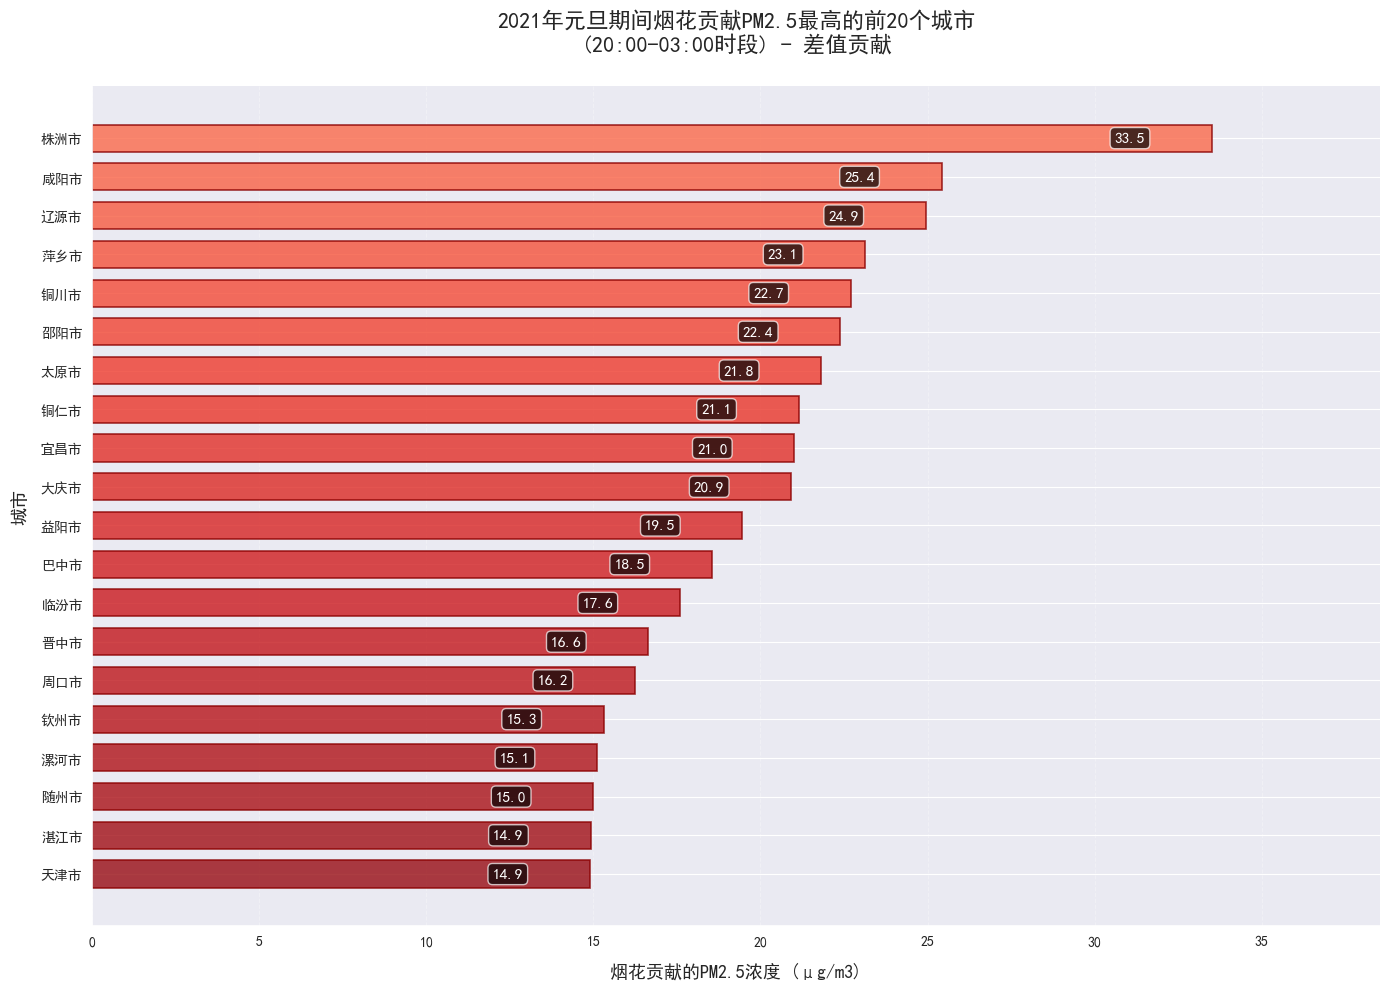

✅ 差值贡献条形图已保存: new_year_top_20_cities_diff.png 和 .pdf

📊 创建元旦前20城市相对贡献条形图...


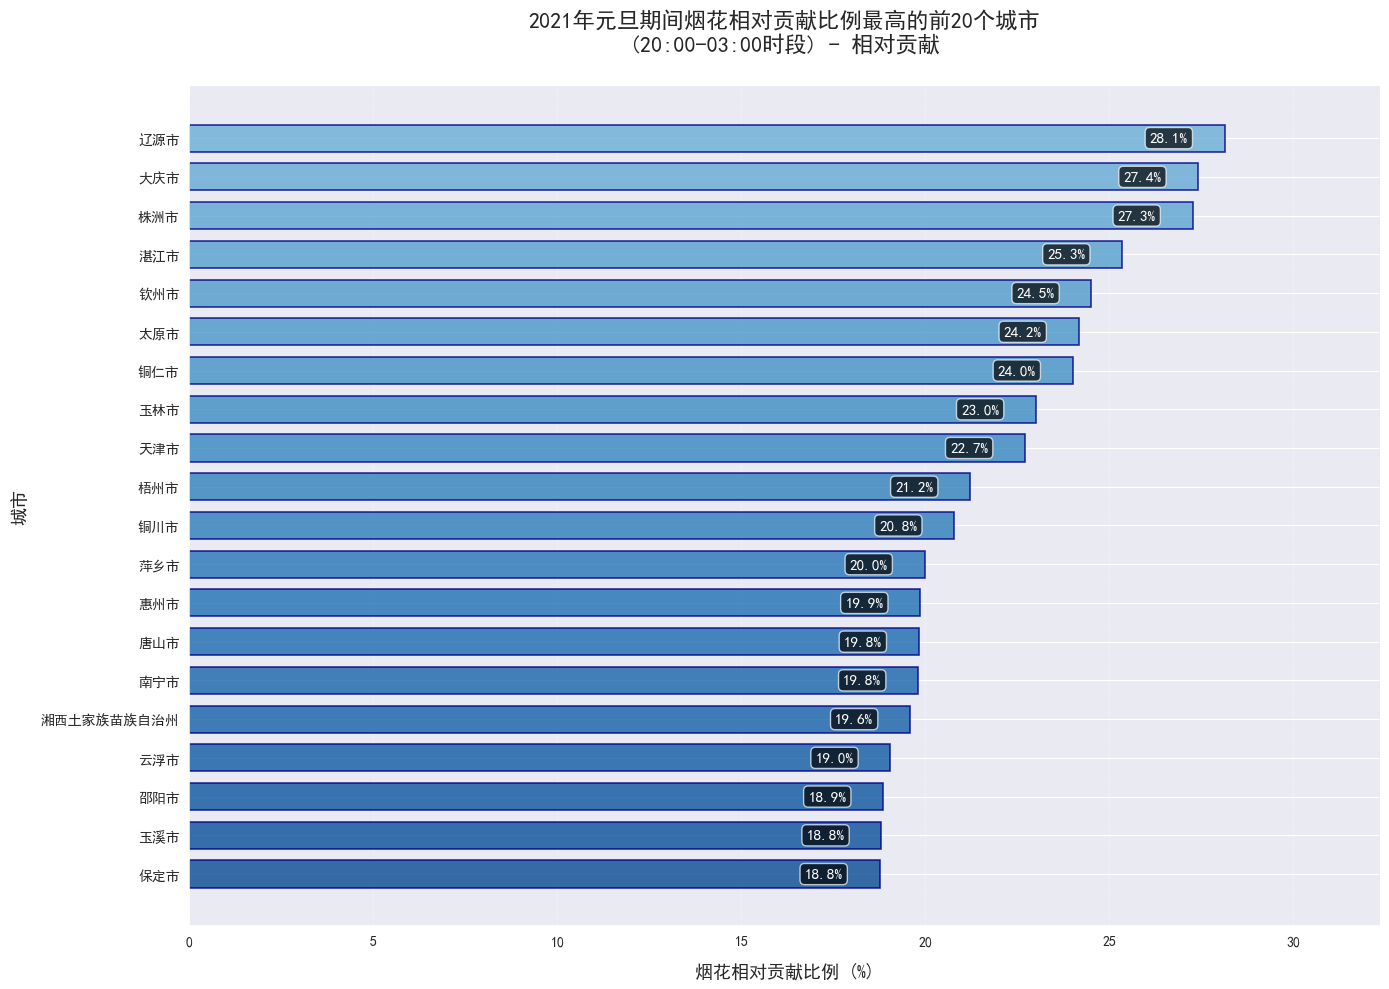

✅ 相对贡献条形图已保存: new_year_top_20_cities_ratio.png 和 .pdf

💾 保存详细分析结果...
✅ 元旦城市统计已保存: new_year_city_stats.csv
✅ 详细记录已保存: new_year_detailed_records.csv
✅ 前20城市分析数据已保存: new_year_top_20_cities_diff.csv 和 new_year_top_20_cities_ratio.csv

🎆 元旦期间PM2.5人为贡献分析完成!
📊 生成图表总结:
  - new_year_top_20_cities_diff.png: 差值贡献前20城市
  - new_year_top_20_cities_ratio.png: 相对贡献前20城市
  - 两个图表分别展示了绝对浓度贡献和相对比例贡献


In [ ]:
# 定义元旦时间段
start_time = '2021-12-31 20:00:00'
end_time = '2022-01-01 03:00:00'

print("分析元旦期间PM2.5人为贡献")
print("=" * 70)
print(f"时间段: {start_time} 到 {end_time}")
print("=" * 70)

# 筛选元旦时间段的数据
new_year_period = df_with_predictions[
    (df_with_predictions['time_datetime'] >= start_time) &
    (df_with_predictions['time_datetime'] <= end_time) &
    (df_with_predictions['has_prediction'] == True)
].copy()

print(f"元旦时间段总记录数: {len(new_year_period):,}")
print(f"涉及城市数量: {new_year_period['NAME'].nunique()}")

if len(new_year_period) == 0:
    print("❌ 元旦时间段内没有数据，请检查时间范围")
else:
    # 计算相对贡献比例
    new_year_period['human_contribution_ratio'] = (new_year_period['PM2.5_diff_actual_minus_pred'] /
                                                  np.clip(new_year_period['PM2.5'], 1, None)) * 100

    # 1. 按城市统计平均差值
    city_diff_stats = new_year_period.groupby('NAME').agg({
        'PM2.5_diff_actual_minus_pred': ['mean', 'max', 'min', 'count'],
        'human_contribution_ratio': ['mean', 'max', 'min'],
        'PM2.5': 'mean',
        'PM2.5_pred': 'mean'
    }).round(4)

    # 重命名列
    city_diff_stats.columns = ['diff_mean', 'diff_max', 'diff_min', 'record_count',
                              'ratio_mean', 'ratio_max', 'ratio_min', 'pm25_actual_mean', 'pm25_pred_mean']

    city_diff_stats = city_diff_stats.reset_index()

    # 2. 找出差值最高的城市（人为贡献最大）- 前20个
    print("\n🔝 元旦PM2.5差值最高的城市（人为贡献最大）- 前20:")
    print("-" * 70)

    top_diff_cities = city_diff_stats.nlargest(20, 'diff_mean')[['NAME', 'diff_mean', 'ratio_mean', 'pm25_actual_mean', 'pm25_pred_mean', 'record_count']]

    for i, (_, row) in enumerate(top_diff_cities.iterrows(), 1):
        print(f"{i:2d}. {row['NAME']:15} 平均差值: {row['diff_mean']:7.2f}, "
              f"相对贡献: {row['ratio_mean']:6.1f}%, "
              f"实际PM2.5: {row['pm25_actual_mean']:6.1f}, "
              f"预测PM2.5: {row['pm25_pred_mean']:6.1f}")

    # 3. 总体统计
    print(f"\n📋 元旦期间总体统计:")
    print("-" * 50)

    total_stats = {
        '总记录数': len(new_year_period),
        '涉及城市数': new_year_period['NAME'].nunique(),
        '平均差值': new_year_period['PM2.5_diff_actual_minus_pred'].mean(),
        '最大差值': new_year_period['PM2.5_diff_actual_minus_pred'].max(),
        '最小差值': new_year_period['PM2.5_diff_actual_minus_pred'].min(),
        '平均相对贡献': new_year_period['human_contribution_ratio'].mean(),
        '最大相对贡献': new_year_period['human_contribution_ratio'].max(),
        '平均实际PM2.5': new_year_period['PM2.5'].mean(),
        '平均预测PM2.5': new_year_period['PM2.5_pred'].mean()
    }

    for key, value in total_stats.items():
        if '贡献' in key or '比例' in key:
            print(f"  {key}: {value:.1f}%")
        elif 'PM2.5' in key or '差值' in key:
            print(f"  {key}: {value:.1f}")
        else:
            print(f"  {key}: {value}")

    # 4. 按小时分析变化趋势
    print(f"\n🕒 元旦期间按小时分析差值变化趋势:")
    print("-" * 50)

    new_year_period['hour'] = new_year_period['time_datetime'].dt.hour
    hours = sorted(new_year_period['hour'].unique())

    for hour in hours:
        hour_data = new_year_period[new_year_period['hour'] == hour]
        avg_diff = hour_data['PM2.5_diff_actual_minus_pred'].mean()
        avg_ratio = hour_data['human_contribution_ratio'].mean()
        avg_pm25 = hour_data['PM2.5'].mean()
        record_count = len(hour_data)

        print(f"  {hour:2d}:00 - 平均差值: {avg_diff:6.1f}, "
              f"相对贡献: {avg_ratio:5.1f}%, "
              f"实际PM2.5: {avg_pm25:5.1f}, "
              f"记录数: {record_count:3d}")

    # 5. 创建前20城市的差值贡献条形图（去掉百分数）
    print(f"\n📊 创建元旦前20城市差值贡献条形图...")

    # 获取前20个差值最高的城市数据
    top_20_diff = city_diff_stats.nlargest(20, 'diff_mean')[['NAME', 'diff_mean', 'ratio_mean']].copy()

    # 设置中文字体
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    # 创建差值贡献条形图
    fig, ax = plt.subplots(figsize=(14, 10))

    # 使用渐变色
    colors = plt.cm.Reds(np.linspace(0.5, 0.9, len(top_20_diff)))

    bars = ax.barh(top_20_diff['NAME'], top_20_diff['diff_mean'],
                   color=colors, alpha=0.8, edgecolor='darkred', linewidth=1.2,
                   height=0.7)

    # 添加数值标签 - 只显示差值数值
    for i, (bar, diff) in enumerate(zip(bars, top_20_diff['diff_mean'])):
        width = bar.get_width()
        # 在条形内部右侧显示数值
        ax.text(width - 2, bar.get_y() + bar.get_height()/2,
                f'{diff:.1f}',
                ha='right', va='center', fontsize=11, color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

    # 美化图表
    ax.set_xlabel('烟花贡献的PM2.5浓度 (μg/m3)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('城市', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title('2021年元旦期间烟花贡献PM2.5最高的前20个城市\n(20:00-03:00时段) - 差值贡献',
                 fontsize=16, fontweight='bold', pad=25)

    # 设置网格线
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # 设置x轴范围，留出一些空间给标签
    x_max = top_20_diff['diff_mean'].max()
    ax.set_xlim(0, x_max * 1.15)

    # 让最高的值在顶部
    ax.invert_yaxis()

    # 调整布局
    plt.tight_layout()

    # 保存高质量图表
    plt.savefig('new_year_top_20_cities_diff.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('new_year_top_20_cities_diff.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    print("✅ 差值贡献条形图已保存: new_year_top_20_cities_diff.png 和 .pdf")

    # 6. 创建相对贡献条形图
    print(f"\n📊 创建元旦前20城市相对贡献条形图...")

    # 获取前20个相对贡献最高的城市数据
    top_20_ratio = city_diff_stats.nlargest(20, 'ratio_mean')[['NAME', 'ratio_mean', 'diff_mean']].copy()

    # 创建相对贡献条形图
    fig, ax = plt.subplots(figsize=(14, 10))

    # 使用渐变色
    colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(top_20_ratio)))

    bars = ax.barh(top_20_ratio['NAME'], top_20_ratio['ratio_mean'],
                   color=colors, alpha=0.8, edgecolor='darkblue', linewidth=1.2,
                   height=0.7)

    # 添加数值标签 - 显示百分比
    for i, (bar, ratio) in enumerate(zip(bars, top_20_ratio['ratio_mean'])):
        width = bar.get_width()
        # 在条形内部右侧显示数值
        ax.text(width - 1, bar.get_y() + bar.get_height()/2,
                f'{ratio:.1f}%',
                ha='right', va='center', fontsize=11, color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

    # 美化图表
    ax.set_xlabel('烟花相对贡献比例 (%)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('城市', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title('2021年元旦期间烟花相对贡献比例最高的前20个城市\n(20:00-03:00时段) - 相对贡献',
                 fontsize=16, fontweight='bold', pad=25)

    # 设置网格线
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # 设置x轴范围，留出一些空间给标签
    x_max = top_20_ratio['ratio_mean'].max()
    ax.set_xlim(0, x_max * 1.15)

    # 让最高的值在顶部
    ax.invert_yaxis()

    # 调整布局
    plt.tight_layout()

    # 保存高质量图表
    plt.savefig('new_year_top_20_cities_ratio.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('new_year_top_20_cities_ratio.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    print("✅ 相对贡献条形图已保存: new_year_top_20_cities_ratio.png 和 .pdf")

    # 7. 保存详细分析结果
    print(f"\n💾 保存详细分析结果...")

    # 保存城市统计
    city_diff_stats.to_csv('new_year_city_stats.csv', index=False, encoding='utf-8-sig')
    print("✅ 元旦城市统计已保存: new_year_city_stats.csv")

    # 保存详细记录
    detailed_records = new_year_period[[
        'time_datetime', 'NAME', 'PM2.5', 'PM2.5_pred', 'PM2.5_diff_actual_minus_pred',
        'human_contribution_ratio', 'temp_c', 'rh', 'wind_speed'
    ]].copy()
    detailed_records.to_csv('new_year_detailed_records.csv', index=False, encoding='utf-8-sig')
    print("✅ 详细记录已保存: new_year_detailed_records.csv")

    # 保存前20城市数据
    top_20_diff.to_csv('new_year_top_20_cities_diff.csv', index=False, encoding='utf-8-sig')
    top_20_ratio.to_csv('new_year_top_20_cities_ratio.csv', index=False, encoding='utf-8-sig')
    print("✅ 前20城市分析数据已保存: new_year_top_20_cities_diff.csv 和 new_year_top_20_cities_ratio.csv")

    print(f"\n🎆 元旦期间PM2.5人为贡献分析完成!")
    print("=" * 70)
    print("📊 生成图表总结:")
    print("  - new_year_top_20_cities_diff.png: 差值贡献前20城市")
    print("  - new_year_top_20_cities_ratio.png: 相对贡献前20城市")
    print("  - 两个图表分别展示了绝对浓度贡献和相对比例贡献")

分析春节和元宵节期间PM2.5人为贡献
春节时间段: 2022-02-01 20:00:00 到 2022-02-02 03:00:00
元宵节时间段: 2022-02-15 20:00:00 到 2022-02-16 03:00:00
春节时间段总记录数: 2,072
春节涉及城市数量: 259
元宵节时间段总记录数: 2,072
元宵节涉及城市数量: 259

📊 两个时间段合并分析:
--------------------------------------------------
总记录数: 4,144
涉及城市数量: 259

🔝 春节+元宵节PM2.5差值最高的城市（人为贡献最大）- 前20:
----------------------------------------------------------------------
 1. 衡阳市             平均差值:   56.76, 相对贡献:   11.0%, 实际PM2.5:  141.7, 预测PM2.5:   84.9
 2. 通化市             平均差值:   46.40, 相对贡献:   20.4%, 实际PM2.5:  114.9, 预测PM2.5:   68.5
 3. 辽源市             平均差值:   43.88, 相对贡献:    4.3%, 实际PM2.5:  110.8, 预测PM2.5:   66.9
 4. 宝鸡市             平均差值:   39.26, 相对贡献:   12.8%, 实际PM2.5:  126.5, 预测PM2.5:   87.2
 5. 绥化市             平均差值:   35.95, 相对贡献:   23.1%, 实际PM2.5:  124.4, 预测PM2.5:   88.4
 6. 白山市             平均差值:   32.92, 相对贡献:   33.5%, 实际PM2.5:   85.5, 预测PM2.5:   52.6
 7. 齐齐哈尔市           平均差值:   32.47, 相对贡献:   11.4%, 实际PM2.5:   86.9, 预测PM2.5:   54.4
 8. 哈尔滨市            平均差值:   27.77, 相对贡献:

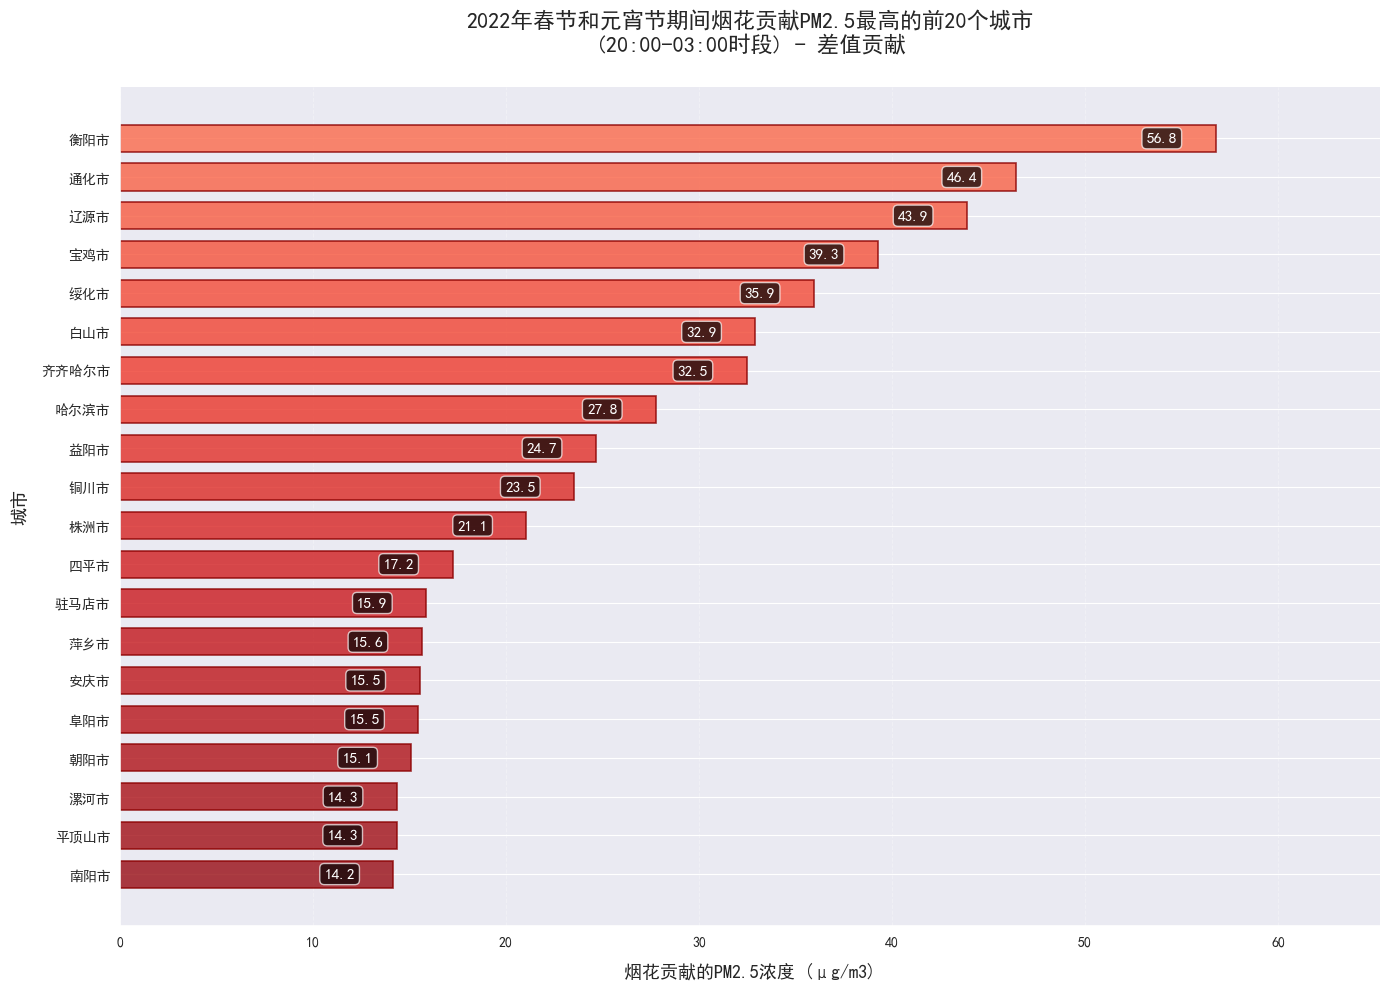

✅ 差值贡献条形图已保存: spring_lantern_festival_top_20_cities_diff.png 和 .pdf

📊 创建春节+元宵节前20城市相对贡献条形图...


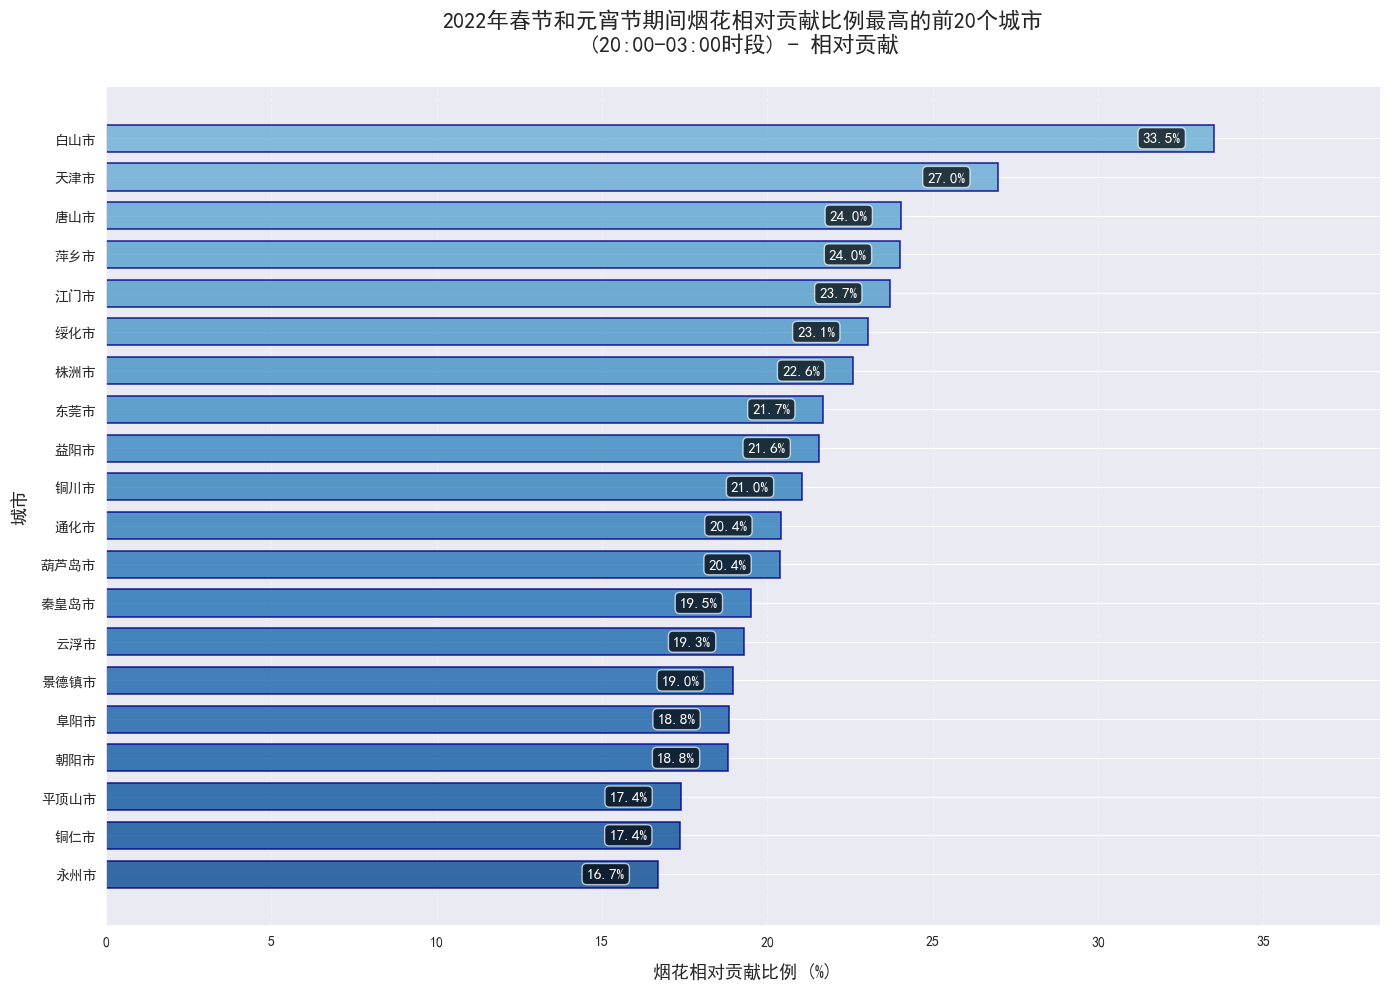

✅ 相对贡献条形图已保存: spring_lantern_festival_top_20_cities_ratio.png 和 .pdf

💾 保存详细分析结果...
✅ 春节+元宵节城市统计已保存: spring_lantern_festival_city_stats.csv
✅ 详细记录已保存: spring_lantern_festival_detailed_records.csv
✅ 前20城市分析数据已保存: spring_lantern_festival_top_20_cities_diff.csv 和 spring_lantern_festival_top_20_cities_ratio.csv

🎆 春节+元宵节期间PM2.5人为贡献分析完成!
📊 生成图表总结:
  - spring_lantern_festival_top_20_cities_diff.png: 差值贡献前20城市
  - spring_lantern_festival_top_20_cities_ratio.png: 相对贡献前20城市
  - 两个图表分别展示了绝对浓度贡献和相对比例贡献


In [ ]:
# 定义春节和元宵节的时间段
spring_festival_start = '2022-02-01 20:00:00'  # 春节晚上8点
spring_festival_end = '2022-02-02 03:00:00'    # 春节次日凌晨3点

lantern_festival_start = '2022-02-15 20:00:00' # 元宵节晚上8点
lantern_festival_end = '2022-02-16 03:00:00'

print("分析春节和元宵节期间PM2.5人为贡献")
print("=" * 70)
print(f"春节时间段: {spring_festival_start} 到 {spring_festival_end}")
print(f"元宵节时间段: {lantern_festival_start} 到 {lantern_festival_end}")
print("=" * 70)

# 筛选春节时间段的数据
spring_festival_period = df_with_predictions[
    (df_with_predictions['time_datetime'] >= spring_festival_start) &
    (df_with_predictions['time_datetime'] <= spring_festival_end) &
    (df_with_predictions['has_prediction'] == True)
].copy()

# 筛选元宵节时间段的数据
lantern_festival_period = df_with_predictions[
    (df_with_predictions['time_datetime'] >= lantern_festival_start) &
    (df_with_predictions['time_datetime'] <= lantern_festival_end) &
    (df_with_predictions['has_prediction'] == True)
].copy()

print(f"春节时间段总记录数: {len(spring_festival_period):,}")
print(f"春节涉及城市数量: {spring_festival_period['NAME'].nunique()}")
print(f"元宵节时间段总记录数: {len(lantern_festival_period):,}")
print(f"元宵节涉及城市数量: {lantern_festival_period['NAME'].nunique()}")

if len(spring_festival_period) == 0 or len(lantern_festival_period) == 0:
    print("❌ 某些时间段内没有数据，请检查时间范围")
else:
    # 计算相对贡献比例
    for period in [spring_festival_period, lantern_festival_period]:
        period['human_contribution_ratio'] = (period['PM2.5_diff_actual_minus_pred'] /
                                             np.clip(period['PM2.5'], 1, None)) * 100

    # 合并两个时间段的数据
    combined_period = pd.concat([spring_festival_period, lantern_festival_period], ignore_index=True)

    # 添加节日标识
    spring_festival_period['festival'] = 'Spring Festival'
    lantern_festival_period['festival'] = 'Lantern Festival'
    combined_period_with_festival = pd.concat([spring_festival_period, lantern_festival_period], ignore_index=True)

    print(f"\n📊 两个时间段合并分析:")
    print("-" * 50)
    print(f"总记录数: {len(combined_period):,}")
    print(f"涉及城市数量: {combined_period['NAME'].nunique()}")

    # 1. 按城市统计平均差值（合并数据）
    city_diff_stats_combined = combined_period.groupby('NAME').agg({
        'PM2.5_diff_actual_minus_pred': ['mean', 'max', 'min', 'count'],
        'human_contribution_ratio': ['mean', 'max', 'min'],
        'PM2.5': 'mean',
        'PM2.5_pred': 'mean'
    }).round(4)

    # 重命名列
    city_diff_stats_combined.columns = ['diff_mean', 'diff_max', 'diff_min', 'record_count',
                                       'ratio_mean', 'ratio_max', 'ratio_min', 'pm25_actual_mean', 'pm25_pred_mean']

    city_diff_stats_combined = city_diff_stats_combined.reset_index()

    # 2. 找出差值最高的城市（人为贡献最大）- 前20个
    print("\n🔝 春节+元宵节PM2.5差值最高的城市（人为贡献最大）- 前20:")
    print("-" * 70)

    top_diff_cities_combined = city_diff_stats_combined.nlargest(20, 'diff_mean')[['NAME', 'diff_mean', 'ratio_mean', 'pm25_actual_mean', 'pm25_pred_mean', 'record_count']]

    for i, (_, row) in enumerate(top_diff_cities_combined.iterrows(), 1):
        print(f"{i:2d}. {row['NAME']:15} 平均差值: {row['diff_mean']:7.2f}, "
              f"相对贡献: {row['ratio_mean']:6.1f}%, "
              f"实际PM2.5: {row['pm25_actual_mean']:6.1f}, "
              f"预测PM2.5: {row['pm25_pred_mean']:6.1f}")

    # 3. 分别分析春节和元宵节
    print(f"\n🎯 分节日统计:")
    print("-" * 50)

    festivals_stats = {}
    for festival_name, period_data in [('Spring Festival', spring_festival_period),
                                      ('Lantern Festival', lantern_festival_period)]:
        stats = {
            '记录数': len(period_data),
            '城市数': period_data['NAME'].nunique(),
            '平均差值': period_data['PM2.5_diff_actual_minus_pred'].mean(),
            '平均相对贡献': period_data['human_contribution_ratio'].mean(),
            '平均实际PM2.5': period_data['PM2.5'].mean(),
            '平均预测PM2.5': period_data['PM2.5_pred'].mean()
        }
        festivals_stats[festival_name] = stats

        print(f"\n{festival_name}:")
        for key, value in stats.items():
            if '贡献' in key:
                print(f"  {key}: {value:.1f}%")
            elif 'PM2.5' in key or '差值' in key:
                print(f"  {key}: {value:.1f}")
            else:
                print(f"  {key}: {value}")

    # 4. 合并数据总体统计
    print(f"\n📋 春节+元宵节合并总体统计:")
    print("-" * 50)

    total_stats_combined = {
        '总记录数': len(combined_period),
        '涉及城市数': combined_period['NAME'].nunique(),
        '平均差值': combined_period['PM2.5_diff_actual_minus_pred'].mean(),
        '最大差值': combined_period['PM2.5_diff_actual_minus_pred'].max(),
        '最小差值': combined_period['PM2.5_diff_actual_minus_pred'].min(),
        '平均相对贡献': combined_period['human_contribution_ratio'].mean(),
        '最大相对贡献': combined_period['human_contribution_ratio'].max(),
        '平均实际PM2.5': combined_period['PM2.5'].mean(),
        '平均预测PM2.5': combined_period['PM2.5_pred'].mean()
    }

    for key, value in total_stats_combined.items():
        if '贡献' in key or '比例' in key:
            print(f"  {key}: {value:.1f}%")
        elif 'PM2.5' in key or '差值' in key:
            print(f"  {key}: {value:.1f}")
        else:
            print(f"  {key}: {value}")

    # 5. 按小时分析变化趋势（合并数据）
    print(f"\n🕒 春节+元宵节按小时分析差值变化趋势:")
    print("-" * 50)

    combined_period['hour'] = combined_period['time_datetime'].dt.hour
    hours = sorted(combined_period['hour'].unique())

    for hour in hours:
        hour_data = combined_period[combined_period['hour'] == hour]
        avg_diff = hour_data['PM2.5_diff_actual_minus_pred'].mean()
        avg_ratio = hour_data['human_contribution_ratio'].mean()
        avg_pm25 = hour_data['PM2.5'].mean()
        record_count = len(hour_data)

        print(f"  {hour:2d}:00 - 平均差值: {avg_diff:6.1f}, "
              f"相对贡献: {avg_ratio:5.1f}%, "
              f"实际PM2.5: {avg_pm25:5.1f}, "
              f"记录数: {record_count:3d}")

    # 6. 创建前20城市的差值贡献条形图（去掉百分比）
    print(f"\n📊 创建春节+元宵节前20城市差值贡献条形图...")

    # 获取前20个差值最高的城市数据
    top_20_diff = city_diff_stats_combined.nlargest(20, 'diff_mean')[['NAME', 'diff_mean', 'ratio_mean']].copy()

    # 设置中文字体
    import matplotlib.pyplot as plt
    import numpy as np
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    # 创建差值贡献条形图
    fig, ax = plt.subplots(figsize=(14, 10))

    # 使用渐变色
    colors = plt.cm.Reds(np.linspace(0.5, 0.9, len(top_20_diff)))

    bars = ax.barh(top_20_diff['NAME'], top_20_diff['diff_mean'],
                   color=colors, alpha=0.8, edgecolor='darkred', linewidth=1.2,
                   height=0.7)

    # 添加数值标签 - 只显示差值数值
    for i, (bar, diff) in enumerate(zip(bars, top_20_diff['diff_mean'])):
        width = bar.get_width()
        # 在条形内部右侧显示数值
        ax.text(width - 2, bar.get_y() + bar.get_height()/2,
                f'{diff:.1f}',
                ha='right', va='center', fontsize=11, color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

    # 美化图表
    ax.set_xlabel('烟花贡献的PM2.5浓度 (μg/m3)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('城市', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title('2022年春节和元宵节期间烟花贡献PM2.5最高的前20个城市\n(20:00-03:00时段) - 差值贡献',
                 fontsize=16, fontweight='bold', pad=25)

    # 设置网格线
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # 设置x轴范围，留出一些空间给标签
    x_max = top_20_diff['diff_mean'].max()
    ax.set_xlim(0, x_max * 1.15)

    # 让最高的值在顶部
    ax.invert_yaxis()

    # 调整布局
    plt.tight_layout()

    # 保存高质量图表
    plt.savefig('spring_lantern_festival_top_20_cities_diff.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('spring_lantern_festival_top_20_cities_diff.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    print("✅ 差值贡献条形图已保存: spring_lantern_festival_top_20_cities_diff.png 和 .pdf")

    # 7. 创建相对贡献条形图
    print(f"\n📊 创建春节+元宵节前20城市相对贡献条形图...")

    # 获取前20个相对贡献最高的城市数据
    top_20_ratio = city_diff_stats_combined.nlargest(20, 'ratio_mean')[['NAME', 'ratio_mean', 'diff_mean']].copy()

    # 创建相对贡献条形图
    fig, ax = plt.subplots(figsize=(14, 10))

    # 使用渐变色
    colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(top_20_ratio)))

    bars = ax.barh(top_20_ratio['NAME'], top_20_ratio['ratio_mean'],
                   color=colors, alpha=0.8, edgecolor='darkblue', linewidth=1.2,
                   height=0.7)

    # 添加数值标签 - 显示百分比
    for i, (bar, ratio) in enumerate(zip(bars, top_20_ratio['ratio_mean'])):
        width = bar.get_width()
        # 在条形内部右侧显示数值
        ax.text(width - 1, bar.get_y() + bar.get_height()/2,
                f'{ratio:.1f}%',
                ha='right', va='center', fontsize=11, color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

    # 美化图表
    ax.set_xlabel('烟花相对贡献比例 (%)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('城市', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title('2022年春节和元宵节期间烟花相对贡献比例最高的前20个城市\n(20:00-03:00时段) - 相对贡献',
                 fontsize=16, fontweight='bold', pad=25)

    # 设置网格线
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # 设置x轴范围，留出一些空间给标签
    x_max = top_20_ratio['ratio_mean'].max()
    ax.set_xlim(0, x_max * 1.15)

    # 让最高的值在顶部
    ax.invert_yaxis()

    # 调整布局
    plt.tight_layout()

    # 保存高质量图表
    plt.savefig('spring_lantern_festival_top_20_cities_ratio.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('spring_lantern_festival_top_20_cities_ratio.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    print("✅ 相对贡献条形图已保存: spring_lantern_festival_top_20_cities_ratio.png 和 .pdf")

    # 8. 保存详细分析结果
    print(f"\n💾 保存详细分析结果...")

    # 保存合并城市统计
    city_diff_stats_combined.to_csv('spring_lantern_festival_city_stats.csv', index=False, encoding='utf-8-sig')
    print("✅ 春节+元宵节城市统计已保存: spring_lantern_festival_city_stats.csv")

    # 保存分节日数据
    combined_period_with_festival.to_csv('spring_lantern_festival_detailed_records.csv', index=False, encoding='utf-8-sig')
    print("✅ 详细记录已保存: spring_lantern_festival_detailed_records.csv")

    # 保存前20城市数据
    top_20_diff.to_csv('spring_lantern_festival_top_20_cities_diff.csv', index=False, encoding='utf-8-sig')
    top_20_ratio.to_csv('spring_lantern_festival_top_20_cities_ratio.csv', index=False, encoding='utf-8-sig')
    print("✅ 前20城市分析数据已保存: spring_lantern_festival_top_20_cities_diff.csv 和 spring_lantern_festival_top_20_cities_ratio.csv")

    print(f"\n🎆 春节+元宵节期间PM2.5人为贡献分析完成!")
    print("=" * 70)
    print("📊 生成图表总结:")
    print("  - spring_lantern_festival_top_20_cities_diff.png: 差值贡献前20城市")
    print("  - spring_lantern_festival_top_20_cities_ratio.png: 相对贡献前20城市")
    print("  - 两个图表分别展示了绝对浓度贡献和相对比例贡献")